<a href="https://colab.research.google.com/github/behraj/workshops/blob/main/AliH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive

drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import torch, subprocess

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(subprocess.run(["nvidia-smi"], capture_output=True, text=True).stdout)

CUDA available: True
GPU: NVIDIA L4
Sun May 31 05:55:20 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   54C    P8             17W /   72W |       3MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------

## Downloads

In [ ]:
import os

In [ ]:
# SegDINO repo
if not os.path.exists("/content/SegDINO"):
    !git clone https://github.com/script-Yang/SegDINO.git /content/SegDINO
else:
    print("SegDINO repo already exists, skipping clone")

SegDINO repo already exists, skipping clone


In [ ]:
# Clone DINOv3 repo
if not os.path.exists("/content/dinov3"):
    !git clone https://github.com/facebookresearch/dinov3.git /content/dinov3

DINOV3_LOCATION = "/content/dinov3"
print(f"DINOv3 location set to {DINOV3_LOCATION}")

# Ensure the weights directory exists
!mkdir -p /content/web_pth

# Re-download using your new URL
!wget -O /content/web_pth/dinov3_vits16_pretrain_lvd1689m-08c60483.pth \
  "https://dinov3.llamameta.net/dinov3_vits16/dinov3_vits16_pretrain_lvd1689m-08c60483.pth?Policy=eyJTdGF0ZW1lbnQiOlt7InVuaXF1ZV9oYXNoIjoiY2s5OHg2NnIxZ251cjRsN2F2cXlybnkxIiwiUmVzb3VyY2UiOiJodHRwczpcL1wvZGlub3YzLmxsYW1hbWV0YS5uZXRcLyoiLCJDb25kaXRpb24iOnsiRGF0ZUxlc3NUaGFuIjp7IkFXUzpFcG9jaFRpbWUiOjE3ODAzMjc3MTR9fX1dfQ__&Signature=jw-U5cG-rG-8IiIHIRbYR0-jUY6kuq4VLM9aIPOHo89qsV0s7uHG%7E6K06RwBPDSf5DkRes7NXEepYLyWmZBgWXh82S1alTMltHfjqaDaMDEjWilAEtApt9LWNmWDzwKMNBlHK5R1Yar0Nnd%7EIscZDdX2%7EnKqQ1pgSzvnyeConteVf7C42lGAlMT6w6nY%7EXIukEpSguawOhaB%7E5JVvckOyBC%7EPbViZCwqo8MM6YEmsKU8dbxa6eAA%7E13JVXXSTP8lfxpRScq4v7NHv3ofe0YgpL7l5dsW0rMdn6Atsq0SnCWVnfpc58-WzeBY99g3TPSeCnasd7g9LCT8GqqNSvSCiA__&Key-Pair-Id=K15QRJLYKIFSLZ&Download-Request-ID=4418986531671266"

# Verify the file size
print("\n--- New File Size Check ---")
!ls -lh /content/web_pth/dinov3_vits16_pretrain_lvd1689m-08c60483.pth


DINOv3 location set to /content/dinov3
--2026-05-31 05:55:20--  https://dinov3.llamameta.net/dinov3_vits16/dinov3_vits16_pretrain_lvd1689m-08c60483.pth?Policy=eyJTdGF0ZW1lbnQiOlt7InVuaXF1ZV9oYXNoIjoiY2s5OHg2NnIxZ251cjRsN2F2cXlybnkxIiwiUmVzb3VyY2UiOiJodHRwczpcL1wvZGlub3YzLmxsYW1hbWV0YS5uZXRcLyoiLCJDb25kaXRpb24iOnsiRGF0ZUxlc3NUaGFuIjp7IkFXUzpFcG9jaFRpbWUiOjE3ODAzMjc3MTR9fX1dfQ__&Signature=jw-U5cG-rG-8IiIHIRbYR0-jUY6kuq4VLM9aIPOHo89qsV0s7uHG%7E6K06RwBPDSf5DkRes7NXEepYLyWmZBgWXh82S1alTMltHfjqaDaMDEjWilAEtApt9LWNmWDzwKMNBlHK5R1Yar0Nnd%7EIscZDdX2%7EnKqQ1pgSzvnyeConteVf7C42lGAlMT6w6nY%7EXIukEpSguawOhaB%7E5JVvckOyBC%7EPbViZCwqo8MM6YEmsKU8dbxa6eAA%7E13JVXXSTP8lfxpRScq4v7NHv3ofe0YgpL7l5dsW0rMdn6Atsq0SnCWVnfpc58-WzeBY99g3TPSeCnasd7g9LCT8GqqNSvSCiA__&Key-Pair-Id=K15QRJLYKIFSLZ&Download-Request-ID=4418986531671266
Resolving dinov3.llamameta.net (dinov3.llamameta.net)... ^C

--- New File Size Check ---
-rw-r--r-- 1 root root 0 May 31 05:55 /content/web_pth/dinov3_vits16_pretrain_lvd1689m-08c60483.pt

In [ ]:
%%writefile /content/SegDINO/dataset.py

import os
import random
from pathlib import Path
from typing import List, Dict, Any, Optional

import numpy as np
import torch
from torch.utils.data import Dataset
from PIL import Image
import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode


class AspectRegionDataset(Dataset):
    """
    Dataset for ASPECTS region-wise semantic segmentation.

    Expected structure:
        root_dir/
            0012345/
                slices/
                    0012345_z012.png
                raw_masks/
                    0012345_z012.png
            00xxxx/
                ...

    Returns:
        image: (3, H, W) float tensor in [0,1]
        mask : (H, W) long tensor with values in {0..10}
        meta : dict with paths + id + case_id
    """
    def __init__(
        self,
        root_dir: Path,
        image_dir: str = "slices",
        mask_dir: str = "raw_masks",
        resize_dim=(256, 256),
        augment: bool = False,
        rotation_deg: float = 10.0,
        translate: float = 0.08,
        scale_range=(0.95, 1.05),
        hflip: bool = False,
        allowed_case_ids: Optional[set] = None,
    ):
        self.root_dir = Path(root_dir)
        self.image_paths: List[Path] = []
        self.mask_paths: List[Path] = []
        self.resize_dim = resize_dim

        self.augment = augment
        self.rotation_deg = rotation_deg
        self.translate = translate
        self.scale_range = scale_range
        self.hflip = hflip

        if not self.root_dir.exists():
            raise FileNotFoundError(f"Root dir not found: {self.root_dir}")

        for case_dir in sorted(os.listdir(self.root_dir)):
            case_path = self.root_dir / case_dir
            if not case_path.is_dir():
                continue

            case_id = case_path.name
            if allowed_case_ids is not None and case_id not in allowed_case_ids:
                continue

            image_folder = case_path / image_dir
            mask_folder = case_path / mask_dir

            if not image_folder.exists() or not mask_folder.exists():
                continue

            for img_fn in sorted(os.listdir(image_folder)):
                if not img_fn.lower().endswith(".png"):
                    continue

                img_path = image_folder / img_fn
                mask_path = mask_folder / img_fn

                if mask_path.exists():
                    self.image_paths.append(img_path)
                    self.mask_paths.append(mask_path)

        if len(self.image_paths) == 0:
            raise RuntimeError(f"No image-mask pairs found under {self.root_dir}")

        print(
            f"[AspectRegionDataset] Loaded {len(self.image_paths)} image-mask pairs "
            f"| augment={self.augment}"
        )

    def __len__(self) -> int:
        return len(self.image_paths)

    def _apply_transform(self, image, mask):
        w, h = image.size

        angle = random.uniform(-self.rotation_deg, self.rotation_deg)
        max_dx = self.translate * w
        max_dy = self.translate * h
        tx = int(round(random.uniform(-max_dx, max_dx)))
        ty = int(round(random.uniform(-max_dy, max_dy)))
        scale = random.uniform(*self.scale_range)
        do_flip = self.hflip and (random.random() < 0.5)

        image = TF.affine(
            image,
            angle=angle,
            translate=(tx, ty),
            scale=scale,
            shear=0.0,
            interpolation=InterpolationMode.BILINEAR,
            fill=0,
        )
        mask = TF.affine(
            mask,
            angle=angle,
            translate=(tx, ty),
            scale=scale,
            shear=0.0,
            interpolation=InterpolationMode.NEAREST,
            fill=0,
        )

        if do_flip:
            image = TF.hflip(image)
            mask = TF.hflip(mask)

        return image, mask

    def __getitem__(self, idx: int):
        img_path = self.image_paths[idx]
        mask_path = self.mask_paths[idx]

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        image = TF.resize(image, self.resize_dim, interpolation=InterpolationMode.BILINEAR)
        mask = TF.resize(mask, self.resize_dim, interpolation=InterpolationMode.NEAREST)

        if self.augment:
            image, mask = self._apply_transform(image, mask)

        image_tensor = TF.to_tensor(image)
        mask_np = np.array(mask, dtype=np.uint8)
        mask_tensor = torch.from_numpy(mask_np).long()

        case_id = img_path.parent.parent.name

        meta: Dict[str, Any] = {
            "img_path": str(img_path),
            "mask_path": str(mask_path),
            "id": img_path.stem,
            "case_id": case_id,
        }

        return image_tensor, mask_tensor, meta

Overwriting /content/SegDINO/dataset.py


In [ ]:
%%writefile /content/SegDINO/dataset.py
import os
import random
from pathlib import Path
from typing import List, Dict, Any, Optional

import numpy as np
import torch
from torch.utils.data import Dataset
from PIL import Image
import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode


class AspectRegionDataset(Dataset):
    """
    Dataset for ASPECTS region-wise semantic segmentation.

    Expected structure:
        root_dir/
            0012345/
                slices/
                    0012345_z012.png
                raw_masks/
                    0012345_z012.png
            00xxxx/
                ...

    Returns:
        image: (3, H, W) float tensor in [0,1]
        mask : (H, W) long tensor with values in {0..10}
        meta : dict with paths + id + case_id
    """
    def __init__(
        self,
        root_dir: Path,
        image_dir: str = "slices",
        mask_dir: str = "raw_masks",
        resize_dim=(256, 256),
        augment: bool = False,
        rotation_deg: float = 10.0,
        translate: float = 0.08,
        scale_range=(0.95, 1.05),
        hflip: bool = False,
        allowed_case_ids: Optional[set] = None,
    ):
        self.root_dir = Path(root_dir)
        self.image_paths: List[Path] = []
        self.mask_paths: List[Path] = []
        self.resize_dim = resize_dim

        self.augment = augment
        self.rotation_deg = rotation_deg
        self.translate = translate
        self.scale_range = scale_range
        self.hflip = hflip

        if not self.root_dir.exists():
            raise FileNotFoundError(f"Root dir not found: {self.root_dir}")

        for case_dir in sorted(os.listdir(self.root_dir)):
            case_path = self.root_dir / case_dir
            if not case_path.is_dir():
                continue

            case_id = case_path.name
            if allowed_case_ids is not None and case_id not in allowed_case_ids:
                continue

            image_folder = case_path / image_dir
            mask_folder = case_path / mask_dir

            if not image_folder.exists() or not mask_folder.exists():
                continue

            for img_fn in sorted(os.listdir(image_folder)):
                if not img_fn.lower().endswith(".png"):
                    continue

                img_path = image_folder / img_fn
                mask_path = mask_folder / img_fn

                if mask_path.exists():
                    self.image_paths.append(img_path)
                    self.mask_paths.append(mask_path)

        if len(self.image_paths) == 0:
            raise RuntimeError(f"No image-mask pairs found under {self.root_dir}")

        print(
            f"[AspectRegionDataset] Loaded {len(self.image_paths)} image-mask pairs "
            f"| augment={self.augment}"
        )

    def __len__(self) -> int:
        return len(self.image_paths)

    def _apply_transform(self, image, mask):
        w, h = image.size

        angle = random.uniform(-self.rotation_deg, self.rotation_deg)
        max_dx = self.translate * w
        max_dy = self.translate * h
        tx = int(round(random.uniform(-max_dx, max_dx)))
        ty = int(round(random.uniform(-max_dy, max_dy)))
        scale = random.uniform(*self.scale_range)
        do_flip = self.hflip and (random.random() < 0.5)

        image = TF.affine(
            image,
            angle=angle,
            translate=(tx, ty),
            scale=scale,
            shear=0.0,
            interpolation=InterpolationMode.BILINEAR,
            fill=0,
        )
        mask = TF.affine(
            mask,
            angle=angle,
            translate=(tx, ty),
            scale=scale,
            shear=0.0,
            interpolation=InterpolationMode.NEAREST,
            fill=0,
        )

        if do_flip:
            image = TF.hflip(image)
            mask = TF.hflip(mask)

        return image, mask

    def __getitem__(self, idx: int):
        img_path = self.image_paths[idx]
        mask_path = self.mask_paths[idx]

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        image = TF.resize(image, self.resize_dim, interpolation=InterpolationMode.BILINEAR)
        mask = TF.resize(mask, self.resize_dim, interpolation=InterpolationMode.NEAREST)

        if self.augment:
            image, mask = self._apply_transform(image, mask)

        image_tensor = TF.to_tensor(image)
        mask_np = np.array(mask, dtype=np.uint8)
        mask_tensor = torch.from_numpy(mask_np).long()

        case_id = img_path.parent.parent.name

        meta: Dict[str, Any] = {
            "img_path": str(img_path),
            "mask_path": str(mask_path),
            "id": img_path.stem,
            "case_id": case_id,
        }

        return image_tensor, mask_tensor, meta

Overwriting /content/SegDINO/dataset.py


In [ ]:
import os
import random
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

%cd /content/SegDINO

from dataset import AspectRegionDataset
from dpt import DPT

/content/SegDINO


In [ ]:
DATA_ROOT = Path("/content/drive/MyDrive/HibaAzeem/thesis_folder/__Aku_dataset_segdino_v2")


In [ ]:

# -------------------------
# CONFIG
# -------------------------
DATA_ROOT = Path("/content/drive/MyDrive/HibaAzeem/thesis_folder/__Aku_dataset_segdino_v2")
CKPT_PATH = "/content/SegDINO/runs/aku_aspects_segdino_s_256/ckpts/latest.pth"
DINO_CKPT = "/content/web_pth/dinov3_vits16_pretrain_lvd1689m-08c60483.pth"
REPO_DIR = "/content/dinov3"
NUM_CLASSES = 11
INPUT_SIZE = (256, 256)
SEED = 42

device = "cuda" if torch.cuda.is_available() else "cpu"

# -------------------------
# same split helpers
# -------------------------
def collect_case_ids(root_dir: Path):
    case_ids = []
    for case_dir in sorted(os.listdir(root_dir)):
        case_path = root_dir / case_dir
        if case_path.is_dir():
            case_ids.append(case_dir)
    return case_ids

def split_case_ids(case_ids, val_ratio=0.2, seed=42):
    case_ids = sorted(case_ids)
    rng = random.Random(seed)
    rng.shuffle(case_ids)

    n_total = len(case_ids)
    n_val = max(1, int(round(val_ratio * n_total)))
    val_case_ids = set(case_ids[:n_val])
    train_case_ids = set(case_ids[n_val:])
    return train_case_ids, val_case_ids

all_case_ids = collect_case_ids(DATA_ROOT)
train_case_ids, val_case_ids = split_case_ids(all_case_ids, val_ratio=0.2, seed=SEED)

train_dataset = AspectRegionDataset(
    root_dir=DATA_ROOT,
    resize_dim=INPUT_SIZE,
    augment=False,
    allowed_case_ids=train_case_ids,
)

val_dataset = AspectRegionDataset(
    root_dir=DATA_ROOT,
    resize_dim=INPUT_SIZE,
    augment=False,
    allowed_case_ids=val_case_ids,
)

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples:   {len(val_dataset)}")

[AspectRegionDataset] Loaded 164 image-mask pairs | augment=False
[AspectRegionDataset] Loaded 38 image-mask pairs | augment=False
Train samples: 164
Val samples:   38


In [ ]:
LABEL_COLORS = {
    0: (0, 0, 0),        # background
    1: (255, 0, 0),      # M1
    2: (0, 255, 0),      # M2
    3: (0, 0, 255),      # M3
    4: (255, 255, 0),    # M4
    5: (0, 255, 255),    # M5
    6: (255, 0, 255),    # M6
    7: (255, 165, 0),    # Caudate
    8: (128, 0, 255),    # Internal Capsule
    9: (0, 128, 255),    # Lentiform Nucleus
    10: (160, 160, 160), # Insular Cortex
}

REGION_NAME = {
    1: "M1",
    2: "M2",
    3: "M3",
    4: "M4",
    5: "M5",
    6: "M6",
    7: "CAUDATE",
    8: "INTERNAL CAPSULE",
    9: "LENTIFORM NUCLEUS",
    10: "INSULAR CORTEX",
}

def mask_to_rgb(mask):
    if torch.is_tensor(mask):
        mask = mask.detach().cpu().numpy()

    h, w = mask.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)

    for label_id, color in LABEL_COLORS.items():
        rgb[mask == label_id] = color

    return rgb

def overlay_mask_on_image(img_tensor, mask, alpha=0.35):
    img = img_tensor.detach().cpu().permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)

    if torch.is_tensor(mask):
        mask = mask.detach().cpu().numpy()

    rgb_mask = mask_to_rgb(mask).astype(np.float32) / 255.0
    mask_bin = (mask > 0).astype(np.float32)[..., None]

    overlay = img * (1 - alpha * mask_bin) + rgb_mask * (alpha * mask_bin)
    overlay = np.clip(overlay, 0, 1)
    return overlay

@torch.no_grad()
def predict_sample(model, image_tensor):
    x = image_tensor.unsqueeze(0).to(device)
    logits = model(x)
    pred = torch.argmax(torch.softmax(logits, dim=1), dim=1)[0].cpu()
    return pred

def dice_per_present_class(pred, gt, eps=1e-6):
    pred = pred.cpu()
    gt = gt.cpu()

    classes = sorted(set(torch.unique(gt).tolist()) | set(torch.unique(pred).tolist()))
    classes = [c for c in classes if c != 0]

    result = {}
    for c in classes:
        pred_c = (pred == c).float()
        gt_c = (gt == c).float()
        inter = (pred_c * gt_c).sum()
        denom = pred_c.sum() + gt_c.sum()
        dice = (2 * inter + eps) / (denom + eps)
        result[c] = float(dice)

    return result

In [ ]:
def show_dataset_samples(dataset, model, n=20, split_name="train", seed=123):
    rng = random.Random(seed)
    indices = list(range(len(dataset)))
    chosen = rng.sample(indices, min(n, len(indices)))

    for idx in chosen:
        image, gt_mask, meta = dataset[idx]
        pred_mask = predict_sample(model, image)

        gt_labels = [int(x) for x in torch.unique(gt_mask).tolist() if x != 0]
        pred_labels = [int(x) for x in torch.unique(pred_mask).tolist() if x != 0]
        class_dices = dice_per_present_class(pred_mask, gt_mask)

        print("=" * 100)
        print(f"{split_name.upper()} SAMPLE IDX: {idx}")
        print(f"Case ID : {meta['case_id']}")
        print(f"Slice ID: {meta['id']}")
        print(f"GT labels   : {[REGION_NAME.get(x, x) for x in gt_labels]}")
        print(f"Pred labels : {[REGION_NAME.get(x, x) for x in pred_labels]}")
        print("Class Dice  :", {REGION_NAME.get(k, k): round(v, 4) for k, v in class_dices.items()})

        fig, axes = plt.subplots(1, 5, figsize=(24, 5))

        axes[0].imshow(image.permute(1, 2, 0).cpu())
        axes[0].set_title("Image")

        axes[1].imshow(mask_to_rgb(gt_mask))
        axes[1].set_title("Ground Truth")

        axes[2].imshow(mask_to_rgb(pred_mask))
        axes[2].set_title("Prediction")

        axes[3].imshow(overlay_mask_on_image(image, gt_mask))
        axes[3].set_title("GT Overlay")

        axes[4].imshow(overlay_mask_on_image(image, pred_mask))
        axes[4].set_title("Pred Overlay")

        for ax in axes:
            ax.axis("off")

        plt.suptitle(f"{split_name.upper()} | Case {meta['case_id']} | {meta['id']}", fontsize=14)
        plt.tight_layout()
        plt.show()

In [ ]:
def inspect_mask_area(dataset, class_id=10, top_k=10):
    areas = []
    for i in range(len(dataset)):
        _, mask, meta = dataset[i]
        area = int((mask == class_id).sum().item())
        if area > 0:
            areas.append((i, meta["case_id"], meta["id"], area))
    areas = sorted(areas, key=lambda x: x[3])
    print("Smallest positive areas:")
    for row in areas[:top_k]:
        print(row)
    print("Largest positive areas:")
    for row in areas[-top_k:]:
        print(row)

In [ ]:
def inspect_mask_area(dataset, class_id=10, top_k=10):
    areas = []
    for i in range(len(dataset)):
        _, mask, meta = dataset[i]
        area = int((mask == class_id).sum().item())
        if area > 0:
            areas.append((i, meta["case_id"], meta["id"], area))
    areas = sorted(areas, key=lambda x: x[3])
    print("Smallest positive areas:")
    for row in areas[:top_k]:
        print(row)
    print("Largest positive areas:")
    for row in areas[-top_k:]:
        print(row)

In [ ]:
inspect_mask_area(val_dataset, class_id=10, top_k=10)

Smallest positive areas:
(10, '1957410', '1957410_z020', 122)
(16, '3548118', '3548118_z015', 122)
(14, '2532168', '2532168_z016', 125)
(18, '3576943', '3576943_z019', 143)
(23, '3615559', '3615559_z016', 145)
(36, '8504825', '8504825_z015', 167)
(5, '1142276', '1142276_z016', 169)
(9, '1949570', '1949570_z015', 169)
(35, '3634113', '3634113_z013', 188)
(28, '3623061', '3623061_z019', 222)
Largest positive areas:
(18, '3576943', '3576943_z019', 143)
(23, '3615559', '3615559_z016', 145)
(36, '8504825', '8504825_z015', 167)
(5, '1142276', '1142276_z016', 169)
(9, '1949570', '1949570_z015', 169)
(35, '3634113', '3634113_z013', 188)
(28, '3623061', '3623061_z019', 222)
(22, '3609237', '3609237_z014', 269)
(0, '0099550', '0099550_z015', 280)
(3, '0975940', '0975940_z015', 360)


In [ ]:
def inspect_mask_area_stats(dataset, class_id=10):
    areas = []

    for i in range(len(dataset)):
        _, mask, meta = dataset[i]
        area = int((mask == class_id).sum().item())
        if area > 0:
            areas.append(area)

    if len(areas) == 0:
        print("No samples found for this class.")
        return

    areas = np.array(areas)

    print("========== MASK AREA STATS ==========")
    print(f"Class ID: {class_id}")
    print(f"Num samples with this class: {len(areas)}")
    print(f"Min area: {areas.min()}")
    print(f"Max area: {areas.max()}")
    print(f"Mean area: {areas.mean():.2f}")
    print(f"Median area: {np.median(areas):.2f}")

    print("\nPercentiles:")
    for p in [1, 5, 10, 25, 50, 75, 90, 95, 99]:
        print(f"{p}%: {np.percentile(areas, p):.2f}")

    print("\nSmall area counts:")
    print(f"< 50 px  : {(areas < 50).sum()}")
    print(f"< 100 px : {(areas < 100).sum()}")
    print(f"< 200 px : {(areas < 200).sum()}")
    print(f"< 500 px : {(areas < 500).sum()}")

In [ ]:
inspect_mask_area_stats(train_dataset, class_id=10)


KeyboardInterrupt: 

In [ ]:
def inspect_all_classes_area_stats(dataset, num_classes=11):
    import numpy as np

    print("="*80)
    print("CLASS-WISE MASK AREA STATS")
    print("="*80)

    for class_id in range(1, num_classes):  # skip background
        areas = []

        for i in range(len(dataset)):
            _, mask, _ = dataset[i]
            area = int((mask == class_id).sum().item())
            if area > 0:
                areas.append(area)

        print("\n" + "-"*60)
        print(f"Class {class_id}")
        print("-"*60)

        if len(areas) == 0:
            print("No samples found for this class.")
            continue

        areas = np.array(areas)

        print(f"Num samples: {len(areas)}")
        print(f"Min area: {areas.min()}")
        print(f"Max area: {areas.max()}")
        print(f"Mean area: {areas.mean():.2f}")
        print(f"Median area: {np.median(areas):.2f}")

        print("Percentiles:")
        for p in [5, 10, 25, 50, 75, 90, 95]:
            print(f"  {p}%: {np.percentile(areas, p):.2f}")

        print("Small area counts:")
        print(f"  <50 px   : {(areas < 50).sum()}")
        print(f"  <100 px  : {(areas < 100).sum()}")
        print(f"  <200 px  : {(areas < 200).sum()}")
        print(f"  <500 px  : {(areas < 500).sum()}")

In [ ]:
from torch.utils.data import WeightedRandomSampler

def build_sampler(dataset, num_classes=11):
    weights = []

    for i in range(len(dataset)):
        _, mask, _ = dataset[i]
        labels = set(mask.unique().tolist())

        # boost samples with rare classes
        if 7 in labels:
            weights.append(5.0)
        elif 8 in labels:
            weights.append(3.0)
        elif 10 in labels:
            weights.append(2.0)
        else:
            weights.append(1.0)

    return WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

In [ ]:
from torch.utils.data import DataLoader

sampler = build_sampler(train_dataset)

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    sampler=sampler,
    num_workers=2
)

In [ ]:
from collections import Counter
import torch

def inspect_loader_class_presence(loader, num_batches=20):
    counts = Counter()

    for b, (_, masks, _) in enumerate(loader):
        if b >= num_batches:
            break

        for i in range(masks.size(0)):
            labels = set(torch.unique(masks[i]).tolist())
            for c in labels:
                if c != 0:
                    counts[c] += 1

    print(f"Class presence over first {num_batches} batches:")
    for c in range(1, 11):
        print(f"Class {c}: {counts[c]}")

In [ ]:
inspect_loader_class_presence(train_loader, num_batches=20)

## Frozen

In [ ]:
%%writefile /content/SegDINO/train_segdino_multilayer_sampler.py

import os
import math
import json
import copy
import random
import argparse
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Set, Tuple

import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode

from tqdm import tqdm
from sklearn.model_selection import KFold


# ============================================================
# LABEL DEFINITIONS
# ============================================================

# Global mask labels:
# 0  background
# 1  M1
# 2  M2
# 3  M3
# 4  M4
# 5  M5
# 6  M6
# 7  Caudate
# 8  Internal Capsule
# 9  Lentiform Nucleus
# 10 Insular Cortex

BG_GLOBAL_IDS = [1, 2, 3, 7, 8, 9, 10]
SG_GLOBAL_IDS = [4, 5, 6]

BG_NUM_CLASSES = 8   # background + M1, M2, M3, Caudate, IC, Lentiform, Insula
SG_NUM_CLASSES = 4   # background + M4, M5, M6

BG_GLOBAL_TO_LOCAL = {
    1: 1,    # M1
    2: 2,    # M2
    3: 3,    # M3
    7: 4,    # Caudate
    8: 5,    # Internal Capsule
    9: 6,    # Lentiform Nucleus
    10: 7,   # Insular Cortex
}

SG_GLOBAL_TO_LOCAL = {
    4: 1,    # M4
    5: 2,    # M5
    6: 3,    # M6
}

# TAGL local correspondence:
# BG local M1 -> SG local M4
# BG local M2 -> SG local M5
# BG local M3 -> SG local M6
TAGL_PAIRS_LOCAL = [
    (1, 1),
    (2, 2),
    (3, 3),
]

IMAGE_MEAN = [0.485, 0.456, 0.406]
IMAGE_STD = [0.229, 0.224, 0.225]


def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def remap_global_to_local(mask: torch.Tensor, mapping: Dict[int, int]) -> torch.Tensor:
    """
    Converts global ASPECTS labels into BG-specific or SG-specific local labels.

    Any class not present in the selected mapping becomes background.
    """
    local = torch.zeros_like(mask).long()

    for global_id, local_id in mapping.items():
        local[mask == global_id] = local_id

    return local


# ============================================================
# DATA INDEXING
# ============================================================

def detect_slice_level(mask_path: Path, filename: str) -> str:
    """
    Detects whether a slice belongs to BG, SG, BOTH, or UNKNOWN.

    Detection priority:
    1. Filename keywords.
    2. Mask labels.
    """
    name = filename.lower()

    bg_keywords = ["bg", "bgl", "basal", "ganglia"]
    sg_keywords = ["sg", "cr", "crl", "supra", "corona"]

    if any(k in name for k in bg_keywords):
        return "BG"

    if any(k in name for k in sg_keywords):
        return "SG"

    mask = np.array(Image.open(mask_path).convert("L"), dtype=np.uint8)
    labels = set(np.unique(mask).tolist())

    has_bg = len(labels.intersection(set(BG_GLOBAL_IDS))) > 0
    has_sg = len(labels.intersection(set(SG_GLOBAL_IDS))) > 0

    if has_bg and not has_sg:
        return "BG"

    if has_sg and not has_bg:
        return "SG"

    if has_bg and has_sg:
        return "BOTH"

    return "UNKNOWN"


def build_aspects_index(
    root_dir,
    image_dir: str = "slices",
    mask_dir: str = "raw_masks",
    allowed_case_ids: Optional[Set[str]] = None,
):
    """
    Expected structure:

        root_dir/
            case_id/
                slices/
                    slice_name.png
                raw_masks/
                    slice_name.png

    Returns:
        bg_samples
        sg_samples
        paired_samples
    """
    root_dir = Path(root_dir)

    if not root_dir.exists():
        raise FileNotFoundError(f"data_root not found: {root_dir}")

    bg_samples = []
    sg_samples = []
    paired_samples = []

    missing_folder_cases = []
    unknown_single_cases = []
    fallback_cases = []

    case_dirs = sorted([d for d in os.listdir(root_dir) if (root_dir / d).is_dir()])

    for case_id in case_dirs:
        if allowed_case_ids is not None and case_id not in allowed_case_ids:
            continue

        case_path = root_dir / case_id
        img_folder = case_path / image_dir
        mask_folder = case_path / mask_dir

        if not img_folder.exists() or not mask_folder.exists():
            missing_folder_cases.append(case_id)
            continue

        all_items = []
        bg_items = []
        sg_items = []

        for img_fn in sorted(os.listdir(img_folder)):
            if not img_fn.lower().endswith(".png"):
                continue

            img_path = img_folder / img_fn
            mask_path = mask_folder / img_fn

            if not mask_path.exists():
                continue

            level = detect_slice_level(mask_path, img_fn)

            item = {
                "case_id": case_id,
                "slice_id": Path(img_fn).stem,
                "image_path": img_path,
                "mask_path": mask_path,
                "level": level,
            }

            all_items.append(item)

            if level == "BG":
                bg_items.append(item)

            elif level == "SG":
                sg_items.append(item)

            elif level == "BOTH":
                bg_items.append(item)
                sg_items.append(item)

        # Fallback: if a case has 2+ slices but one level is missing,
        # assign first slice to BG and second slice to SG.
        if len(all_items) >= 2 and (len(bg_items) == 0 or len(sg_items) == 0):
            sorted_items = sorted(all_items, key=lambda x: str(x["slice_id"]))

            if len(bg_items) == 0:
                bg_items.append(sorted_items[0])
                fallback_cases.append(case_id)

            if len(sg_items) == 0:
                candidate = sorted_items[1]

                if candidate["image_path"] == bg_items[0]["image_path"] and len(sorted_items) > 2:
                    candidate = sorted_items[2]

                sg_items.append(candidate)
                fallback_cases.append(case_id)

        if len(all_items) == 1 and len(bg_items) == 0 and len(sg_items) == 0:
            unknown_single_cases.append(case_id)

        for item in bg_items:
            bg_samples.append(item)

        for item in sg_items:
            sg_samples.append(item)

        # Pair BG and SG slices from the same case for TAGL.
        n_pairs = min(len(bg_items), len(sg_items))

        for i in range(n_pairs):
            bg_item = bg_items[i]
            sg_item = sg_items[i]

            if bg_item["image_path"] == sg_item["image_path"]:
                continue

            paired_samples.append({
                "case_id": case_id,
                "bg": bg_item,
                "sg": sg_item,
            })

    print("=" * 80)
    print("DATA INDEX SUMMARY")
    print("=" * 80)
    print(f"BG slice samples      : {len(bg_samples)}")
    print(f"SG slice samples      : {len(sg_samples)}")
    print(f"Paired BG-SG samples  : {len(paired_samples)}")
    print(f"Missing folder cases  : {len(missing_folder_cases)}")
    print(f"Unknown single cases  : {len(unknown_single_cases)}")
    print(f"Fallback cases        : {len(set(fallback_cases))}")

    if fallback_cases:
        print("First fallback cases:", list(dict.fromkeys(fallback_cases))[:10])

    print("=" * 80)

    return bg_samples, sg_samples, paired_samples


# ============================================================
# DATASETS
# ============================================================

class AspectSliceDataset(Dataset):
    """
    Dataset for either BG or SG slices.
    """

    def __init__(
        self,
        samples,
        level: str,
        resize_dim: Tuple[int, int] = (256, 256),
        augment: bool = False,
        rotation_deg: float = 10.0,
        translate: float = 0.08,
        scale_range: Tuple[float, float] = (0.95, 1.05),
        hflip: bool = False,
    ):
        self.samples = list(samples)
        self.level = level
        self.resize_dim = resize_dim
        self.augment = augment
        self.rotation_deg = rotation_deg
        self.translate = translate
        self.scale_range = scale_range
        self.hflip = hflip

        if level == "BG":
            self.mapping = BG_GLOBAL_TO_LOCAL
            self.num_classes = BG_NUM_CLASSES

        elif level == "SG":
            self.mapping = SG_GLOBAL_TO_LOCAL
            self.num_classes = SG_NUM_CLASSES

        else:
            raise ValueError("level must be 'BG' or 'SG'")

        print(f"[AspectSliceDataset-{level}] {len(self.samples)} samples | augment={augment}")

    def __len__(self):
        return len(self.samples)

    def _load_image_mask(self, image_path, mask_path):
        image = Image.open(image_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        image = TF.resize(
            image,
            self.resize_dim,
            interpolation=InterpolationMode.BILINEAR,
        )

        mask = TF.resize(
            mask,
            self.resize_dim,
            interpolation=InterpolationMode.NEAREST,
        )

        return image, mask

    def _sample_params(self, image):
        w, h = image.size

        angle = random.uniform(-self.rotation_deg, self.rotation_deg)

        max_dx = self.translate * w
        max_dy = self.translate * h

        tx = int(round(random.uniform(-max_dx, max_dx)))
        ty = int(round(random.uniform(-max_dy, max_dy)))

        scale = random.uniform(*self.scale_range)
        do_flip = self.hflip and random.random() < 0.5

        return angle, (tx, ty), scale, do_flip

    def _apply_affine(self, image, mask, params):
        angle, translate, scale, do_flip = params

        image = TF.affine(
            image,
            angle=angle,
            translate=translate,
            scale=scale,
            shear=0.0,
            interpolation=InterpolationMode.BILINEAR,
            fill=0,
        )

        mask = TF.affine(
            mask,
            angle=angle,
            translate=translate,
            scale=scale,
            shear=0.0,
            interpolation=InterpolationMode.NEAREST,
            fill=0,
        )

        if do_flip:
            image = TF.hflip(image)
            mask = TF.hflip(mask)

        return image, mask

    def __getitem__(self, idx):
        item = self.samples[idx]

        image, mask = self._load_image_mask(
            item["image_path"],
            item["mask_path"],
        )

        if self.augment:
            params = self._sample_params(image)
            image, mask = self._apply_affine(image, mask, params)

        image_t = TF.to_tensor(image)
        image_t = TF.normalize(image_t, mean=IMAGE_MEAN, std=IMAGE_STD)

        global_mask = torch.from_numpy(np.array(mask, dtype=np.uint8)).long()
        local_mask = remap_global_to_local(global_mask, self.mapping)

        meta = {
            "case_id": item["case_id"],
            "slice_id": item["slice_id"],
            "level": self.level,
            "image_path": str(item["image_path"]),
            "mask_path": str(item["mask_path"]),
        }

        return image_t, local_mask, meta


class PairedAspectDataset(Dataset):
    """
    Dataset returning paired BG and SG samples for TAGL.
    """

    def __init__(
        self,
        pairs,
        resize_dim: Tuple[int, int] = (256, 256),
        augment: bool = False,
        rotation_deg: float = 10.0,
        translate: float = 0.08,
        scale_range: Tuple[float, float] = (0.95, 1.05),
        hflip: bool = False,
    ):
        self.pairs = list(pairs)
        self.resize_dim = resize_dim
        self.augment = augment
        self.rotation_deg = rotation_deg
        self.translate = translate
        self.scale_range = scale_range
        self.hflip = hflip

        print(f"[PairedAspectDataset] {len(self.pairs)} pairs | augment={augment}")

    def __len__(self):
        return len(self.pairs)

    def _load_image_mask(self, image_path, mask_path):
        image = Image.open(image_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        image = TF.resize(
            image,
            self.resize_dim,
            interpolation=InterpolationMode.BILINEAR,
        )

        mask = TF.resize(
            mask,
            self.resize_dim,
            interpolation=InterpolationMode.NEAREST,
        )

        return image, mask

    def _sample_params(self, image):
        w, h = image.size

        angle = random.uniform(-self.rotation_deg, self.rotation_deg)

        max_dx = self.translate * w
        max_dy = self.translate * h

        tx = int(round(random.uniform(-max_dx, max_dx)))
        ty = int(round(random.uniform(-max_dy, max_dy)))

        scale = random.uniform(*self.scale_range)
        do_flip = self.hflip and random.random() < 0.5

        return angle, (tx, ty), scale, do_flip

    def _apply_affine(self, image, mask, params):
        angle, translate, scale, do_flip = params

        image = TF.affine(
            image,
            angle=angle,
            translate=translate,
            scale=scale,
            shear=0.0,
            interpolation=InterpolationMode.BILINEAR,
            fill=0,
        )

        mask = TF.affine(
            mask,
            angle=angle,
            translate=translate,
            scale=scale,
            shear=0.0,
            interpolation=InterpolationMode.NEAREST,
            fill=0,
        )

        if do_flip:
            image = TF.hflip(image)
            mask = TF.hflip(mask)

        return image, mask

    def __getitem__(self, idx):
        pair = self.pairs[idx]

        bg_img, bg_mask = self._load_image_mask(
            pair["bg"]["image_path"],
            pair["bg"]["mask_path"],
        )

        sg_img, sg_mask = self._load_image_mask(
            pair["sg"]["image_path"],
            pair["sg"]["mask_path"],
        )

        if self.augment:
            # Same transform for BG and SG pair so TAGL compares aligned grids.
            params = self._sample_params(bg_img)
            bg_img, bg_mask = self._apply_affine(bg_img, bg_mask, params)
            sg_img, sg_mask = self._apply_affine(sg_img, sg_mask, params)

        bg_img_t = TF.to_tensor(bg_img)
        sg_img_t = TF.to_tensor(sg_img)

        bg_img_t = TF.normalize(bg_img_t, mean=IMAGE_MEAN, std=IMAGE_STD)
        sg_img_t = TF.normalize(sg_img_t, mean=IMAGE_MEAN, std=IMAGE_STD)

        bg_global = torch.from_numpy(np.array(bg_mask, dtype=np.uint8)).long()
        sg_global = torch.from_numpy(np.array(sg_mask, dtype=np.uint8)).long()

        bg_local = remap_global_to_local(bg_global, BG_GLOBAL_TO_LOCAL)
        sg_local = remap_global_to_local(sg_global, SG_GLOBAL_TO_LOCAL)

        meta = {
            "case_id": pair["case_id"],
            "bg_slice_id": pair["bg"]["slice_id"],
            "sg_slice_id": pair["sg"]["slice_id"],
            "bg_path": str(pair["bg"]["image_path"]),
            "sg_path": str(pair["sg"]["image_path"]),
        }

        return bg_img_t, bg_local, sg_img_t, sg_local, meta


# ============================================================
# CLASS WEIGHTS AND SAMPLERS
# ============================================================

def compute_class_weights_from_samples(samples, mapping, num_classes):
    counts = torch.zeros(num_classes, dtype=torch.float64)

    for item in samples:
        mask = Image.open(item["mask_path"]).convert("L")
        global_mask = torch.from_numpy(np.array(mask, dtype=np.uint8)).long()
        local_mask = remap_global_to_local(global_mask, mapping)

        values, value_counts = torch.unique(local_mask, return_counts=True)

        for value, count in zip(values.tolist(), value_counts.tolist()):
            if 0 <= value < num_classes:
                counts[value] += count

    counts = counts.clamp_min(1.0)

    weights = counts.sum() / counts
    weights = weights / weights.mean()

    # Down-weight background.
    weights[0] = 0.05

    return weights.float()


def build_slice_sampler(samples, mapping, level):
    weights = []

    for item in samples:
        mask = Image.open(item["mask_path"]).convert("L")
        global_mask = torch.from_numpy(np.array(mask, dtype=np.uint8)).long()
        local_mask = remap_global_to_local(global_mask, mapping)

        labels = set(torch.unique(local_mask).tolist())

        weight = 1.0

        if level == "BG":
            # Rare BG structures in local IDs:
            # 4 Caudate, 5 Internal Capsule, 6 Lentiform, 7 Insula
            if 4 in labels:
                weight += 4.0
            if 5 in labels:
                weight += 2.0
            if 6 in labels:
                weight += 1.5
            if 7 in labels:
                weight += 1.5

        elif level == "SG":
            if len(labels.intersection({1, 2, 3})) > 0:
                weight += 2.0

        else:
            raise ValueError("level must be 'BG' or 'SG'")

        weights.append(weight)

    return WeightedRandomSampler(
        weights=torch.DoubleTensor(weights),
        num_samples=len(weights),
        replacement=True,
    )


def build_paired_sampler(pairs):
    weights = []

    for pair in pairs:
        bg_mask = Image.open(pair["bg"]["mask_path"]).convert("L")
        sg_mask = Image.open(pair["sg"]["mask_path"]).convert("L")

        bg_global = torch.from_numpy(np.array(bg_mask, dtype=np.uint8)).long()
        sg_global = torch.from_numpy(np.array(sg_mask, dtype=np.uint8)).long()

        bg_local = remap_global_to_local(bg_global, BG_GLOBAL_TO_LOCAL)
        sg_local = remap_global_to_local(sg_global, SG_GLOBAL_TO_LOCAL)

        bg_labels = set(torch.unique(bg_local).tolist())
        sg_labels = set(torch.unique(sg_local).tolist())

        weight = 1.0

        if 4 in bg_labels:
            weight += 4.0
        if 5 in bg_labels:
            weight += 2.0
        if 6 in bg_labels:
            weight += 1.5
        if 7 in bg_labels:
            weight += 1.5

        if len(sg_labels.intersection({1, 2, 3})) > 0:
            weight += 1.0

        weights.append(weight)

    return WeightedRandomSampler(
        weights=torch.DoubleTensor(weights),
        num_samples=len(weights),
        replacement=True,
    )


# ============================================================
# MODEL
# ============================================================

def _make_scratch_layer(in_channels, out_channels):
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True),

        nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True),
    )


class DPTMultiLayerHead(nn.Module):
    """
    DPT-style segmentation decoder.
    """

    def __init__(
        self,
        in_channels=384,
        num_classes=8,
        features=256,
        num_feature_layers=4,
    ):
        super().__init__()

        base_out_channels = [96, 192, 384, 768]

        if num_feature_layers <= len(base_out_channels):
            out_channels = base_out_channels[:num_feature_layers]
        else:
            out_channels = base_out_channels + [768] * (num_feature_layers - len(base_out_channels))

        self.projects = nn.ModuleList([
            nn.Conv2d(in_channels, out_ch, kernel_size=1)
            for out_ch in out_channels
        ])

        self.refinement_layers = nn.ModuleList([
            _make_scratch_layer(out_ch, features)
            for out_ch in out_channels
        ])

        self.output_conv = nn.Sequential(
            nn.Conv2d(features * len(out_channels), features, kernel_size=3, padding=1),
            nn.BatchNorm2d(features),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.1),

            nn.Conv2d(features, features // 2, kernel_size=3, padding=1),
            nn.BatchNorm2d(features // 2),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.1),

            nn.Conv2d(features // 2, features // 4, kernel_size=3, padding=1),
            nn.BatchNorm2d(features // 4),
            nn.ReLU(inplace=True),

            nn.Conv2d(features // 4, num_classes, kernel_size=1),
        )

    def forward(self, feats):
        refined = []

        for i, x in enumerate(feats):
            x = self.projects[i](x)
            x = self.refinement_layers[i](x)
            refined.append(x)

        target_hw = refined[0].shape[-2:]

        upsampled = []

        for x in refined:
            if x.shape[-2:] != target_hw:
                x = F.interpolate(
                    x,
                    size=target_hw,
                    mode="bilinear",
                    align_corners=False,
                )

            upsampled.append(x)

        fused = torch.cat(upsampled, dim=1)

        return self.output_conv(fused)


class LoRALinear(nn.Module):
    """
    LoRA wrapper for nn.Linear.
    """

    def __init__(self, base_layer, rank=8, alpha=16, dropout=0.0):
        super().__init__()

        if rank <= 0:
            raise ValueError(f"LoRA rank must be positive, got {rank}")

        self.base = base_layer

        # DINOv3 attention may expect these attributes.
        self.in_features = base_layer.in_features
        self.out_features = base_layer.out_features

        self.rank = rank
        self.alpha = alpha
        self.scaling = alpha / rank

        self.dropout = nn.Dropout(dropout) if dropout > 0 else nn.Identity()

        self.lora_A = nn.Linear(self.in_features, rank, bias=False)
        self.lora_B = nn.Linear(rank, self.out_features, bias=False)

        nn.init.kaiming_uniform_(self.lora_A.weight, a=math.sqrt(5))
        nn.init.zeros_(self.lora_B.weight)

        for param in self.base.parameters():
            param.requires_grad = False

    @property
    def weight(self):
        return self.base.weight

    @property
    def bias(self):
        return getattr(self.base, "bias", None)

    def forward(self, x):
        return self.base(x) + self.lora_B(self.lora_A(self.dropout(x))) * self.scaling


def apply_lora_to_last_blocks(
    backbone,
    num_last_blocks=2,
    rank=8,
    alpha=16,
    dropout=0.0,
    target_modules=("qkv", "proj"),
):
    applied = []

    if not hasattr(backbone, "blocks"):
        print("[LoRA Warning] Backbone has no .blocks attribute. LoRA not applied.")
        return applied

    n_blocks = len(backbone.blocks)
    start = max(0, n_blocks - num_last_blocks)

    for i in range(start, n_blocks):
        attn = backbone.blocks[i].attn

        if "qkv" in target_modules and hasattr(attn, "qkv"):
            attn.qkv = LoRALinear(
                attn.qkv,
                rank=rank,
                alpha=alpha,
                dropout=dropout,
            )
            applied.append(f"blocks.{i}.attn.qkv")

        if "proj" in target_modules and hasattr(attn, "proj"):
            attn.proj = LoRALinear(
                attn.proj,
                rank=rank,
                alpha=alpha,
                dropout=dropout,
            )
            applied.append(f"blocks.{i}.attn.proj")

    return applied


class ASPECTSDINOModel(nn.Module):
    """
    BG-SG ASPECTS segmentation model.

    BG branch predicts:
        background + M1, M2, M3, Caudate, Internal Capsule, Lentiform, Insula

    SG branch predicts:
        background + M4, M5, M6
    """

    def __init__(
        self,
        backbone,
        feature_dim=384,
        layer_indices=(2, 5, 8, 11),
        shared_backbone=False,
        use_lora=False,
        lora_last_n_blocks=2,
        lora_rank=8,
        lora_alpha=16,
        lora_dropout=0.0,
        lora_targets=("qkv", "proj"),
    ):
        super().__init__()

        self.layer_indices = list(layer_indices)
        self.feature_dim = feature_dim
        self.shared_backbone = shared_backbone
        self.use_lora = use_lora

        self.bg_backbone = backbone

        if shared_backbone:
            self.sg_backbone = self.bg_backbone
        else:
            self.sg_backbone = copy.deepcopy(backbone)

        for param in self.bg_backbone.parameters():
            param.requires_grad = False

        for param in self.sg_backbone.parameters():
            param.requires_grad = False

        if use_lora:
            applied_bg = apply_lora_to_last_blocks(
                self.bg_backbone,
                num_last_blocks=lora_last_n_blocks,
                rank=lora_rank,
                alpha=lora_alpha,
                dropout=lora_dropout,
                target_modules=lora_targets,
            )
            print("[LoRA] BG applied to:", applied_bg)

            if not shared_backbone:
                applied_sg = apply_lora_to_last_blocks(
                    self.sg_backbone,
                    num_last_blocks=lora_last_n_blocks,
                    rank=lora_rank,
                    alpha=lora_alpha,
                    dropout=lora_dropout,
                    target_modules=lora_targets,
                )
                print("[LoRA] SG applied to:", applied_sg)
            else:
                print("[LoRA] Shared backbone used by both BG and SG branches.")

        n_layers = len(self.layer_indices)

        self.bg_head = DPTMultiLayerHead(
            in_channels=feature_dim,
            num_classes=BG_NUM_CLASSES,
            features=256,
            num_feature_layers=n_layers,
        )

        self.sg_head = DPTMultiLayerHead(
            in_channels=feature_dim,
            num_classes=SG_NUM_CLASSES,
            features=256,
            num_feature_layers=n_layers,
        )

    def _tokens_to_map(self, tokens):
        batch_size, num_tokens, dim = tokens.shape
        hw = int(math.sqrt(num_tokens))

        if hw * hw != num_tokens:
            raise ValueError(f"Patch token count {num_tokens} is not square.")

        return tokens.permute(0, 2, 1).reshape(batch_size, dim, hw, hw)

    def _extract_features(self, backbone, x):
        if self.use_lora:
            feats = backbone.get_intermediate_layers(
                x,
                n=self.layer_indices,
                reshape=False,
                return_class_token=False,
            )
        else:
            with torch.no_grad():
                feats = backbone.get_intermediate_layers(
                    x,
                    n=self.layer_indices,
                    reshape=False,
                    return_class_token=False,
                )

        feats = [self._tokens_to_map(f) for f in feats]

        return feats

    def forward_bg(self, x):
        _, _, height, width = x.shape

        feats = self._extract_features(self.bg_backbone, x)
        logits = self.bg_head(feats)

        logits = F.interpolate(
            logits,
            size=(height, width),
            mode="bilinear",
            align_corners=False,
        )

        return logits

    def forward_sg(self, x):
        _, _, height, width = x.shape

        feats = self._extract_features(self.sg_backbone, x)
        logits = self.sg_head(feats)

        logits = F.interpolate(
            logits,
            size=(height, width),
            mode="bilinear",
            align_corners=False,
        )

        return logits

    def forward_pair(self, bg_x, sg_x):
        return self.forward_bg(bg_x), self.forward_sg(sg_x)


# ============================================================
# LOSSES AND METRICS
# ============================================================

def multiclass_dice_loss(
    logits,
    target,
    num_classes,
    smooth=1e-6,
    ignore_index=0,
):
    probs = torch.softmax(logits, dim=1)

    target_one_hot = F.one_hot(
        target.clamp(0, num_classes - 1),
        num_classes=num_classes,
    ).permute(0, 3, 1, 2).float()

    loss = 0.0
    valid_classes = 0

    for c in range(num_classes):
        if c == ignore_index:
            continue

        pred_c = probs[:, c]
        target_c = target_one_hot[:, c]

        intersection = (pred_c * target_c).sum(dim=(1, 2))
        denominator = pred_c.sum(dim=(1, 2)) + target_c.sum(dim=(1, 2))

        dice = (2.0 * intersection + smooth) / (denominator + smooth)

        loss += 1.0 - dice.mean()
        valid_classes += 1

    return loss / max(valid_classes, 1)


@torch.no_grad()
def dice_iou_legacy(
    logits,
    target,
    num_classes,
    ignore_index=0,
    eps=1e-6,
):
    """
    Mean Dice and IoU over foreground classes.
    """
    probs = torch.softmax(logits, dim=1)
    pred = probs.argmax(dim=1)
    target = target.long()

    dices = []
    ious = []

    for c in range(num_classes):
        if c == ignore_index:
            continue

        pred_c = (pred == c).float()
        target_c = (target == c).float()

        intersection = (pred_c * target_c).sum(dim=(1, 2))

        denominator_dice = pred_c.sum(dim=(1, 2)) + target_c.sum(dim=(1, 2)) + eps
        denominator_iou = pred_c.sum(dim=(1, 2)) + target_c.sum(dim=(1, 2)) - intersection + eps

        dice = (2.0 * intersection + eps) / denominator_dice
        iou = (intersection + eps) / denominator_iou

        dices.append(dice)
        ious.append(iou)

    dice_mean = torch.stack(dices, dim=0).mean().item()
    iou_mean = torch.stack(ious, dim=0).mean().item()

    return dice_mean, iou_mean


def territory_aware_gated_loss(
    bg_logits,
    sg_logits,
    tau=0.5,
    eps=1e-6,
):
    """
    TAGL between BG cortical territories and their SG counterparts.

    BG local 1,2,3 correspond to SG local 1,2,3:
        M1 -> M4
        M2 -> M5
        M3 -> M6
    """
    bg_probs = torch.softmax(bg_logits, dim=1)
    sg_probs = torch.softmax(sg_logits, dim=1)

    total_loss = 0.0
    n_pairs = 0

    for bg_id, sg_id in TAGL_PAIRS_LOCAL:
        p_bg = bg_probs[:, bg_id, :, :]
        p_sg = sg_probs[:, sg_id, :, :]

        gate = (p_bg > tau).float()

        c_bg = p_bg.mean(dim=(1, 2))
        c_sg = p_sg.mean(dim=(1, 2))

        q = torch.exp(c_bg) / (torch.exp(c_bg) + torch.exp(c_sg) + eps)

        disagreement = torch.abs(p_sg - p_bg)

        pair_loss = (gate * q[:, None, None] * disagreement).mean()

        total_loss += pair_loss
        n_pairs += 1

    return total_loss / max(n_pairs, 1)


# ============================================================
# TRAINING AND EVALUATION
# ============================================================

def train_level_epoch(
    model,
    loader,
    optimizer,
    device,
    level,
    class_weights,
    dice_weight=3.0,
    epoch=1,
):
    model.train()

    total_loss = 0.0
    dices = []
    ious = []

    pbar = tqdm(loader, desc=f"[Train e{epoch} {level}]")

    for images, masks, _ in pbar:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        if level == "BG":
            logits = model.forward_bg(images)
            num_classes = BG_NUM_CLASSES

        elif level == "SG":
            logits = model.forward_sg(images)
            num_classes = SG_NUM_CLASSES

        else:
            raise ValueError("level must be 'BG' or 'SG'")

        ce_loss = F.cross_entropy(
            logits,
            masks.long(),
            weight=class_weights,
        )

        dice_loss = multiclass_dice_loss(
            logits,
            masks.long(),
            num_classes=num_classes,
            ignore_index=0,
        )

        loss = ce_loss + dice_weight * dice_loss

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        dice, iou = dice_iou_legacy(
            logits,
            masks,
            num_classes=num_classes,
            ignore_index=0,
        )

        dices.append(dice)
        ious.append(iou)

        pbar.set_postfix(
            loss=f"{loss.item():.4f}",
            dice=f"{dice:.4f}",
            iou=f"{iou:.4f}",
        )

    n = max(1, len(loader))

    return {
        "loss": total_loss / n,
        "dice": float(np.mean(dices)) if dices else 0.0,
        "iou": float(np.mean(ious)) if ious else 0.0,
    }


def train_tagl_epoch(
    model,
    loader,
    optimizer,
    device,
    bg_weights,
    sg_weights,
    dice_weight=3.0,
    tagl_weight=0.05,
    tau=0.5,
    epoch=1,
):
    model.train()

    total_loss = 0.0
    total_seg = 0.0
    total_tagl = 0.0

    bg_dices = []
    sg_dices = []

    pbar = tqdm(loader, desc=f"[Train e{epoch} TAGL]")

    for bg_img, bg_mask, sg_img, sg_mask, _ in pbar:
        bg_img = bg_img.to(device, non_blocking=True)
        sg_img = sg_img.to(device, non_blocking=True)
        bg_mask = bg_mask.to(device, non_blocking=True)
        sg_mask = sg_mask.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        bg_logits, sg_logits = model.forward_pair(bg_img, sg_img)

        bg_ce = F.cross_entropy(
            bg_logits,
            bg_mask.long(),
            weight=bg_weights,
        )

        sg_ce = F.cross_entropy(
            sg_logits,
            sg_mask.long(),
            weight=sg_weights,
        )

        bg_dice_loss = multiclass_dice_loss(
            bg_logits,
            bg_mask.long(),
            num_classes=BG_NUM_CLASSES,
            ignore_index=0,
        )

        sg_dice_loss = multiclass_dice_loss(
            sg_logits,
            sg_mask.long(),
            num_classes=SG_NUM_CLASSES,
            ignore_index=0,
        )

        bg_seg = bg_ce + dice_weight * bg_dice_loss
        sg_seg = sg_ce + dice_weight * sg_dice_loss

        seg_loss = 0.5 * (bg_seg + sg_seg)

        ta_loss = territory_aware_gated_loss(
            bg_logits,
            sg_logits,
            tau=tau,
        )

        loss = seg_loss + tagl_weight * ta_loss

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_seg += seg_loss.item()
        total_tagl += ta_loss.item()

        bg_dice, _ = dice_iou_legacy(
            bg_logits,
            bg_mask,
            num_classes=BG_NUM_CLASSES,
            ignore_index=0,
        )

        sg_dice, _ = dice_iou_legacy(
            sg_logits,
            sg_mask,
            num_classes=SG_NUM_CLASSES,
            ignore_index=0,
        )

        bg_dices.append(bg_dice)
        sg_dices.append(sg_dice)

        pbar.set_postfix(
            loss=f"{loss.item():.4f}",
            seg=f"{seg_loss.item():.4f}",
            tagl=f"{ta_loss.item():.4f}",
            bg_dice=f"{bg_dice:.4f}",
            sg_dice=f"{sg_dice:.4f}",
        )

    n = max(1, len(loader))

    return {
        "loss": total_loss / n,
        "seg_loss": total_seg / n,
        "tagl_loss": total_tagl / n,
        "bg_dice": float(np.mean(bg_dices)) if bg_dices else 0.0,
        "sg_dice": float(np.mean(sg_dices)) if sg_dices else 0.0,
    }


@torch.no_grad()
def evaluate_level(
    model,
    loader,
    device,
    level,
    class_weights,
    dice_weight=3.0,
):
    model.eval()

    total_loss = 0.0
    dices = []
    ious = []

    pbar = tqdm(loader, desc=f"[Eval {level}]")

    for images, masks, _ in pbar:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        if level == "BG":
            logits = model.forward_bg(images)
            num_classes = BG_NUM_CLASSES

        elif level == "SG":
            logits = model.forward_sg(images)
            num_classes = SG_NUM_CLASSES

        else:
            raise ValueError("level must be 'BG' or 'SG'")

        ce_loss = F.cross_entropy(
            logits,
            masks.long(),
            weight=class_weights,
        )

        dice_loss = multiclass_dice_loss(
            logits,
            masks.long(),
            num_classes=num_classes,
            ignore_index=0,
        )

        loss = ce_loss + dice_weight * dice_loss

        total_loss += loss.item()

        dice, iou = dice_iou_legacy(
            logits,
            masks,
            num_classes=num_classes,
            ignore_index=0,
        )

        dices.append(dice)
        ious.append(iou)

        pbar.set_postfix(
            loss=f"{loss.item():.4f}",
            dice=f"{dice:.4f}",
            iou=f"{iou:.4f}",
        )

    n = max(1, len(loader))

    return {
        "loss": total_loss / n,
        "dice": float(np.mean(dices)) if dices else 0.0,
        "iou": float(np.mean(ious)) if ious else 0.0,
    }


# ============================================================
# SPLITS
# ============================================================

def collect_case_ids(root_dir):
    root_dir = Path(root_dir)

    if not root_dir.exists():
        raise FileNotFoundError(f"data_root not found: {root_dir}")

    return sorted([d for d in os.listdir(root_dir) if (root_dir / d).is_dir()])


def split_case_ids(case_ids, val_ratio=0.2, seed=42):
    case_ids = sorted(case_ids)

    rng = random.Random(seed)
    rng.shuffle(case_ids)

    n_val = max(1, int(round(len(case_ids) * val_ratio)))

    val_ids = set(case_ids[:n_val])
    train_ids = set(case_ids[n_val:])

    return train_ids, val_ids


def kfold_case_ids(case_ids, num_folds=5, fold_idx=0, seed=42):
    case_ids = np.array(sorted(case_ids))

    if not 0 <= fold_idx < num_folds:
        raise ValueError(f"fold_idx must be between 0 and {num_folds - 1}, got {fold_idx}")

    kf = KFold(
        n_splits=num_folds,
        shuffle=True,
        random_state=seed,
    )

    splits = list(kf.split(case_ids))

    train_idx, val_idx = splits[fold_idx]

    train_ids = set(case_ids[train_idx].tolist())
    val_ids = set(case_ids[val_idx].tolist())

    return train_ids, val_ids


# ============================================================
# MAIN
# ============================================================

def parse_args():
    parser = argparse.ArgumentParser(
        description="Train BG-SG DINOv3 ASPECTS segmentation with optional LoRA and TAGL."
    )

    parser.add_argument("--epochs", type=int, default=50)
    parser.add_argument("--batch_size", type=int, default=4)
    parser.add_argument("--seed", type=int, default=42)

    parser.add_argument("--input_h", type=int, default=256)
    parser.add_argument("--input_w", type=int, default=256)

    parser.add_argument("--lr", type=float, default=1e-4)
    parser.add_argument("--lora_lr", type=float, default=None)
    parser.add_argument("--weight_decay", type=float, default=1e-4)
    parser.add_argument("--num_workers", type=int, default=2)

    parser.add_argument(
        "--repo_dir",
        type=str,
        default="/content/dinov3",
        help="Path to local DINOv3 repository.",
    )

    parser.add_argument(
        "--dino_ckpt",
        type=str,
        required=True,
        help="Path to local DINOv3 checkpoint.",
    )

    parser.add_argument("--dino_size", type=str, default="s", choices=["s", "b"])

    parser.add_argument(
        "--data_root",
        type=str,
        required=True,
        help="Path to dataset root.",
    )

    # Accepted only for command compatibility.
    parser.add_argument("--num_classes", type=int, default=11)

    parser.add_argument(
        "--layer_indices",
        type=int,
        nargs="+",
        default=[2, 5, 8, 11],
    )

    parser.add_argument("--dice_weight", type=float, default=3.0)

    tagl_group = parser.add_mutually_exclusive_group()
    tagl_group.add_argument("--use_tagl", dest="use_tagl", action="store_true")
    tagl_group.add_argument("--no_tagl", dest="use_tagl", action="store_false")
    parser.set_defaults(use_tagl=False)

    parser.add_argument("--tagl_weight", type=float, default=0.05)

    # Alias for older command style.
    parser.add_argument("--lambda_ta", type=float, default=None)

    parser.add_argument("--tau", type=float, default=0.5)
    parser.add_argument("--tagl_start_epoch", type=int, default=15)

    lora_group = parser.add_mutually_exclusive_group()
    lora_group.add_argument("--use_lora", dest="use_lora", action="store_true")
    lora_group.add_argument("--no_lora", dest="use_lora", action="store_false")
    parser.set_defaults(use_lora=False)

    parser.add_argument("--lora_last_n_blocks", type=int, default=2)
    parser.add_argument("--lora_rank", type=int, default=8)
    parser.add_argument("--lora_alpha", type=int, default=16)
    parser.add_argument("--lora_dropout", type=float, default=0.0)
    parser.add_argument("--lora_targets", type=str, nargs="+", default=["qkv", "proj"])

    parser.add_argument("--shared_backbone", action="store_true")

    parser.add_argument("--kfold", action="store_true")
    parser.add_argument("--num_folds", type=int, default=5)
    parser.add_argument("--fold_idx", type=int, default=0)

    parser.add_argument(
        "--save_root",
        type=str,
        default="./runs",
        help="Output directory for checkpoints, config, and history.",
    )

    return parser.parse_args()


def main():
    args = parse_args()

    if args.lambda_ta is not None:
        args.tagl_weight = args.lambda_ta

    set_seed(args.seed)

    device = "cuda" if torch.cuda.is_available() else "cpu"

    all_case_ids = collect_case_ids(args.data_root)

    if args.kfold:
        train_ids, val_ids = kfold_case_ids(
            all_case_ids,
            num_folds=args.num_folds,
            fold_idx=args.fold_idx,
            seed=args.seed,
        )
        split_tag = f"kfold{args.num_folds}_fold{args.fold_idx + 1}"

    else:
        train_ids, val_ids = split_case_ids(
            all_case_ids,
            val_ratio=0.2,
            seed=args.seed,
        )
        split_tag = "split80_20"

    resize_dim = (args.input_h, args.input_w)

    train_bg_samples, train_sg_samples, train_pairs = build_aspects_index(
        args.data_root,
        allowed_case_ids=train_ids,
    )

    val_bg_samples, val_sg_samples, _ = build_aspects_index(
        args.data_root,
        allowed_case_ids=val_ids,
    )

    if len(train_bg_samples) == 0 or len(train_sg_samples) == 0:
        raise RuntimeError("No BG or SG training samples found. Check data_root and mask labels.")

    train_bg_dataset = AspectSliceDataset(
        train_bg_samples,
        level="BG",
        resize_dim=resize_dim,
        augment=True,
        hflip=False,
    )

    train_sg_dataset = AspectSliceDataset(
        train_sg_samples,
        level="SG",
        resize_dim=resize_dim,
        augment=True,
        hflip=False,
    )

    val_bg_dataset = AspectSliceDataset(
        val_bg_samples,
        level="BG",
        resize_dim=resize_dim,
        augment=False,
    )

    val_sg_dataset = AspectSliceDataset(
        val_sg_samples,
        level="SG",
        resize_dim=resize_dim,
        augment=False,
    )

    train_pair_dataset = (
        PairedAspectDataset(
            train_pairs,
            resize_dim=resize_dim,
            augment=True,
            hflip=False,
        )
        if len(train_pairs) > 0
        else None
    )

    bg_weights = compute_class_weights_from_samples(
        train_bg_samples,
        BG_GLOBAL_TO_LOCAL,
        BG_NUM_CLASSES,
    ).to(device)

    sg_weights = compute_class_weights_from_samples(
        train_sg_samples,
        SG_GLOBAL_TO_LOCAL,
        SG_NUM_CLASSES,
    ).to(device)

    print("BG class weights:", bg_weights.detach().cpu().numpy())
    print("SG class weights:", sg_weights.detach().cpu().numpy())

    train_bg_loader = DataLoader(
        train_bg_dataset,
        batch_size=args.batch_size,
        sampler=build_slice_sampler(train_bg_samples, BG_GLOBAL_TO_LOCAL, "BG"),
        num_workers=args.num_workers,
        pin_memory=torch.cuda.is_available(),
        drop_last=False,
    )

    train_sg_loader = DataLoader(
        train_sg_dataset,
        batch_size=args.batch_size,
        sampler=build_slice_sampler(train_sg_samples, SG_GLOBAL_TO_LOCAL, "SG"),
        num_workers=args.num_workers,
        pin_memory=torch.cuda.is_available(),
        drop_last=False,
    )

    val_bg_loader = DataLoader(
        val_bg_dataset,
        batch_size=1,
        shuffle=False,
        num_workers=args.num_workers,
        pin_memory=torch.cuda.is_available(),
        drop_last=False,
    )

    val_sg_loader = DataLoader(
        val_sg_dataset,
        batch_size=1,
        shuffle=False,
        num_workers=args.num_workers,
        pin_memory=torch.cuda.is_available(),
        drop_last=False,
    )

    if args.use_tagl and train_pair_dataset is not None and len(train_pair_dataset) > 0:
        train_pair_loader = DataLoader(
            train_pair_dataset,
            batch_size=args.batch_size,
            sampler=build_paired_sampler(train_pairs),
            num_workers=args.num_workers,
            pin_memory=torch.cuda.is_available(),
            drop_last=False,
        )
    else:
        train_pair_loader = None

    if args.dino_size == "b":
        backbone = torch.hub.load(
            args.repo_dir,
            "dinov3_vitb16",
            source="local",
            weights=args.dino_ckpt,
        )
        feature_dim = 768

    else:
        backbone = torch.hub.load(
            args.repo_dir,
            "dinov3_vits16",
            source="local",
            weights=args.dino_ckpt,
        )
        feature_dim = 384

    model = ASPECTSDINOModel(
        backbone=backbone,
        feature_dim=feature_dim,
        layer_indices=tuple(args.layer_indices),
        shared_backbone=args.shared_backbone,
        use_lora=args.use_lora,
        lora_last_n_blocks=args.lora_last_n_blocks,
        lora_rank=args.lora_rank,
        lora_alpha=args.lora_alpha,
        lora_dropout=args.lora_dropout,
        lora_targets=tuple(args.lora_targets),
    ).to(device)

    head_params = []
    lora_params = []

    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue

        if "lora_" in name:
            lora_params.append(param)
        else:
            head_params.append(param)

    if args.lora_lr is None:
        optimizer = torch.optim.AdamW(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=args.lr,
            weight_decay=args.weight_decay,
        )
        used_lora_lr = args.lr

    else:
        param_groups = [{"params": head_params, "lr": args.lr}]

        if len(lora_params) > 0:
            param_groups.append({"params": lora_params, "lr": args.lora_lr})

        optimizer = torch.optim.AdamW(
            param_groups,
            weight_decay=args.weight_decay,
        )
        used_lora_lr = args.lora_lr

    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_params = sum(p.numel() for p in model.parameters())

    print("=" * 80)
    print("TRAINING CONFIG")
    print("=" * 80)
    print(f"Device           : {device}")
    print(f"Total cases      : {len(all_case_ids)}")
    print(f"Train cases      : {len(train_ids)}")
    print(f"Val cases        : {len(val_ids)}")
    print(f"Train BG slices  : {len(train_bg_dataset)}")
    print(f"Train SG slices  : {len(train_sg_dataset)}")
    print(f"Train pairs      : {len(train_pairs)}")
    print(f"Val BG slices    : {len(val_bg_dataset)}")
    print(f"Val SG slices    : {len(val_sg_dataset)}")
    print(f"Use TAGL         : {args.use_tagl}")

    if args.use_tagl:
        print(f"TAGL lambda      : {args.tagl_weight}")
        print(f"TAGL tau         : {args.tau}")
        print(f"TAGL start epoch : {args.tagl_start_epoch}")
    else:
        print("TAGL             : disabled")

    print(f"Use LoRA         : {args.use_lora}")
    print(f"Dice weight      : {args.dice_weight}")
    print(f"Layer indices    : {args.layer_indices}")
    print(f"Head LR          : {args.lr}")
    print(f"LoRA LR          : {used_lora_lr}")
    print(f"Head params      : {sum(p.numel() for p in head_params):,}")
    print(f"LoRA params      : {sum(p.numel() for p in lora_params):,}")
    print(f"Trainable params : {trainable_params:,} / {total_params:,}")
    print("=" * 80)

    layer_tag = "_".join(map(str, args.layer_indices))

    tagl_tag = (
        f"tagl_lam{args.tagl_weight}_tau{args.tau}_start{args.tagl_start_epoch}"
        if args.use_tagl
        else "no_tagl"
    )

    lora_tag = "lora" if args.use_lora else "no_lora"
    shared_tag = "shared" if args.shared_backbone else "separate"

    experiment_name = (
        f"aspects_dino_"
        f"{args.dino_size}_{args.input_h}_"
        f"layers_{layer_tag}_"
        f"dicew{args.dice_weight}_"
        f"{tagl_tag}_"
        f"{lora_tag}_"
        f"{shared_tag}_"
        f"{split_tag}_"
        f"seed{args.seed}"
    )

    save_root = os.path.join(args.save_root, experiment_name)
    os.makedirs(save_root, exist_ok=True)

    ckpt_dir = os.path.join(save_root, "ckpts")
    os.makedirs(ckpt_dir, exist_ok=True)

    config = vars(args).copy()

    if not args.use_tagl:
        config["tagl_weight"] = None
        config["tau"] = None
        config["tagl_start_epoch"] = None

    config.update({
        "BG_NUM_CLASSES": BG_NUM_CLASSES,
        "SG_NUM_CLASSES": SG_NUM_CLASSES,
        "BG_GLOBAL_TO_LOCAL": BG_GLOBAL_TO_LOCAL,
        "SG_GLOBAL_TO_LOCAL": SG_GLOBAL_TO_LOCAL,
        "TAGL_PAIRS_LOCAL": TAGL_PAIRS_LOCAL if args.use_tagl else None,
        "feature_dim": feature_dim,
        "train_bg_slices": len(train_bg_dataset),
        "train_sg_slices": len(train_sg_dataset),
        "train_pairs": len(train_pairs),
        "val_bg_slices": len(val_bg_dataset),
        "val_sg_slices": len(val_sg_dataset),
        "save_root": save_root,
    })

    with open(os.path.join(save_root, "config.json"), "w") as f:
        json.dump(config, f, indent=2)

    history = {
        "epoch": [],
        "train_bg_loss": [],
        "train_bg_dice": [],
        "train_bg_iou": [],
        "train_sg_loss": [],
        "train_sg_dice": [],
        "train_sg_iou": [],
        "train_tagl_loss": [],
        "train_tagl_seg_loss": [],
        "train_ta_loss": [],
        "val_bg_loss": [],
        "val_bg_dice": [],
        "val_bg_iou": [],
        "val_sg_loss": [],
        "val_sg_dice": [],
        "val_sg_iou": [],
        "val_mean_dice": [],
        "val_weighted_dice": [],
        "val_mean_iou": [],
    }

    best_val_dice = -1.0
    best_epoch = -1

    for epoch in range(1, args.epochs + 1):
        print("\n" + "=" * 80)
        print(f"Epoch {epoch}/{args.epochs}")
        print("=" * 80)

        train_bg = train_level_epoch(
            model=model,
            loader=train_bg_loader,
            optimizer=optimizer,
            device=device,
            level="BG",
            class_weights=bg_weights,
            dice_weight=args.dice_weight,
            epoch=epoch,
        )

        train_sg = train_level_epoch(
            model=model,
            loader=train_sg_loader,
            optimizer=optimizer,
            device=device,
            level="SG",
            class_weights=sg_weights,
            dice_weight=args.dice_weight,
            epoch=epoch,
        )

        if args.use_tagl and train_pair_loader is not None and epoch >= args.tagl_start_epoch:
            train_tagl = train_tagl_epoch(
                model=model,
                loader=train_pair_loader,
                optimizer=optimizer,
                device=device,
                bg_weights=bg_weights,
                sg_weights=sg_weights,
                dice_weight=args.dice_weight,
                tagl_weight=args.tagl_weight,
                tau=args.tau,
                epoch=epoch,
            )
        else:
            train_tagl = {
                "loss": 0.0,
                "seg_loss": 0.0,
                "tagl_loss": 0.0,
                "bg_dice": 0.0,
                "sg_dice": 0.0,
            }

        val_bg = evaluate_level(
            model=model,
            loader=val_bg_loader,
            device=device,
            level="BG",
            class_weights=bg_weights,
            dice_weight=args.dice_weight,
        )

        val_sg = evaluate_level(
            model=model,
            loader=val_sg_loader,
            device=device,
            level="SG",
            class_weights=sg_weights,
            dice_weight=args.dice_weight,
        )

        val_mean_dice = 0.5 * (val_bg["dice"] + val_sg["dice"])
        val_mean_iou = 0.5 * (val_bg["iou"] + val_sg["iou"])

        n_bg = max(1, len(val_bg_dataset))
        n_sg = max(1, len(val_sg_dataset))

        val_weighted_dice = (
            (val_bg["dice"] * n_bg) + (val_sg["dice"] * n_sg)
        ) / (n_bg + n_sg)

        print("-" * 80)
        print(
            f"[Epoch {epoch}] "
            f"Val mean Dice={val_mean_dice:.4f} | "
            f"Val weighted Dice={val_weighted_dice:.4f} | "
            f"BG Dice={val_bg['dice']:.4f} | "
            f"SG Dice={val_sg['dice']:.4f}"
        )
        print("-" * 80)

        history["epoch"].append(epoch)

        history["train_bg_loss"].append(train_bg["loss"])
        history["train_bg_dice"].append(train_bg["dice"])
        history["train_bg_iou"].append(train_bg["iou"])

        history["train_sg_loss"].append(train_sg["loss"])
        history["train_sg_dice"].append(train_sg["dice"])
        history["train_sg_iou"].append(train_sg["iou"])

        history["train_tagl_loss"].append(train_tagl["loss"])
        history["train_tagl_seg_loss"].append(train_tagl["seg_loss"])
        history["train_ta_loss"].append(train_tagl["tagl_loss"])

        history["val_bg_loss"].append(val_bg["loss"])
        history["val_bg_dice"].append(val_bg["dice"])
        history["val_bg_iou"].append(val_bg["iou"])

        history["val_sg_loss"].append(val_sg["loss"])
        history["val_sg_dice"].append(val_sg["dice"])
        history["val_sg_iou"].append(val_sg["iou"])

        history["val_mean_dice"].append(val_mean_dice)
        history["val_weighted_dice"].append(val_weighted_dice)
        history["val_mean_iou"].append(val_mean_iou)

        latest_path = os.path.join(ckpt_dir, "latest.pth")

        torch.save(
            {
                "epoch": epoch,
                "state_dict": model.state_dict(),
                "optimizer": optimizer.state_dict(),
                "val_mean_dice": val_mean_dice,
                "val_weighted_dice": val_weighted_dice,
                "val_bg_dice": val_bg["dice"],
                "val_sg_dice": val_sg["dice"],
                "args": vars(args),
            },
            latest_path,
        )

        if val_mean_dice > best_val_dice:
            best_val_dice = val_mean_dice
            best_epoch = epoch

            best_path = os.path.join(
                ckpt_dir,
                f"best_ep{epoch:03d}_dice{best_val_dice:.4f}.pth",
            )

            torch.save(model.state_dict(), best_path)

            print(f"[Save] New best checkpoint: {best_path}")

        with open(os.path.join(save_root, "history.json"), "w") as f:
            json.dump(history, f, indent=2)

    print("\n" + "=" * 80)
    print("Training complete")
    print(f"Best val mean Dice = {best_val_dice:.4f} @ epoch {best_epoch}")
    print(f"Saved to: {save_root}")
    print("=" * 80)


if __name__ == "__main__":
    main()

In [ ]:
pip install torchmetrics

In [ ]:
pip install torchinfo

In [ ]:
DATA_ROOT = Path("/content/drive/MyDrive/HibaAzeem/thesis_folder/__Aku_dataset_segdino_v2")


In [ ]:
%cd /content/SegDINO

!python train_segdino_multilayer_sampler.py \
  --repo_dir "/content/dinov3" \
  --dino_ckpt "/content/web_pth/dinov3_vits16_pretrain_lvd1689m-08c60483.pth" \
  --dino_size s \
  --epochs 50 \
  --batch_size 4 \
  --input_h 256 \
  --input_w 256 \
  --num_classes 11 \
  --lr 1e-4 \
  --data_root "/content/drive/MyDrive/HibaAzeem/thesis_folder/__Aku_dataset_segdino_v2" \
  --layer_indices 2 5 8 11 \
  --dice_weight 1.0 \
  --use_lora \
  --use_tagl \
  --tagl_weight 0.05 \
  --tau 0.5 \

### Frozen Backbone :  0.7135 , iou=0.6977 @ epoch 46

### frozen k-fold


In [ ]:
pip install torchmetrics

In [ ]:
pip install torchinfo

#### 2, 5, 8 , 11 layers

In [ ]:
%cd /content/SegDINO

!python train_segdino_multilayer_sampler.py \
  --repo_dir "/content/dinov3" \
  --dino_ckpt "/content/web_pth/dinov3_vits16_pretrain_lvd1689m-08c60483.pth" \
  --dino_size s \
  --epochs 50 \
  --batch_size 4 \
  --input_h 256 \
  --input_w 256 \
  --num_classes 11 \
  --lr 1e-4 \
  --data_root "/content/drive/MyDrive/HibaAzeem/thesis_folder/__Aku_dataset_segdino_v2" \
  --layer_indices 2 5 8 11 \
  --dice_weight 3.0 \
  --use_lora \
  --use_tagl \
  --tagl_weight 0.05 \
  --tau 0.5 \
  --tagl_start_epoch 15 \
  --kfold \
  --num_folds 5 \
  --fold_idx {fold}

In [ ]:
import json
import numpy as np
from pathlib import Path

ROOT = Path("/content/SegDINO/runs")

target = "aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew3.0_seed42_kfold5"

dice_scores = []
iou_scores = []

for f in sorted(ROOT.glob(target + "_fold*/best_summary.json")):
    with open(f, "r") as fp:
        data = json.load(fp)

    dice_scores.append(data["best_val_dice"])
    iou_scores.append(data["best_val_iou"])

    print(f.parent.name)
    print("Dice:", data["best_val_dice"])
    print("IoU :", data["best_val_iou"])
    print("-" * 40)

print("=" * 60)
print(f"Dice = {np.mean(dice_scores):.4f} ± {np.std(dice_scores):.4f}")
print(f"IoU  = {np.mean(iou_scores):.4f} ± {np.std(iou_scores):.4f}")
print("=" * 60)

### 2, 5, 8, 11 Visualize


In [ ]:
import os
import json
import torch
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# Select run
# =========================

RUN_DIR = "/content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew3.0_seed42_kfold5_fold1"

HISTORY_PATH = os.path.join(RUN_DIR, "history.json")
SPLIT_PATH = os.path.join(RUN_DIR, "split_config.json")
CKPT_DIR = os.path.join(RUN_DIR, "ckpts")

# automatically pick best checkpoint
best_ckpts = sorted([
    f for f in os.listdir(CKPT_DIR)
    if f.startswith("best_") and f.endswith(".pth")
])

if len(best_ckpts) == 0:
    raise FileNotFoundError("No best checkpoint found.")

CKPT_PATH = os.path.join(CKPT_DIR, best_ckpts[-1])

print("Run dir:", RUN_DIR)
print("Checkpoint:", CKPT_PATH)
print("History:", HISTORY_PATH)
print("Split:", SPLIT_PATH)

In [ ]:
# =========================
# Load history
# =========================

with open(HISTORY_PATH, "r") as f:
    history = json.load(f)

print("Available keys:", list(history.keys()))
print("Epochs logged:", len(history["epoch"]))

plt.figure(figsize=(8, 5))
plt.plot(history["epoch"], history["train_loss"], label="Train Loss")
plt.plot(history["epoch"], history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(" Layers (2,5,8,11) | Fold 1: Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["epoch"], history["train_dice"], label="Train Dice")
plt.plot(history["epoch"], history["val_dice"], label="Val Dice")
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.title(" Layers (2,5,8,11) | Fold 1: Dice Curve")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["epoch"], history["train_iou"], label="Train IoU")
plt.plot(history["epoch"], history["val_iou"], label="Val IoU")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.title("Frozen DINOv3-S | Layers (2,5,8,11) | Fold 1: IoU Curve")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from sklearn.metrics import cohen_kappa_score

ALL_REGION_IDS = list(range(1, 11))


def safe_div(a, b):
    return a / b if b != 0 else np.nan


def fmt_metric(x):
    if pd.isna(x):
        return "-"
    return f"{x:.2f}"


def compute_kappa_safe(y_true, y_pred):
    y_true = list(y_true)
    y_pred = list(y_pred)

    if len(y_true) == 0:
        return np.nan

    if len(set(y_true)) == 1 and len(set(y_pred)) == 1:
        if y_true == y_pred:
            return 1.0
        else:
            return 0.0

    try:
        return cohen_kappa_score(y_true, y_pred)
    except Exception:
        return np.nan


def case_presence_metrics(gt_case_labels, pred_case_labels, all_region_ids=ALL_REGION_IDS):
    gt_set = set(gt_case_labels)
    pred_set = set(pred_case_labels)

    rows = []

    for region_id in all_region_ids:
        gt_pos = int(region_id in gt_set)
        pred_pos = int(region_id in pred_set)

        TP = int(gt_pos == 1 and pred_pos == 1)
        TN = int(gt_pos == 0 and pred_pos == 0)
        FP = int(gt_pos == 0 and pred_pos == 1)
        FN = int(gt_pos == 1 and pred_pos == 0)

        sensitivity = safe_div(TP, TP + FN)
        specificity = safe_div(TN, TN + FP)
        accuracy = safe_div(TP + TN, TP + TN + FP + FN)
        precision = safe_div(TP, TP + FP)
        f1 = safe_div(2 * TP, 2 * TP + FP + FN)
        dice = f1

        rows.append({
            "Region": REGION_NAME.get(region_id, str(region_id)),
            "GT": gt_pos,
            "Pred": pred_pos,
            "Sensitivity": sensitivity,
            "Specificity": specificity,
            "Accuracy": accuracy,
            "Precision": precision,
            "F1 Score": f1,
            "Dice": dice,
        })

    return pd.DataFrame(rows)


def pixelwise_metrics_per_region(pred_mask, gt_mask, num_classes=11, eps=1e-6):
    rows = []

    pred_mask = pred_mask.cpu()
    gt_mask = gt_mask.cpu()

    for c in range(1, num_classes):
        pred_c = (pred_mask == c).float()
        gt_c = (gt_mask == c).float()

        inter = (pred_c * gt_c).sum().item()
        pred_sum = pred_c.sum().item()
        gt_sum = gt_c.sum().item()

        denom_dice = pred_sum + gt_sum
        denom_iou = pred_sum + gt_sum - inter

        dice = np.nan if denom_dice == 0 else (2 * inter + eps) / (denom_dice + eps)
        iou = np.nan if denom_iou == 0 else (inter + eps) / (denom_iou + eps)

        rows.append({
            "Region": REGION_NAME.get(c, str(c)),
            "GT Pixels": int(gt_sum),
            "Pred Pixels": int(pred_sum),
            "Pixel Dice": dice,
            "Pixel IoU": iou,
        })

    return pd.DataFrame(rows)


def kappa_summary_from_presence_df(presence_all_cases_df):
    if presence_all_cases_df.empty:
        return np.nan, pd.DataFrame()

    overall_kappa = compute_kappa_safe(
        presence_all_cases_df["GT"],
        presence_all_cases_df["Pred"]
    )

    rows = []

    for region, df_region in presence_all_cases_df.groupby("Region"):
        kappa = compute_kappa_safe(
            df_region["GT"],
            df_region["Pred"]
        )

        rows.append({
            "Region": region,
            "Cohen's Kappa": kappa
        })

    return overall_kappa, pd.DataFrame(rows)


def display_cases_one_by_one_alias(dataset, model, case_to_alias, split_name="val", max_cases=None):
    case_map = build_case_index_map(dataset)
    case_ids = list(case_map.keys())

    if max_cases is not None:
        case_ids = case_ids[:max_cases]

    all_case_rows = []
    all_presence_rows = []
    all_pixel_rows = []

    for case_num, case_id in enumerate(case_ids, start=1):
        case_alias = case_to_alias.get(case_id, case_id)

        print(f"\n{'=' * 110}")
        print(f"{split_name.upper()} CASE {case_num}/{len(case_ids)} | {case_alias}")

        result = show_case_with_aspects_alias(dataset, model, case_id, case_to_alias)

        if result is not None:
            all_case_rows.append({
                "split": split_name,
                "case_alias": result["case_alias"],
                "original_case_id": result["original_case_id"],
                "gt_case_labels": result["gt_case_labels"],
                "pred_case_labels": result["pred_case_labels"],
                "gt_case_aspects": result["gt_case_aspects"],
                "pred_case_aspects": result["pred_case_aspects"],
                "absolute_error": result["absolute_error"],
                "exact_match": result["exact_match"],
            })

            tmp_presence = result["presence_df"].copy()
            tmp_presence["split"] = split_name
            tmp_presence["case_alias"] = result["case_alias"]
            tmp_presence["original_case_id"] = result["original_case_id"]
            all_presence_rows.append(tmp_presence)

            tmp_pixel = result["pixel_all_slices_df"].copy()
            tmp_pixel["split"] = split_name
            tmp_pixel["case_alias"] = result["case_alias"]
            tmp_pixel["original_case_id"] = result["original_case_id"]
            all_pixel_rows.append(tmp_pixel)

    case_summary_df = pd.DataFrame(all_case_rows)

    presence_all_cases_df = (
        pd.concat(all_presence_rows, ignore_index=True)
        if all_presence_rows else pd.DataFrame()
    )

    pixel_all_cases_df = (
        pd.concat(all_pixel_rows, ignore_index=True)
        if all_pixel_rows else pd.DataFrame()
    )

    return case_summary_df, presence_all_cases_df, pixel_all_cases_df


def overall_summary_from_all_cases(
    case_summary_df,
    presence_all_cases_df,
    pixel_all_cases_df,
    split_name="val"
):
    print("\n" + "=" * 120)
    print(f"OVERALL SUMMARY ACROSS ALL CASES ({split_name.upper()})")
    print("=" * 120)

    # -------------------------
    # Case-level ASPECTS summary
    # -------------------------
    if len(case_summary_df) > 0:
        print("\nCASE-LEVEL ASPECTS SUMMARY")
        print(f"Number of cases        : {len(case_summary_df)}")
        print(f"Mean Absolute Error    : {case_summary_df['absolute_error'].mean():.4f}")
        print(f"Exact Match Accuracy   : {case_summary_df['exact_match'].mean():.4f}")

        print("\nAbsolute error distribution:")
        print(case_summary_df["absolute_error"].value_counts().sort_index())

        aspects_kappa = compute_kappa_safe(
            case_summary_df["gt_case_aspects"],
            case_summary_df["pred_case_aspects"]
        )

        print(f"\nCohen's Kappa for total ASPECTS score agreement: {aspects_kappa:.4f}")

    # -------------------------
    # Case-presence metrics
    # -------------------------
    if len(presence_all_cases_df) > 0:
        presence_cols = [
            "Sensitivity",
            "Specificity",
            "Accuracy",
            "Precision",
            "F1 Score",
            "Dice"
        ]

        print("\nOVERALL MEAN CASE-PRESENCE METRICS")
        print(presence_all_cases_df[presence_cols].mean(numeric_only=True))

        print("\nPER-REGION CASE-PRESENCE METRICS")
        per_region_presence = (
            presence_all_cases_df
            .groupby("Region")[presence_cols]
            .mean(numeric_only=True)
            .reset_index()
        )
        display(per_region_presence)

        overall_kappa, per_region_kappa_df = kappa_summary_from_presence_df(
            presence_all_cases_df
        )

        print(f"\nOverall Cohen's Kappa for region involvement: {overall_kappa:.4f}")

        print("\nPER-REGION COHEN'S KAPPA")
        display(per_region_kappa_df)

    # -------------------------
    # Pixel-wise metrics
    # -------------------------
    if len(pixel_all_cases_df) > 0:
        pixel_cols = ["Pixel Dice", "Pixel IoU"]

        print("\nOVERALL MEAN PIXEL-WISE METRICS")
        print(pixel_all_cases_df[pixel_cols].mean(numeric_only=True))

        print("\nPER-REGION MEAN PIXEL-WISE METRICS")
        per_region_pixel = (
            pixel_all_cases_df
            .groupby("Region")[pixel_cols]
            .mean(numeric_only=True)
            .reset_index()
        )
        display(per_region_pixel)

In [ ]:
import pandas as pd

def build_case_alias_df(*datasets):
    all_case_ids = set()

    for dataset in datasets:
        case_map = build_case_index_map(dataset)
        all_case_ids.update(case_map.keys())

    all_case_ids = sorted(all_case_ids)

    rows = []
    for i, case_id in enumerate(all_case_ids, start=1):
        alias = f"case#{i:03d}"
        rows.append({
            "case_alias": alias,
            "original_case_id": case_id
        })

    alias_df = pd.DataFrame(rows)
    return alias_df

In [ ]:
import re
from collections import defaultdict
import torch
import matplotlib.pyplot as plt

ASPECTS_REGION_IDS = set(range(1, 11))  # 1..10

def extract_z_from_id(slice_id):
    m = re.search(r"_z(\d+)", slice_id)
    return int(m.group(1)) if m else -1

def build_case_index_map(dataset):
    case_map = defaultdict(list)

    for i in range(len(dataset)):
        _, _, meta = dataset[i]
        case_id = meta["case_id"]
        z = extract_z_from_id(meta["id"])
        case_map[case_id].append((z, i))

    for case_id in case_map:
        case_map[case_id] = sorted(case_map[case_id], key=lambda x: x[0])

    return case_map

@torch.no_grad()
def predict_sample(model, image_tensor):
    x = image_tensor.unsqueeze(0).to(device)
    logits = model(x)
    probs = torch.softmax(logits, dim=1)[0].cpu()
    pred = torch.argmax(probs, dim=0)
    return pred, probs

def labels_from_mask(mask):
    labels = set(torch.unique(mask).cpu().tolist())
    labels.discard(0)
    return sorted([x for x in labels if x in ASPECTS_REGION_IDS])

def aspects_from_labels(labels):
    return 10 - len(set(labels))

def classify_bg_sg(entries):
    """
    entries: list of (z, idx)
    Returns:
      bg_entry, sg_entry, remaining_entries
    Assumes lower z is BG, higher z is SG if there are >=2 slices.
    """
    if len(entries) == 0:
        return None, None, []
    if len(entries) == 1:
        return entries[0], None, []

    bg_entry = entries[0]
    sg_entry = entries[-1]
    middle = entries[1:-1]
    return bg_entry, sg_entry, middle

In [ ]:
def show_case_with_aspects(dataset, model, case_id):
    case_map = build_case_index_map(dataset)

    if case_id not in case_map:
        print(f"Case {case_id} not found.")
        return

    entries = case_map[case_id]
    bg_entry, sg_entry, middle_entries = classify_bg_sg(entries)

    all_gt_labels = set()
    all_pred_labels = set()

    print("=" * 110)
    print(f"CASE ID: {case_id}")
    print(f"Total slices found: {len(entries)}")

    if bg_entry is not None:
        print(f"BG candidate slice: {dataset[bg_entry[1]][2]['id']} (z={bg_entry[0]})")
    if sg_entry is not None:
        print(f"SG candidate slice: {dataset[sg_entry[1]][2]['id']} (z={sg_entry[0]})")
    if middle_entries:
        print("Additional slice(s):", [dataset[idx][2]["id"] for _, idx in middle_entries])

    for z, idx in entries:
        image, gt_mask, meta = dataset[idx]
        pred_mask, _ = predict_sample(model, image)

        gt_labels = labels_from_mask(gt_mask)
        pred_labels = labels_from_mask(pred_mask)

        all_gt_labels.update(gt_labels)
        all_pred_labels.update(pred_labels)

        gt_aspects = aspects_from_labels(gt_labels)
        pred_aspects = aspects_from_labels(pred_labels)

        print("-" * 110)
        print(f"Slice ID      : {meta['id']} | z={z}")
        print(f"GT labels     : {[REGION_NAME.get(x, x) for x in gt_labels]}")
        print(f"Pred labels   : {[REGION_NAME.get(x, x) for x in pred_labels]}")
        print(f"GT ASPECTS    : {gt_aspects}")
        print(f"Pred ASPECTS  : {pred_aspects}")

        fig, axes = plt.subplots(1, 5, figsize=(24, 5))

        axes[0].imshow(image.permute(1, 2, 0).cpu())
        axes[0].set_title("Image")

        axes[1].imshow(mask_to_rgb(gt_mask))
        axes[1].set_title("Ground Truth")

        axes[2].imshow(mask_to_rgb(pred_mask))
        axes[2].set_title("Prediction")

        axes[3].imshow(overlay_mask_on_image(image, gt_mask))
        axes[3].set_title("GT Overlay")

        axes[4].imshow(overlay_mask_on_image(image, pred_mask))
        axes[4].set_title("Pred Overlay")

        for ax in axes:
            ax.axis("off")

        plt.suptitle(f"Case {case_id} | Slice {meta['id']}", fontsize=14)
        plt.tight_layout()
        plt.show()

    case_gt_labels = sorted(all_gt_labels)
    case_pred_labels = sorted(all_pred_labels)

    case_gt_aspects = aspects_from_labels(case_gt_labels)
    case_pred_aspects = aspects_from_labels(case_pred_labels)

    print("=" * 110)
    print("CASE-LEVEL SUMMARY")
    print(f"GT case labels    : {[REGION_NAME.get(x, x) for x in case_gt_labels]}")
    print(f"Pred case labels  : {[REGION_NAME.get(x, x) for x in case_pred_labels]}")
    print(f"GT CASE ASPECTS   : {case_gt_aspects}")
    print(f"PRED CASE ASPECTS : {case_pred_aspects}")
    print("=" * 110)

In [ ]:
import pandas as pd

def build_case_alias_df(*datasets):
    all_case_ids = set()

    for dataset in datasets:
        case_map = build_case_index_map(dataset)
        all_case_ids.update(case_map.keys())

    all_case_ids = sorted(all_case_ids)

    rows = []
    for i, case_id in enumerate(all_case_ids, start=1):
        alias = f"case#{i:03d}"
        rows.append({
            "case_alias": alias,
            "original_case_id": case_id
        })

    alias_df = pd.DataFrame(rows)
    return alias_df

In [ ]:
case_alias_df = build_case_alias_df(train_dataset, val_dataset)
case_alias_df

,case_alias,original_case_id
0,case#001,0019998
1,case#002,0049998
2,case#003,0099550
3,case#004,0167783
4,case#005,0188555
...,...,...
124,case#125,8503696
125,case#126,8504825
126,case#127,8505225
127,case#128,8507387


In [ ]:
alias_to_case = dict(zip(case_alias_df["case_alias"], case_alias_df["original_case_id"]))
case_to_alias = dict(zip(case_alias_df["original_case_id"], case_alias_df["case_alias"]))

In [ ]:
def show_case_with_aspects_alias(dataset, model, case_id, case_to_alias):
    case_map = build_case_index_map(dataset)

    if case_id not in case_map:
        print(f"Case {case_id} not found.")
        return

    entries = case_map[case_id]
    bg_entry, sg_entry, middle_entries = classify_bg_sg(entries)

    all_gt_labels = set()
    all_pred_labels = set()

    case_alias = case_to_alias.get(case_id, case_id)

    print("=" * 110)
    print(f"CASE ALIAS: {case_alias}")
    print(f"Original Case ID: {case_id}")
    print(f"Total slices found: {len(entries)}")

    if bg_entry is not None:
        print(f"BG candidate slice: {dataset[bg_entry[1]][2]['id']} (z={bg_entry[0]})")
    if sg_entry is not None:
        print(f"SG candidate slice: {dataset[sg_entry[1]][2]['id']} (z={sg_entry[0]})")
    if middle_entries:
        print("Additional slice(s):", [dataset[idx][2]["id"] for _, idx in middle_entries])

    # -------- Slice-wise visuals --------
    for z, idx in entries:
        image, gt_mask, meta = dataset[idx]
        pred_mask, _ = predict_sample(model, image)

        gt_labels = labels_from_mask(gt_mask)
        pred_labels = labels_from_mask(pred_mask)

        all_gt_labels.update(gt_labels)
        all_pred_labels.update(pred_labels)

        gt_aspects = aspects_from_labels(gt_labels)
        pred_aspects = aspects_from_labels(pred_labels)

        print("-" * 110)
        print(f"Slice ID      : {meta['id']} | z={z}")
        print(f"GT labels     : {[REGION_NAME.get(x, x) for x in gt_labels]}")
        print(f"Pred labels   : {[REGION_NAME.get(x, x) for x in pred_labels]}")
        print(f"GT ASPECTS    : {gt_aspects}")
        print(f"Pred ASPECTS  : {pred_aspects}")

        fig, axes = plt.subplots(1, 5, figsize=(24, 5))

        axes[0].imshow(image.permute(1, 2, 0).cpu())
        axes[0].set_title("Image")

        axes[1].imshow(mask_to_rgb(gt_mask))
        axes[1].set_title("Ground Truth")

        axes[2].imshow(mask_to_rgb(pred_mask))
        axes[2].set_title("Prediction")

        axes[3].imshow(overlay_mask_on_image(image, gt_mask))
        axes[3].set_title("GT Overlay")

        axes[4].imshow(overlay_mask_on_image(image, pred_mask))
        axes[4].set_title("Pred Overlay")

        for ax in axes:
            ax.axis("off")

        plt.suptitle(f"{case_alias} | Slice {meta['id']}", fontsize=14)
        plt.tight_layout()
        plt.show()

    # -------- Case-level summary --------
    case_gt_labels = sorted(all_gt_labels)
    case_pred_labels = sorted(all_pred_labels)

    case_gt_aspects = aspects_from_labels(case_gt_labels)
    case_pred_aspects = aspects_from_labels(case_pred_labels)

    metrics_df = binary_metrics_from_case_labels(case_gt_labels, case_pred_labels)

    print("=" * 110)
    print("CASE-LEVEL SUMMARY")
    print(f"Case Alias         : {case_alias}")
    print(f"GT case labels     : {[REGION_NAME.get(x, x) for x in case_gt_labels]}")
    print(f"Pred case labels   : {[REGION_NAME.get(x, x) for x in case_pred_labels]}")
    print(f"GT CASE ASPECTS    : {case_gt_aspects}")
    print(f"PRED CASE ASPECTS  : {case_pred_aspects}")
    print("=" * 110)

    # -------- Case-level metrics figure --------
    metrics_display = metrics_df.copy()
    for col in ["Sensitivity", "Specificity", "Accuracy", "Precision", "F1 Score", "Kappa"]:
        metrics_display[col] = metrics_display[col].apply(fmt_metric)

    fig = plt.figure(figsize=(18, 6))
    gs = GridSpec(1, 2, width_ratios=[1.2, 3.8], figure=fig)

    ax_left = fig.add_subplot(gs[0, 0])
    ax_left.axis("off")
    summary_text = (
        f"Case Alias: {case_alias}\n"
        f"Original Case ID: {case_id}\n\n"
        f"GT Regions:\n{', '.join([REGION_NAME.get(x, x) for x in case_gt_labels]) if case_gt_labels else 'None'}\n\n"
        f"Pred Regions:\n{', '.join([REGION_NAME.get(x, x) for x in case_pred_labels]) if case_pred_labels else 'None'}\n\n"
        f"GT ASPECTS: {case_gt_aspects}\n"
        f"Pred ASPECTS: {case_pred_aspects}\n"
        f"Absolute Error: {abs(case_gt_aspects - case_pred_aspects)}"
    )
    ax_left.text(0.0, 1.0, summary_text, va="top", fontsize=11)

    ax_right = fig.add_subplot(gs[0, 1])
    ax_right.axis("off")

    table = ax_right.table(
        cellText=metrics_display.values,
        colLabels=metrics_display.columns,
        loc="center",
        cellLoc="center"
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.4)

    plt.suptitle(f"{case_alias} | Case-level Region Metrics", fontsize=14)
    plt.tight_layout()
    plt.show()

### VIZZZ

In [ ]:
val_case_summary_df, val_presence_all_cases_df, val_pixel_all_cases_df = display_cases_one_by_one_alias(
    val_dataset,
    model,
    case_to_alias,
    split_name="val"
)

overall_summary_from_all_cases(
    val_case_summary_df,
    val_presence_all_cases_df,
    val_pixel_all_cases_df,
    split_name="val"
)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from sklearn.metrics import cohen_kappa_score

ALL_REGION_IDS = list(range(1, 11))


# =========================================================
# Utility functions
# =========================================================

def safe_div(a, b):
    return a / b if b != 0 else np.nan


def fmt_metric(x):
    if pd.isna(x):
        return "-"
    return f"{x:.2f}"


def compute_kappa_safe(y_true, y_pred):
    y_true = list(y_true)
    y_pred = list(y_pred)

    if len(y_true) == 0:
        return np.nan

    if len(set(y_true)) == 1 and len(set(y_pred)) == 1:
        return 1.0 if y_true == y_pred else 0.0

    try:
        return cohen_kappa_score(y_true, y_pred)
    except Exception:
        return np.nan


# =========================================================
# Case-level region-presence metrics
# =========================================================

def case_presence_metrics(gt_case_labels, pred_case_labels, all_region_ids=ALL_REGION_IDS):
    gt_set = set(gt_case_labels)
    pred_set = set(pred_case_labels)

    rows = []

    for region_id in all_region_ids:
        gt_pos = int(region_id in gt_set)
        pred_pos = int(region_id in pred_set)

        TP = int(gt_pos == 1 and pred_pos == 1)
        TN = int(gt_pos == 0 and pred_pos == 0)
        FP = int(gt_pos == 0 and pred_pos == 1)
        FN = int(gt_pos == 1 and pred_pos == 0)

        sensitivity = safe_div(TP, TP + FN)
        specificity = safe_div(TN, TN + FP)
        accuracy = safe_div(TP + TN, TP + TN + FP + FN)
        precision = safe_div(TP, TP + FP)
        f1 = safe_div(2 * TP, 2 * TP + FP + FN)
        dice = f1

        rows.append({
            "Region": REGION_NAME.get(region_id, str(region_id)),
            "GT": gt_pos,
            "Pred": pred_pos,
            "Sensitivity": sensitivity,
            "Specificity": specificity,
            "Accuracy": accuracy,
            "Precision": precision,
            "F1 Score": f1,
            "Dice": dice,
        })

    return pd.DataFrame(rows)


# =========================================================
# Pixel-wise per-region metrics
# =========================================================

def pixelwise_metrics_per_region(pred_mask, gt_mask, num_classes=11, eps=1e-6):
    rows = []

    pred_mask = pred_mask.cpu()
    gt_mask = gt_mask.cpu()

    for c in range(1, num_classes):
        pred_c = (pred_mask == c).float()
        gt_c = (gt_mask == c).float()

        inter = (pred_c * gt_c).sum().item()
        pred_sum = pred_c.sum().item()
        gt_sum = gt_c.sum().item()

        denom_dice = pred_sum + gt_sum
        denom_iou = pred_sum + gt_sum - inter

        dice = np.nan if denom_dice == 0 else (2 * inter + eps) / (denom_dice + eps)
        iou = np.nan if denom_iou == 0 else (inter + eps) / (denom_iou + eps)

        rows.append({
            "Region": REGION_NAME.get(c, str(c)),
            "GT Pixels": int(gt_sum),
            "Pred Pixels": int(pred_sum),
            "Pixel Dice": dice,
            "Pixel IoU": iou,
        })

    return pd.DataFrame(rows)


# =========================================================
# Kappa summaries
# =========================================================

def kappa_summary_from_presence_df(presence_all_cases_df):
    if presence_all_cases_df.empty:
        return np.nan, pd.DataFrame()

    overall_kappa = compute_kappa_safe(
        presence_all_cases_df["GT"],
        presence_all_cases_df["Pred"]
    )

    rows = []

    for region, df_region in presence_all_cases_df.groupby("Region"):
        kappa = compute_kappa_safe(
            df_region["GT"],
            df_region["Pred"]
        )

        rows.append({
            "Region": region,
            "Cohen's Kappa": kappa
        })

    return overall_kappa, pd.DataFrame(rows)


# =========================================================
# Corrected case display function
# =========================================================

def show_case_with_aspects_alias(dataset, model, case_id, case_to_alias):
    case_map = build_case_index_map(dataset)

    if case_id not in case_map:
        print(f"Case {case_id} not found.")
        return None

    entries = case_map[case_id]
    bg_entry, sg_entry, middle_entries = classify_bg_sg(entries)

    all_gt_labels = set()
    all_pred_labels = set()

    case_alias = case_to_alias.get(case_id, case_id)

    print("=" * 110)
    print(f"CASE ALIAS: {case_alias}")
    print(f"Original Case ID: {case_id}")
    print(f"Total slices found: {len(entries)}")

    if bg_entry is not None:
        print(f"BG candidate slice: {dataset[bg_entry[1]][2]['id']} (z={bg_entry[0]})")

    if sg_entry is not None:
        print(f"SG candidate slice: {dataset[sg_entry[1]][2]['id']} (z={sg_entry[0]})")

    if middle_entries:
        print("Additional slice(s):", [dataset[idx][2]["id"] for _, idx in middle_entries])

    per_slice_pixel_tables = []

    # -------------------------
    # Slice-wise visuals
    # -------------------------
    for z, idx in entries:
        image, gt_mask, meta = dataset[idx]
        pred_mask, _ = predict_sample(model, image)

        gt_labels = labels_from_mask(gt_mask)
        pred_labels = labels_from_mask(pred_mask)

        all_gt_labels.update(gt_labels)
        all_pred_labels.update(pred_labels)

        gt_aspects = aspects_from_labels(gt_labels)
        pred_aspects = aspects_from_labels(pred_labels)

        pixel_df = pixelwise_metrics_per_region(pred_mask, gt_mask, num_classes=11)
        pixel_df["slice_id"] = meta["id"]
        pixel_df["z"] = z
        per_slice_pixel_tables.append(pixel_df)

        print("-" * 110)
        print(f"Slice ID      : {meta['id']} | z={z}")
        print(f"GT labels     : {[REGION_NAME.get(x, x) for x in gt_labels]}")
        print(f"Pred labels   : {[REGION_NAME.get(x, x) for x in pred_labels]}")
        print(f"GT ASPECTS    : {gt_aspects}")
        print(f"Pred ASPECTS  : {pred_aspects}")

        pixel_display = pixel_df.copy()
        pixel_display["Pixel Dice"] = pixel_display["Pixel Dice"].apply(fmt_metric)
        pixel_display["Pixel IoU"] = pixel_display["Pixel IoU"].apply(fmt_metric)

        fig = plt.figure(figsize=(22, 8))
        gs = GridSpec(2, 5, height_ratios=[2.2, 1.2], figure=fig)

        ax0 = fig.add_subplot(gs[0, 0])
        ax1 = fig.add_subplot(gs[0, 1])
        ax2 = fig.add_subplot(gs[0, 2])
        ax3 = fig.add_subplot(gs[0, 3])
        ax4 = fig.add_subplot(gs[0, 4])

        ax0.imshow(image.permute(1, 2, 0).cpu())
        ax0.set_title("Image")

        ax1.imshow(mask_to_rgb(gt_mask))
        ax1.set_title("Ground Truth")

        ax2.imshow(mask_to_rgb(pred_mask))
        ax2.set_title("Prediction")

        ax3.imshow(overlay_mask_on_image(image, gt_mask))
        ax3.set_title("GT Overlay")

        ax4.imshow(overlay_mask_on_image(image, pred_mask))
        ax4.set_title("Pred Overlay")

        for ax in [ax0, ax1, ax2, ax3, ax4]:
            ax.axis("off")

        ax_tbl = fig.add_subplot(gs[1, :])
        ax_tbl.axis("off")

        table = ax_tbl.table(
            cellText=pixel_display[
                ["Region", "GT Pixels", "Pred Pixels", "Pixel Dice", "Pixel IoU"]
            ].values,
            colLabels=["Region", "GT Pixels", "Pred Pixels", "Pixel Dice", "Pixel IoU"],
            loc="center",
            cellLoc="center"
        )

        table.auto_set_font_size(False)
        table.set_fontsize(8.5)
        table.scale(1, 1.2)

        plt.suptitle(
            f"{case_alias} | Slice {meta['id']} | GT ASPECTS={gt_aspects} | Pred ASPECTS={pred_aspects}",
            fontsize=14
        )
        plt.tight_layout()
        plt.show()

    # -------------------------
    # Case-level summary
    # -------------------------
    case_gt_labels = sorted(all_gt_labels)
    case_pred_labels = sorted(all_pred_labels)

    case_gt_aspects = aspects_from_labels(case_gt_labels)
    case_pred_aspects = aspects_from_labels(case_pred_labels)

    presence_df = case_presence_metrics(case_gt_labels, case_pred_labels)

    print("=" * 110)
    print("CASE-LEVEL SUMMARY")
    print(f"Case Alias         : {case_alias}")
    print(f"GT case labels     : {[REGION_NAME.get(x, x) for x in case_gt_labels]}")
    print(f"Pred case labels   : {[REGION_NAME.get(x, x) for x in case_pred_labels]}")
    print(f"GT CASE ASPECTS    : {case_gt_aspects}")
    print(f"PRED CASE ASPECTS  : {case_pred_aspects}")
    print("=" * 110)

    presence_display = presence_df.copy()

    for col in ["Sensitivity", "Specificity", "Accuracy", "Precision", "F1 Score", "Dice"]:
        presence_display[col] = presence_display[col].apply(fmt_metric)

    fig = plt.figure(figsize=(19, 6))
    gs = GridSpec(1, 2, width_ratios=[1.2, 4.0], figure=fig)

    ax_left = fig.add_subplot(gs[0, 0])
    ax_left.axis("off")

    summary_text = (
        f"Case Alias: {case_alias}\n"
        f"Original Case ID: {case_id}\n\n"
        f"GT Regions:\n"
        f"{', '.join([REGION_NAME.get(x, x) for x in case_gt_labels]) if case_gt_labels else 'None'}\n\n"
        f"Pred Regions:\n"
        f"{', '.join([REGION_NAME.get(x, x) for x in case_pred_labels]) if case_pred_labels else 'None'}\n\n"
        f"GT ASPECTS: {case_gt_aspects}\n"
        f"Pred ASPECTS: {case_pred_aspects}\n"
        f"Absolute Error: {abs(case_gt_aspects - case_pred_aspects)}"
    )

    ax_left.text(0.0, 1.0, summary_text, va="top", fontsize=11)

    ax_right = fig.add_subplot(gs[0, 1])
    ax_right.axis("off")

    table = ax_right.table(
        cellText=presence_display.values,
        colLabels=presence_display.columns,
        loc="center",
        cellLoc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(8.3)
    table.scale(1, 1.3)

    plt.suptitle(f"{case_alias} | Case-level Presence Metrics", fontsize=14)
    plt.tight_layout()
    plt.show()

    pixel_all_slices_df = pd.concat(per_slice_pixel_tables, ignore_index=True)

    return {
        "case_alias": case_alias,
        "original_case_id": case_id,
        "gt_case_labels": [REGION_NAME.get(x, x) for x in case_gt_labels],
        "pred_case_labels": [REGION_NAME.get(x, x) for x in case_pred_labels],
        "gt_case_aspects": case_gt_aspects,
        "pred_case_aspects": case_pred_aspects,
        "absolute_error": abs(case_gt_aspects - case_pred_aspects),
        "exact_match": int(case_gt_aspects == case_pred_aspects),
        "presence_df": presence_df,
        "pixel_all_slices_df": pixel_all_slices_df,
    }


# =========================================================
# Multi-case display and summaries
# =========================================================

def display_cases_one_by_one_alias(dataset, model, case_to_alias, split_name="val", max_cases=None):
    case_map = build_case_index_map(dataset)
    case_ids = list(case_map.keys())

    if max_cases is not None:
        case_ids = case_ids[:max_cases]

    all_case_rows = []
    all_presence_rows = []
    all_pixel_rows = []

    for case_num, case_id in enumerate(case_ids, start=1):
        case_alias = case_to_alias.get(case_id, case_id)

        print(f"\n{'=' * 110}")
        print(f"{split_name.upper()} CASE {case_num}/{len(case_ids)} | {case_alias}")

        result = show_case_with_aspects_alias(dataset, model, case_id, case_to_alias)

        if result is not None:
            all_case_rows.append({
                "split": split_name,
                "case_alias": result["case_alias"],
                "original_case_id": result["original_case_id"],
                "gt_case_labels": result["gt_case_labels"],
                "pred_case_labels": result["pred_case_labels"],
                "gt_case_aspects": result["gt_case_aspects"],
                "pred_case_aspects": result["pred_case_aspects"],
                "absolute_error": result["absolute_error"],
                "exact_match": result["exact_match"],
            })

            tmp_presence = result["presence_df"].copy()
            tmp_presence["split"] = split_name
            tmp_presence["case_alias"] = result["case_alias"]
            tmp_presence["original_case_id"] = result["original_case_id"]
            all_presence_rows.append(tmp_presence)

            tmp_pixel = result["pixel_all_slices_df"].copy()
            tmp_pixel["split"] = split_name
            tmp_pixel["case_alias"] = result["case_alias"]
            tmp_pixel["original_case_id"] = result["original_case_id"]
            all_pixel_rows.append(tmp_pixel)

    case_summary_df = pd.DataFrame(all_case_rows)

    presence_all_cases_df = (
        pd.concat(all_presence_rows, ignore_index=True)
        if all_presence_rows else pd.DataFrame()
    )

    pixel_all_cases_df = (
        pd.concat(all_pixel_rows, ignore_index=True)
        if all_pixel_rows else pd.DataFrame()
    )

    return case_summary_df, presence_all_cases_df, pixel_all_cases_df


def overall_summary_from_all_cases(
    case_summary_df,
    presence_all_cases_df,
    pixel_all_cases_df,
    split_name="val"
):
    print("\n" + "=" * 120)
    print(f"OVERALL SUMMARY ACROSS ALL CASES ({split_name.upper()})")
    print("=" * 120)

    if len(case_summary_df) > 0:
        print("\nCASE-LEVEL ASPECTS SUMMARY")
        print(f"Number of cases        : {len(case_summary_df)}")
        print(f"Mean Absolute Error    : {case_summary_df['absolute_error'].mean():.4f}")
        print(f"Exact Match Accuracy   : {case_summary_df['exact_match'].mean():.4f}")

        print("\nAbsolute error distribution:")
        print(case_summary_df["absolute_error"].value_counts().sort_index())

        aspects_kappa = compute_kappa_safe(
            case_summary_df["gt_case_aspects"],
            case_summary_df["pred_case_aspects"]
        )

        print(f"\nCohen's Kappa for total ASPECTS score agreement: {aspects_kappa:.4f}")

    if len(presence_all_cases_df) > 0:
        presence_cols = [
            "Sensitivity",
            "Specificity",
            "Accuracy",
            "Precision",
            "F1 Score",
            "Dice"
        ]

        print("\nOVERALL MEAN CASE-PRESENCE METRICS")
        print(presence_all_cases_df[presence_cols].mean(numeric_only=True))

        print("\nPER-REGION CASE-PRESENCE METRICS")
        per_region_presence = (
            presence_all_cases_df
            .groupby("Region")[presence_cols]
            .mean(numeric_only=True)
            .reset_index()
        )
        display(per_region_presence)

        overall_kappa, per_region_kappa_df = kappa_summary_from_presence_df(
            presence_all_cases_df
        )

        print(f"\nOverall Cohen's Kappa for region involvement: {overall_kappa:.4f}")

        print("\nPER-REGION COHEN'S KAPPA")
        display(per_region_kappa_df)

    if len(pixel_all_cases_df) > 0:
        pixel_cols = ["Pixel Dice", "Pixel IoU"]

        print("\nOVERALL MEAN PIXEL-WISE METRICS")
        print(pixel_all_cases_df[pixel_cols].mean(numeric_only=True))

        print("\nPER-REGION MEAN PIXEL-WISE METRICS")
        per_region_pixel = (
            pixel_all_cases_df
            .groupby("Region")[pixel_cols]
            .mean(numeric_only=True)
            .reset_index()
        )
        display(per_region_pixel)

In [ ]:
val_case_summary_df, val_presence_all_cases_df, val_pixel_all_cases_df = display_cases_one_by_one_alias(
    val_dataset,
    model,
    case_to_alias,
    split_name="val"
)

overall_summary_from_all_cases(
    val_case_summary_df,
    val_presence_all_cases_df,
    val_pixel_all_cases_df,
    split_name="val"
)

In [ ]:
val_case_summary_df, val_presence_all_cases_df, val_pixel_all_cases_df = display_cases_one_by_one_alias(
    val_dataset,
    model,
    case_to_alias,
    split_name="val"
)

overall_summary_from_all_cases(
    val_case_summary_df,
    val_presence_all_cases_df,
    val_pixel_all_cases_df,
    split_name="val"
)

### 5, 8 , 11

In [ ]:
pip install torchmetrics

In [ ]:
pip install torchinfo

In [ ]:
%cd /content/SegDINO

!python train_segdino_multilayer_sampler.py \
  --repo_dir "/content/dinov3" \
  --dino_ckpt "/content/web_pth/dinov3_vits16_pretrain_lvd1689m-08c60483.pth" \
  --dino_size s \
  --epochs 50 \
  --batch_size 4 \
  --input_h 256 \
  --input_w 256 \
  --num_classes 11 \
  --lr 1e-4 \
  --data_root "/content/drive/MyDrive/HibaAzeem/thesis_folder/__Aku_dataset_segdino_v2" \
  --layer_indices 5 8 11 \
  --dice_weight 1.0 \
  --use_lora \
  --use_tagl \
  --tagl_weight 0.05 \
  --tau 0.5 \
  --tagl_start_epoch 15 \
  --kfold \
  --num_folds 5 \
  --fold_idx {fold}

In [ ]:
 import json
import numpy as np
from pathlib import Path

ROOT = Path("/content/SegDINO/runs")

target = "aku_aspects_multilayer_sampler_s_256_layers_5_8_11_dicew3.0_seed42_kfold5"

dice_scores = []
iou_scores = []

for f in sorted(ROOT.glob(target + "_fold*/best_summary.json")):
    with open(f, "r") as fp:
        data = json.load(fp)

    dice_scores.append(data["best_val_dice"])
    iou_scores.append(data["best_val_iou"])

    print(f.parent.name)
    print("Dice:", data["best_val_dice"])
    print("IoU :", data["best_val_iou"])
    print("-" * 40)

print("=" * 60)
print(f"Dice = {np.mean(dice_scores):.4f} ± {np.std(dice_scores):.4f}")
print(f"IoU  = {np.mean(iou_scores):.4f} ± {np.std(iou_scores):.4f}")
print("=" * 60)

#### 5 8 11 VISUALS


In [ ]:
import os
import json
import torch
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# Select run
# =========================

RUN_DIR = "/content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_5_8_11_dicew3.0_seed42_kfold5_fold1"

HISTORY_PATH = os.path.join(RUN_DIR, "history.json")
SPLIT_PATH = os.path.join(RUN_DIR, "split_config.json")
CKPT_DIR = os.path.join(RUN_DIR, "ckpts")

# automatically pick best checkpoint
best_ckpts = sorted([
    f for f in os.listdir(CKPT_DIR)
    if f.startswith("best_") and f.endswith(".pth")
])

if len(best_ckpts) == 0:
    raise FileNotFoundError("No best checkpoint found.")

CKPT_PATH = os.path.join(CKPT_DIR, best_ckpts[-1])

print("Run dir:", RUN_DIR)
print("Checkpoint:", CKPT_PATH)
print("History:", HISTORY_PATH)
print("Split:", SPLIT_PATH)

In [ ]:
# =========================
# Load history
# =========================

with open(HISTORY_PATH, "r") as f:
    history = json.load(f)

print("Available keys:", list(history.keys()))
print("Epochs logged:", len(history["epoch"]))

plt.figure(figsize=(8, 5))
plt.plot(history["epoch"], history["train_loss"], label="Train Loss")
plt.plot(history["epoch"], history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(" Layers (5,8,11) | Fold 1: Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["epoch"], history["train_dice"], label="Train Dice")
plt.plot(history["epoch"], history["val_dice"], label="Val Dice")
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.title(" Layers (5,8,11) | Fold 1: Dice Curve")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["epoch"], history["train_iou"], label="Train IoU")
plt.plot(history["epoch"], history["val_iou"], label="Val IoU")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.title("Frozen DINOv3-S | Layers (5,8,11) | Fold 1: IoU Curve")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import os
import json
import torch
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# Select run
# =========================

RUN_DIR = "/content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_5_8_11_dicew3.0_seed42_kfold5_fold2"

HISTORY_PATH = os.path.join(RUN_DIR, "history.json")
SPLIT_PATH = os.path.join(RUN_DIR, "split_config.json")
CKPT_DIR = os.path.join(RUN_DIR, "ckpts")

# automatically pick best checkpoint
best_ckpts = sorted([
    f for f in os.listdir(CKPT_DIR)
    if f.startswith("best_") and f.endswith(".pth")
])

if len(best_ckpts) == 0:
    raise FileNotFoundError("No best checkpoint found.")

CKPT_PATH = os.path.join(CKPT_DIR, best_ckpts[-1])

print("Run dir:", RUN_DIR)
print("Checkpoint:", CKPT_PATH)
print("History:", HISTORY_PATH)
print("Split:", SPLIT_PATH)

In [ ]:
# =========================
# Load history
# =========================

with open(HISTORY_PATH, "r") as f:
    history = json.load(f)

print("Available keys:", list(history.keys()))
print("Epochs logged:", len(history["epoch"]))

plt.figure(figsize=(8, 5))
plt.plot(history["epoch"], history["train_loss"], label="Train Loss")
plt.plot(history["epoch"], history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(" Layers (5,8,11) | Fold 1: Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["epoch"], history["train_dice"], label="Train Dice")
plt.plot(history["epoch"], history["val_dice"], label="Val Dice")
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.title(" Layers (5,8,11) | Fold 1: Dice Curve")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["epoch"], history["train_iou"], label="Train IoU")
plt.plot(history["epoch"], history["val_iou"], label="Val IoU")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.title(" Layers (5,8,11) | Fold 1: IoU Curve")
plt.legend()
plt.grid(True)
plt.show()

### 5 8 11 VISUALIZE

In [ ]:
train_case_summary_df, train_presence_all_cases_df, train_pixel_all_cases_df = display_cases_one_by_one_alias(
    train_dataset,
    model,
    case_to_alias,
    split_name="train"
)

overall_summary_from_all_cases(
    train_case_summary_df,
    train_presence_all_cases_df,
    train_pixel_all_cases_df,
    split_name="train"
)

In [ ]:
val_case_summary_df, val_presence_all_cases_df, val_pixel_all_cases_df = display_cases_one_by_one_alias(
    val_dataset,
    model,
    case_to_alias,
    split_name="val"
)

overall_summary_from_all_cases(
    val_case_summary_df,
    val_presence_all_cases_df,
    val_pixel_all_cases_df,
    split_name="val"
)

In [ ]:
!pip install pingouin -q
import pingouin as pg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 17.2 MB/s eta 0:00:00


In [ ]:
# !pip install pingouin -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from sklearn.metrics import cohen_kappa_score
import pingouin as pg

ALL_REGION_IDS = list(range(1, 11))


def safe_div(a, b):
    return a / b if b != 0 else np.nan


def fmt_metric(x):
    if pd.isna(x):
        return "-"
    return f"{x:.2f}"


def compute_kappa_safe(y_true, y_pred):
    y_true = list(y_true)
    y_pred = list(y_pred)

    if len(y_true) == 0:
        return np.nan

    if len(set(y_true)) == 1 and len(set(y_pred)) == 1:
        return 1.0 if y_true == y_pred else 0.0

    try:
        return cohen_kappa_score(y_true, y_pred)
    except Exception:
        return np.nan


def compute_icc_from_case_summary(case_summary_df):
    """
    Compute ICC between predicted and ground-truth ASPECTS scores
    using case-level summary dataframe.
    """
    if len(case_summary_df) == 0:
        return None

    df = pd.DataFrame({
        "targets": range(len(case_summary_df)),
        "predicted": case_summary_df["pred_case_aspects"].values,
        "ground_truth": case_summary_df["gt_case_aspects"].values,
    })

    df_long = df.melt(
        id_vars="targets",
        value_vars=["predicted", "ground_truth"],
        var_name="raters",
        value_name="value"
    )

    icc = pg.intraclass_corr(
        data=df_long,
        targets="targets",
        raters="raters",
        ratings="value"
    )

    return icc


def case_presence_metrics(gt_case_labels, pred_case_labels, all_region_ids=ALL_REGION_IDS):
    gt_set = set(gt_case_labels)
    pred_set = set(pred_case_labels)

    rows = []

    for region_id in all_region_ids:
        gt_pos = int(region_id in gt_set)
        pred_pos = int(region_id in pred_set)

        TP = int(gt_pos == 1 and pred_pos == 1)
        TN = int(gt_pos == 0 and pred_pos == 0)
        FP = int(gt_pos == 0 and pred_pos == 1)
        FN = int(gt_pos == 1 and pred_pos == 0)

        sensitivity = safe_div(TP, TP + FN)
        specificity = safe_div(TN, TN + FP)
        accuracy = safe_div(TP + TN, TP + TN + FP + FN)
        precision = safe_div(TP, TP + FP)
        f1 = safe_div(2 * TP, 2 * TP + FP + FN)
        dice = f1

        rows.append({
            "Region": REGION_NAME.get(region_id, str(region_id)),
            "GT": gt_pos,
            "Pred": pred_pos,
            "Sensitivity": sensitivity,
            "Specificity": specificity,
            "Accuracy": accuracy,
            "Precision": precision,
            "F1 Score": f1,
            "Dice": dice,
        })

    return pd.DataFrame(rows)


def pixelwise_metrics_per_region(pred_mask, gt_mask, num_classes=11, eps=1e-6):
    rows = []
    pred_mask = pred_mask.cpu()
    gt_mask = gt_mask.cpu()

    for c in range(1, num_classes):
        pred_c = (pred_mask == c).float()
        gt_c = (gt_mask == c).float()

        inter = (pred_c * gt_c).sum().item()
        pred_sum = pred_c.sum().item()
        gt_sum = gt_c.sum().item()

        denom_dice = pred_sum + gt_sum
        denom_iou = pred_sum + gt_sum - inter

        dice = np.nan if denom_dice == 0 else (2 * inter + eps) / (denom_dice + eps)
        iou = np.nan if denom_iou == 0 else (inter + eps) / (denom_iou + eps)

        rows.append({
            "Region": REGION_NAME.get(c, str(c)),
            "GT Pixels": int(gt_sum),
            "Pred Pixels": int(pred_sum),
            "Pixel Dice": dice,
            "Pixel IoU": iou,
        })

    return pd.DataFrame(rows)


def kappa_summary_from_presence_df(presence_all_cases_df):
    if presence_all_cases_df.empty:
        return np.nan, pd.DataFrame()

    overall_kappa = compute_kappa_safe(
        presence_all_cases_df["GT"],
        presence_all_cases_df["Pred"]
    )

    rows = []

    for region, df_region in presence_all_cases_df.groupby("Region"):
        kappa = compute_kappa_safe(df_region["GT"], df_region["Pred"])
        rows.append({
            "Region": region,
            "Cohen's Kappa": kappa
        })

    return overall_kappa, pd.DataFrame(rows)


def overall_summary_from_all_cases(case_summary_df, presence_all_cases_df, pixel_all_cases_df, split_name="val"):
    print("\n" + "=" * 120)
    print(f"OVERALL SUMMARY ACROSS ALL CASES ({split_name.upper()})")
    print("=" * 120)

    if len(case_summary_df) > 0:
        print("\nCASE-LEVEL ASPECTS SUMMARY")
        print(f"Number of cases        : {len(case_summary_df)}")
        print(f"Mean Absolute Error    : {case_summary_df['absolute_error'].mean():.4f}")
        print(f"Exact Match Accuracy   : {case_summary_df['exact_match'].mean():.4f}")

        print("\nAbsolute error distribution:")
        print(case_summary_df["absolute_error"].value_counts().sort_index())

        print("\nINTRACLASS CORRELATION COEFFICIENT (ICC)")
        icc_table = compute_icc_from_case_summary(case_summary_df)
        display(icc_table)

        icc2 = icc_table[icc_table["Type"] == "ICC2"]
        if len(icc2) > 0:
            print(f"\nSelected ICC(2,1): {icc2['ICC'].values[0]:.4f}")
            print(f"95% CI          : {icc2['CI95%'].values[0]}")

    if len(presence_all_cases_df) > 0:
        presence_cols = ["Sensitivity", "Specificity", "Accuracy", "Precision", "F1 Score", "Dice"]

        print("\nOVERALL MEAN CASE-PRESENCE METRICS")
        print(presence_all_cases_df[presence_cols].mean(numeric_only=True))

        print("\nPER-REGION CASE-PRESENCE METRICS")
        display(
            presence_all_cases_df.groupby("Region")[presence_cols]
            .mean(numeric_only=True)
            .reset_index()
        )

        overall_kappa, per_region_kappa_df = kappa_summary_from_presence_df(presence_all_cases_df)
        print(f"\nOverall Cohen's Kappa for region involvement: {overall_kappa:.4f}")

        print("\nPER-REGION COHEN'S KAPPA")
        display(per_region_kappa_df)

    if len(pixel_all_cases_df) > 0:
        pixel_cols = ["Pixel Dice", "Pixel IoU"]

        print("\nOVERALL MEAN PIXEL-WISE METRICS")
        print(pixel_all_cases_df[pixel_cols].mean(numeric_only=True))

        print("\nPER-REGION MEAN PIXEL-WISE METRICS")
        display(
            pixel_all_cases_df.groupby("Region")[pixel_cols]
            .mean(numeric_only=True)
            .reset_index()
        )

In [ ]:
val_case_summary_df, val_presence_all_cases_df, val_pixel_all_cases_df = display_cases_one_by_one_alias(
    val_dataset,
    model,
    case_to_alias,
    split_name="val"
)

overall_summary_from_all_cases(
    val_case_summary_df,
    val_presence_all_cases_df,
    val_pixel_all_cases_df,
    split_name="val"
)

### 8 11

In [ ]:
%cd /content/SegDINO

!python train_segdino_multilayer_sampler.py \
  --repo_dir "/content/dinov3" \
  --dino_ckpt "/content/web_pth/dinov3_vits16_pretrain_lvd1689m-08c60483.pth" \
  --dino_size s \
  --epochs 50 \
  --batch_size 4 \
  --input_h 256 \
  --input_w 256 \
  --num_classes 11 \
  --lr 1e-4 \
  --data_root "/content/drive/MyDrive/HibaAzeem/thesis_folder/__Aku_dataset_segdino_v2" \
  --layer_indices 8 11 \
  --dice_weight 1.0 \
  --use_lora \
  --use_tagl \
  --tagl_weight 0.05 \
  --tau 0.5 \
  --tagl_start_epoch 15 \
  --kfold \
  --num_folds 5 \
  --fold_idx {fold}

In [ ]:
 import json
import numpy as np
from pathlib import Path

ROOT = Path("/content/SegDINO/runs")

target = "aku_aspects_multilayer_sampler_s_256_layers_8_11_dicew3.0_seed42_kfold5"

dice_scores = []
iou_scores = []

for f in sorted(ROOT.glob(target + "_fold*/best_summary.json")):
    with open(f, "r") as fp:
        data = json.load(fp)

    dice_scores.append(data["best_val_dice"])
    iou_scores.append(data["best_val_iou"])

    print(f.parent.name)
    print("Dice:", data["best_val_dice"])
    print("IoU :", data["best_val_iou"])
    print("-" * 40)

print("=" * 60)
print(f"Dice = {np.mean(dice_scores):.4f} ± {np.std(dice_scores):.4f}")
print(f"IoU  = {np.mean(iou_scores):.4f} ± {np.std(iou_scores):.4f}")
print("=" * 60)

In [ ]:
import os
import json
import torch
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# Select run
# =========================

RUN_DIR = "/content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_8_11_dicew3.0_seed42_kfold5_fold1"

HISTORY_PATH = os.path.join(RUN_DIR, "history.json")
SPLIT_PATH = os.path.join(RUN_DIR, "split_config.json")
CKPT_DIR = os.path.join(RUN_DIR, "ckpts")

# automatically pick best checkpoint
best_ckpts = sorted([
    f for f in os.listdir(CKPT_DIR)
    if f.startswith("best_") and f.endswith(".pth")
])

if len(best_ckpts) == 0:
    raise FileNotFoundError("No best checkpoint found.")

CKPT_PATH = os.path.join(CKPT_DIR, best_ckpts[-1])

print("Run dir:", RUN_DIR)
print("Checkpoint:", CKPT_PATH)
print("History:", HISTORY_PATH)
print("Split:", SPLIT_PATH)

In [ ]:
import os
import json
import torch
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# Select run
# =========================

RUN_DIR = "/content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_8_11_dicew3.0_seed42_kfold5_fold5"

HISTORY_PATH = os.path.join(RUN_DIR, "history.json")
SPLIT_PATH = os.path.join(RUN_DIR, "split_config.json")
CKPT_DIR = os.path.join(RUN_DIR, "ckpts")

# automatically pick best checkpoint
best_ckpts = sorted([
    f for f in os.listdir(CKPT_DIR)
    if f.startswith("best_") and f.endswith(".pth")
])

if len(best_ckpts) == 0:
    raise FileNotFoundError("No best checkpoint found.")

CKPT_PATH = os.path.join(CKPT_DIR, best_ckpts[-1])

print("Run dir:", RUN_DIR)
print("Checkpoint:", CKPT_PATH)
print("History:", HISTORY_PATH)
print("Split:", SPLIT_PATH)

In [ ]:
import os
import json
import torch
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# Select run
# =========================

RUN_DIR = "/content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_8_11_dicew3.0_seed42_kfold5_fold5"

HISTORY_PATH = os.path.join(RUN_DIR, "history.json")
SPLIT_PATH = os.path.join(RUN_DIR, "split_config.json")
CKPT_DIR = os.path.join(RUN_DIR, "ckpts")

# automatically pick best checkpoint
best_ckpts = sorted([
    f for f in os.listdir(CKPT_DIR)
    if f.startswith("best_") and f.endswith(".pth")
])

if len(best_ckpts) == 0:
    raise FileNotFoundError("No best checkpoint found.")

CKPT_PATH = os.path.join(CKPT_DIR, best_ckpts[-1])

print("Run dir:", RUN_DIR)
print("Checkpoint:", CKPT_PATH)
print("History:", HISTORY_PATH)
print("Split:", SPLIT_PATH)

In [ ]:
# =========================
# Load history
# =========================

with open(HISTORY_PATH, "r") as f:
    history = json.load(f)

print("Available keys:", list(history.keys()))
print("Epochs logged:", len(history["epoch"]))

plt.figure(figsize=(8, 5))
plt.plot(history["epoch"], history["train_loss"], label="Train Loss")
plt.plot(history["epoch"], history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(" Layers (5,8,11) | Fold 1: Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["epoch"], history["train_dice"], label="Train Dice")
plt.plot(history["epoch"], history["val_dice"], label="Val Dice")
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.title(" Layers (5,8,11) | Fold 1: Dice Curve")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["epoch"], history["train_iou"], label="Train IoU")
plt.plot(history["epoch"], history["val_iou"], label="Val IoU")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.title("Frozen DINOv3-S | Layers (5,8,11) | Fold 1: IoU Curve")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import os
import json
import torch
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# Select run
# =========================

RUN_DIR = "/content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_8_11_dicew3.0_seed42_kfold5_fold4"

HISTORY_PATH = os.path.join(RUN_DIR, "history.json")
SPLIT_PATH = os.path.join(RUN_DIR, "split_config.json")
CKPT_DIR = os.path.join(RUN_DIR, "ckpts")

# automatically pick best checkpoint
best_ckpts = sorted([
    f for f in os.listdir(CKPT_DIR)
    if f.startswith("best_") and f.endswith(".pth")
])

if len(best_ckpts) == 0:
    raise FileNotFoundError("No best checkpoint found.")

CKPT_PATH = os.path.join(CKPT_DIR, best_ckpts[-1])

print("Run dir:", RUN_DIR)
print("Checkpoint:", CKPT_PATH)
print("History:", HISTORY_PATH)
print("Split:", SPLIT_PATH)

In [ ]:
import os
import json
import torch
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# Select run
# =========================

RUN_DIR = "/content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_8_11_dicew3.0_seed42_kfold5_fold5"

HISTORY_PATH = os.path.join(RUN_DIR, "history.json")
SPLIT_PATH = os.path.join(RUN_DIR, "split_config.json")
CKPT_DIR = os.path.join(RUN_DIR, "ckpts")

# automatically pick best checkpoint
best_ckpts = sorted([
    f for f in os.listdir(CKPT_DIR)
    if f.startswith("best_") and f.endswith(".pth")
])

if len(best_ckpts) == 0:
    raise FileNotFoundError("No best checkpoint found.")

CKPT_PATH = os.path.join(CKPT_DIR, best_ckpts[-1])

print("Run dir:", RUN_DIR)
print("Checkpoint:", CKPT_PATH)
print("History:", HISTORY_PATH)
print("Split:", SPLIT_PATH)

In [ ]:
val_case_summary_df, val_presence_all_cases_df, val_pixel_all_cases_df = display_cases_one_by_one_alias(
    val_dataset,
    model,
    case_to_alias,
    split_name="val"
)

overall_summary_from_all_cases(
    val_case_summary_df,
    val_presence_all_cases_df,
    val_pixel_all_cases_df,
    split_name="val"
)

### different dice weight

In [ ]:
%cd /content/SegDINO

!python train_segdino_multilayer_sampler.py \
  --repo_dir "/content/dinov3" \
  --dino_ckpt "/content/web_pth/dinov3_vits16_pretrain_lvd1689m-08c60483.pth" \
  --dino_size s \
  --epochs 50 \
  --batch_size 4 \
  --input_h 256 \
  --input_w 256 \
  --num_classes 11 \
  --lr 1e-4 \
  --data_root "/content/drive/MyDrive/HibaAzeem/thesis_folder/__Aku_dataset_segdino_v2" \
  --layer_indices 2 5 8 11 \
  --dice_weight 1.0 \
  --use_lora \
  --use_tagl \
  --tagl_weight 0.05 \
  --tau 0.5 \
  --tagl_start_epoch 15 \
  --kfold \
  --num_folds 5 \
  --fold_idx {fold}

### 1.0 Dice Weight

In [ ]:
 import json
import numpy as np
from pathlib import Path

ROOT = Path("/content/SegDINO/runs")

target = "aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.0_seed42_kfold5"

dice_scores = []
iou_scores = []

for f in sorted(ROOT.glob(target + "_fold*/best_summary.json")):
    with open(f, "r") as fp:
        data = json.load(fp)

    dice_scores.append(data["best_val_dice"])
    iou_scores.append(data["best_val_iou"])

    print(f.parent.name)
    print("Dice:", data["best_val_dice"])
    print("IoU :", data["best_val_iou"])
    print("-" * 40)

print("=" * 60)
print(f"Dice = {np.mean(dice_scores):.4f} ± {np.std(dice_scores):.4f}")
print(f"IoU  = {np.mean(iou_scores):.4f} ± {np.std(iou_scores):.4f}")
print("=" * 60)

aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.0_seed42_kfold5_fold1
Dice: 0.7287336865609343
IoU : 0.7203933461145922
----------------------------------------
aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.0_seed42_kfold5_fold2
Dice: 0.7194705874454684
IoU : 0.7112790106273279
----------------------------------------
aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.0_seed42_kfold5_fold3
Dice: 0.7079931058381733
IoU : 0.6904831599248084
----------------------------------------
aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.0_seed42_kfold5_fold4
Dice: 0.7033521796381751
IoU : 0.6965274381083112
----------------------------------------
aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.0_seed42_kfold5_fold5
Dice: 0.7448706279198328
IoU : 0.7368473692072762
----------------------------------------
Dice = 0.7209 ± 0.0149
IoU  = 0.7111 ± 0.0167


####  Graphs

In [ ]:
import os
import json
import torch
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# Select run
# =========================

RUN_DIR = "/content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.0_seed42_kfold5_fold1"

HISTORY_PATH = os.path.join(RUN_DIR, "history.json")
SPLIT_PATH = os.path.join(RUN_DIR, "split_config.json")
CKPT_DIR = os.path.join(RUN_DIR, "ckpts")

# automatically pick best checkpoint
best_ckpts = sorted([
    f for f in os.listdir(CKPT_DIR)
    if f.startswith("best_") and f.endswith(".pth")
])

if len(best_ckpts) == 0:
    raise FileNotFoundError("No best checkpoint found.")

CKPT_PATH = os.path.join(CKPT_DIR, best_ckpts[-1])

print("Run dir:", RUN_DIR)
print("Checkpoint:", CKPT_PATH)
print("History:", HISTORY_PATH)
print("Split:", SPLIT_PATH)

Run dir: /content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.0_seed42_kfold5_fold1
Checkpoint: /content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.0_seed42_kfold5_fold1/ckpts/best_ep046_dice0.7287_iou0.7204.pth
History: /content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.0_seed42_kfold5_fold1/history.json
Split: /content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.0_seed42_kfold5_fold1/split_config.json


Available keys: ['epoch', 'train_loss', 'train_dice', 'train_iou', 'val_loss', 'val_dice', 'val_iou']
Epochs logged: 50


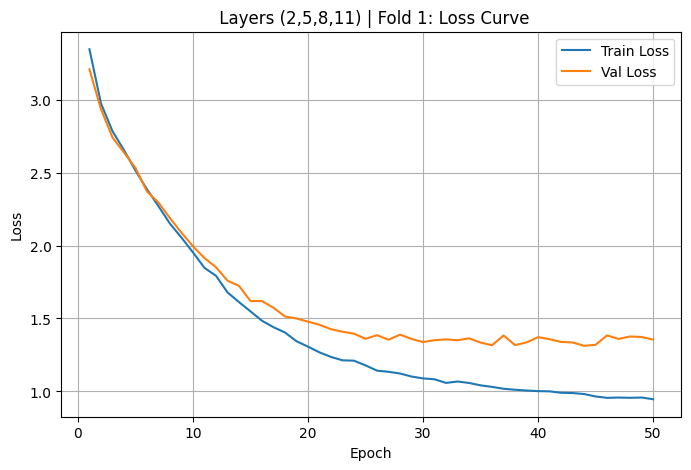

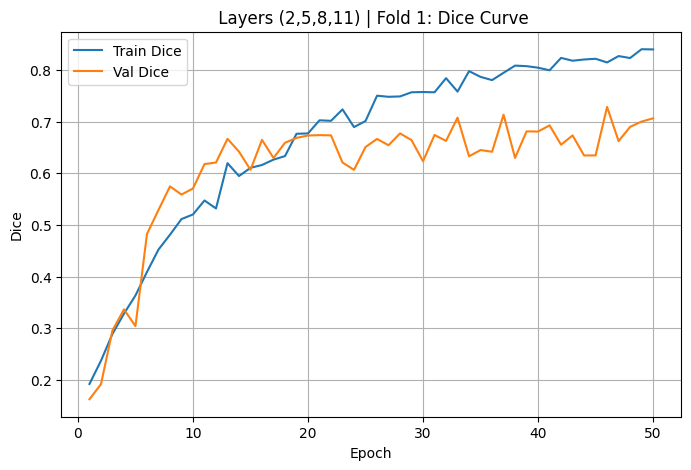

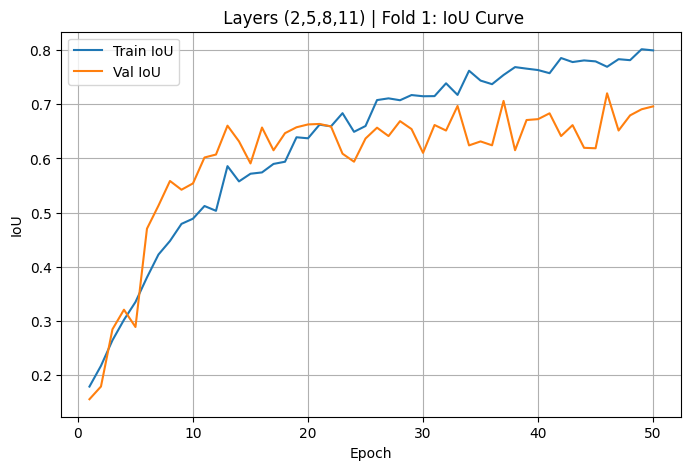

In [ ]:
# =========================
# Load history
# =========================

with open(HISTORY_PATH, "r") as f:
    history = json.load(f)

print("Available keys:", list(history.keys()))
print("Epochs logged:", len(history["epoch"]))

plt.figure(figsize=(8, 5))
plt.plot(history["epoch"], history["train_loss"], label="Train Loss")
plt.plot(history["epoch"], history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(" Layers (2,5,8,11) | Fold 1: Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["epoch"], history["train_dice"], label="Train Dice")
plt.plot(history["epoch"], history["val_dice"], label="Val Dice")
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.title(" Layers (2,5,8,11) | Fold 1: Dice Curve")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["epoch"], history["train_iou"], label="Train IoU")
plt.plot(history["epoch"], history["val_iou"], label="Val IoU")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.title(" Layers (2,5,8,11) | Fold 1: IoU Curve")
plt.legend()
plt.grid(True)
plt.show()

Run dir: /content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.0_seed42_kfold5_fold2
Checkpoint: /content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.0_seed42_kfold5_fold2/ckpts/best_ep031_dice0.7195_iou0.7113.pth
History: /content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.0_seed42_kfold5_fold2/history.json
Split: /content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.0_seed42_kfold5_fold2/split_config.json
Available keys: ['epoch', 'train_loss', 'train_dice', 'train_iou', 'val_loss', 'val_dice', 'val_iou']
Epochs logged: 50


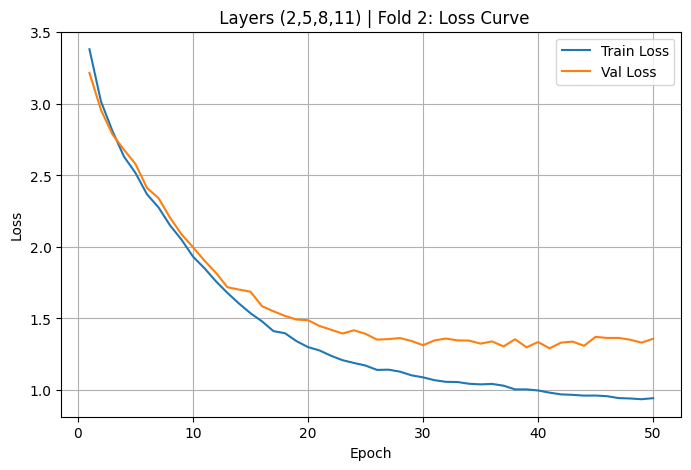

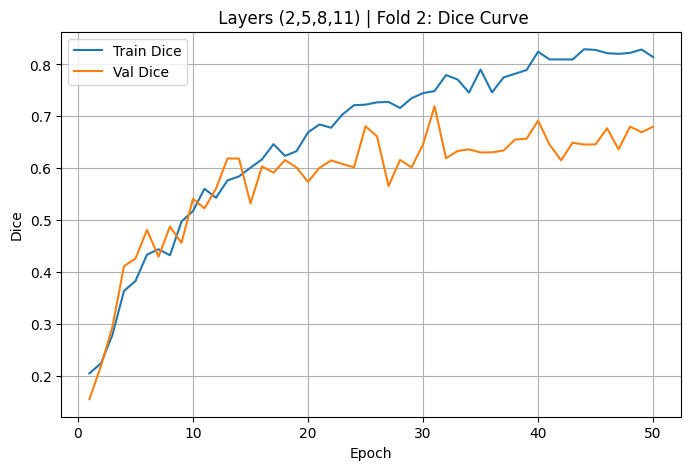

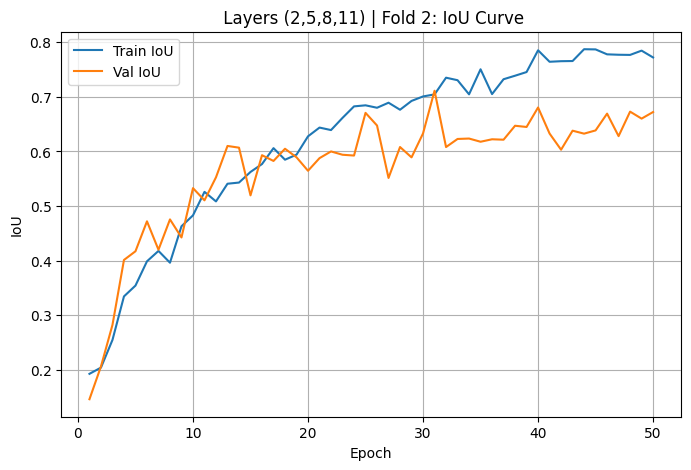

In [ ]:
import os
import json
import torch
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# Select run
# =========================

RUN_DIR = "/content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.0_seed42_kfold5_fold2"

HISTORY_PATH = os.path.join(RUN_DIR, "history.json")
SPLIT_PATH = os.path.join(RUN_DIR, "split_config.json")
CKPT_DIR = os.path.join(RUN_DIR, "ckpts")

# automatically pick best checkpoint
best_ckpts = sorted([
    f for f in os.listdir(CKPT_DIR)
    if f.startswith("best_") and f.endswith(".pth")
])

if len(best_ckpts) == 0:
    raise FileNotFoundError("No best checkpoint found.")

CKPT_PATH = os.path.join(CKPT_DIR, best_ckpts[-1])

print("Run dir:", RUN_DIR)
print("Checkpoint:", CKPT_PATH)
print("History:", HISTORY_PATH)
print("Split:", SPLIT_PATH)

# =========================
# Load history
# =========================

with open(HISTORY_PATH, "r") as f:
    history = json.load(f)

print("Available keys:", list(history.keys()))
print("Epochs logged:", len(history["epoch"]))

plt.figure(figsize=(8, 5))
plt.plot(history["epoch"], history["train_loss"], label="Train Loss")
plt.plot(history["epoch"], history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(" Layers (2,5,8,11) | Fold 2: Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["epoch"], history["train_dice"], label="Train Dice")
plt.plot(history["epoch"], history["val_dice"], label="Val Dice")
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.title(" Layers (2,5,8,11) | Fold 2: Dice Curve")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["epoch"], history["train_iou"], label="Train IoU")
plt.plot(history["epoch"], history["val_iou"], label="Val IoU")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.title(" Layers (2,5,8,11) | Fold 2: IoU Curve")
plt.legend()
plt.grid(True)
plt.show()

Run dir: /content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.0_seed42_kfold5_fold3
Checkpoint: /content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.0_seed42_kfold5_fold3/ckpts/best_ep045_dice0.7080_iou0.6905.pth
History: /content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.0_seed42_kfold5_fold3/history.json
Split: /content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.0_seed42_kfold5_fold3/split_config.json
Available keys: ['epoch', 'train_loss', 'train_dice', 'train_iou', 'val_loss', 'val_dice', 'val_iou']
Epochs logged: 50


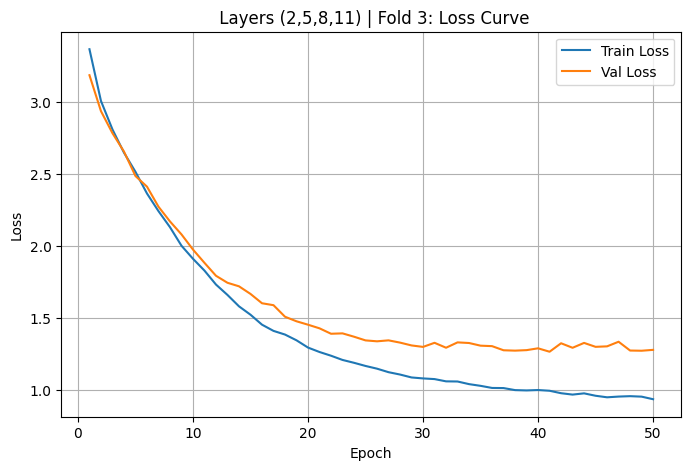

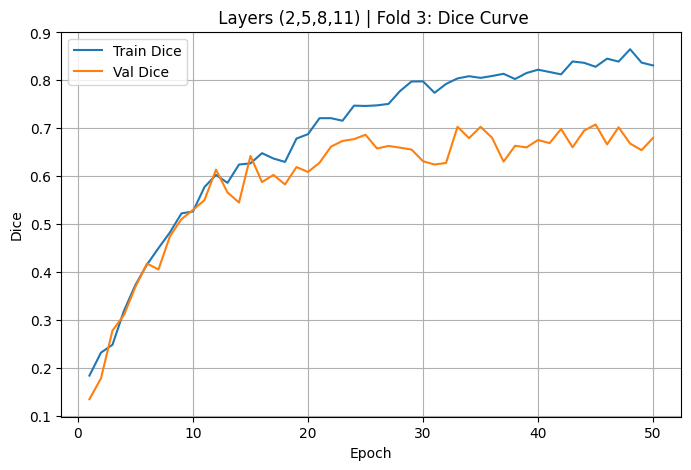

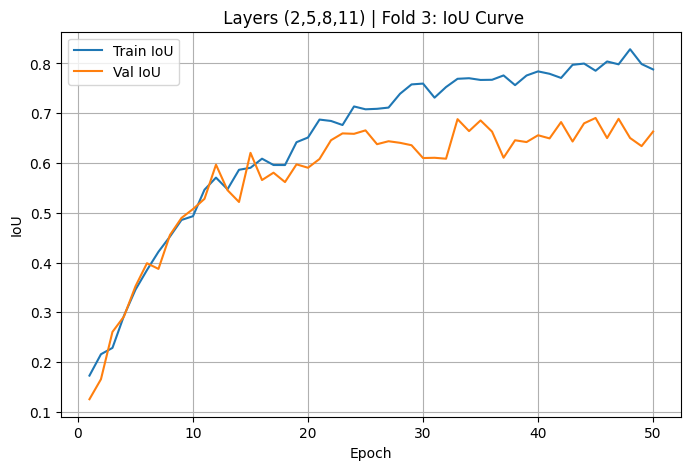

In [ ]:
import os
import json
import torch
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# Select run
# =========================

RUN_DIR = "/content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.0_seed42_kfold5_fold3"

HISTORY_PATH = os.path.join(RUN_DIR, "history.json")
SPLIT_PATH = os.path.join(RUN_DIR, "split_config.json")
CKPT_DIR = os.path.join(RUN_DIR, "ckpts")

# automatically pick best checkpoint
best_ckpts = sorted([
    f for f in os.listdir(CKPT_DIR)
    if f.startswith("best_") and f.endswith(".pth")
])

if len(best_ckpts) == 0:
    raise FileNotFoundError("No best checkpoint found.")

CKPT_PATH = os.path.join(CKPT_DIR, best_ckpts[-1])

print("Run dir:", RUN_DIR)
print("Checkpoint:", CKPT_PATH)
print("History:", HISTORY_PATH)
print("Split:", SPLIT_PATH)

# =========================
# Load history
# =========================

with open(HISTORY_PATH, "r") as f:
    history = json.load(f)

print("Available keys:", list(history.keys()))
print("Epochs logged:", len(history["epoch"]))

plt.figure(figsize=(8, 5))
plt.plot(history["epoch"], history["train_loss"], label="Train Loss")
plt.plot(history["epoch"], history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(" Layers (2,5,8,11) | Fold 3: Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["epoch"], history["train_dice"], label="Train Dice")
plt.plot(history["epoch"], history["val_dice"], label="Val Dice")
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.title(" Layers (2,5,8,11) | Fold 3: Dice Curve")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["epoch"], history["train_iou"], label="Train IoU")
plt.plot(history["epoch"], history["val_iou"], label="Val IoU")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.title(" Layers (2,5,8,11) | Fold 3: IoU Curve")
plt.legend()
plt.grid(True)
plt.show()

Run dir: /content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.0_seed42_kfold5_fold2
Checkpoint: /content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.0_seed42_kfold5_fold2/ckpts/best_ep031_dice0.7195_iou0.7113.pth
History: /content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.0_seed42_kfold5_fold2/history.json
Split: /content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.0_seed42_kfold5_fold2/split_config.json
Available keys: ['epoch', 'train_loss', 'train_dice', 'train_iou', 'val_loss', 'val_dice', 'val_iou']
Epochs logged: 50


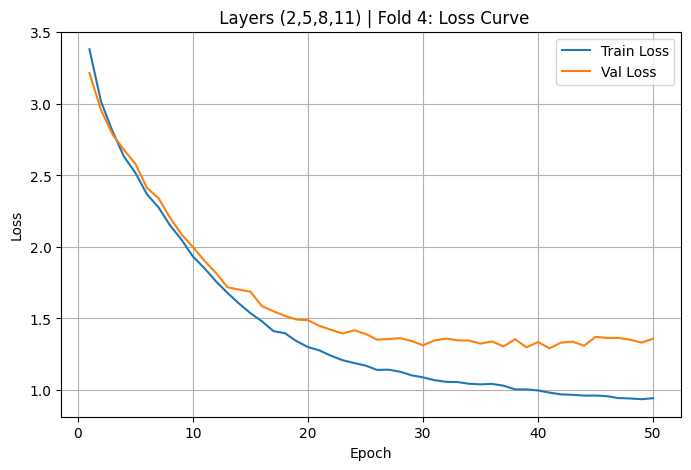

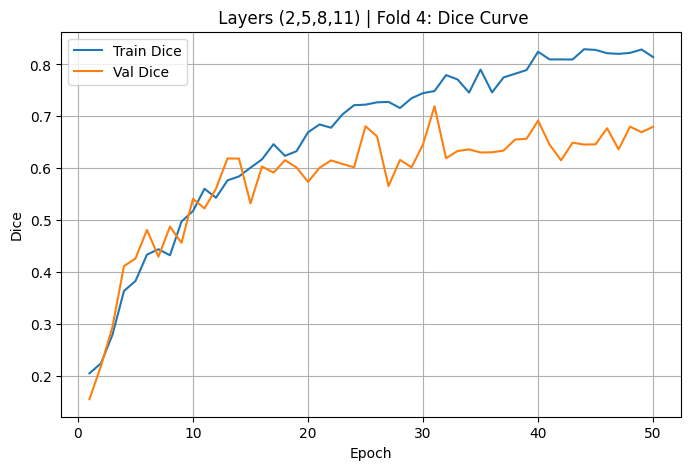

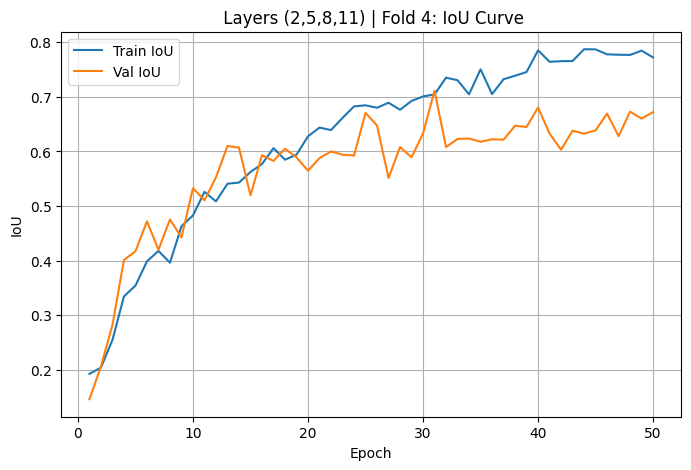

In [ ]:
import os
import json
import torch
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# Select run
# =========================

RUN_DIR = "/content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.0_seed42_kfold5_fold2"

HISTORY_PATH = os.path.join(RUN_DIR, "history.json")
SPLIT_PATH = os.path.join(RUN_DIR, "split_config.json")
CKPT_DIR = os.path.join(RUN_DIR, "ckpts")

# automatically pick best checkpoint
best_ckpts = sorted([
    f for f in os.listdir(CKPT_DIR)
    if f.startswith("best_") and f.endswith(".pth")
])

if len(best_ckpts) == 0:
    raise FileNotFoundError("No best checkpoint found.")

CKPT_PATH = os.path.join(CKPT_DIR, best_ckpts[-1])

print("Run dir:", RUN_DIR)
print("Checkpoint:", CKPT_PATH)
print("History:", HISTORY_PATH)
print("Split:", SPLIT_PATH)

# =========================
# Load history
# =========================

with open(HISTORY_PATH, "r") as f:
    history = json.load(f)

print("Available keys:", list(history.keys()))
print("Epochs logged:", len(history["epoch"]))

plt.figure(figsize=(8, 5))
plt.plot(history["epoch"], history["train_loss"], label="Train Loss")
plt.plot(history["epoch"], history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(" Layers (2,5,8,11) | Fold 4: Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["epoch"], history["train_dice"], label="Train Dice")
plt.plot(history["epoch"], history["val_dice"], label="Val Dice")
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.title(" Layers (2,5,8,11) | Fold 4: Dice Curve")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["epoch"], history["train_iou"], label="Train IoU")
plt.plot(history["epoch"], history["val_iou"], label="Val IoU")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.title(" Layers (2,5,8,11) | Fold 4: IoU Curve")
plt.legend()
plt.grid(True)
plt.show()

Run dir: /content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.0_seed42_kfold5_fold5
Checkpoint: /content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.0_seed42_kfold5_fold5/ckpts/best_ep028_dice0.7449_iou0.7368.pth
History: /content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.0_seed42_kfold5_fold5/history.json
Split: /content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.0_seed42_kfold5_fold5/split_config.json
Available keys: ['epoch', 'train_loss', 'train_dice', 'train_iou', 'val_loss', 'val_dice', 'val_iou']
Epochs logged: 50


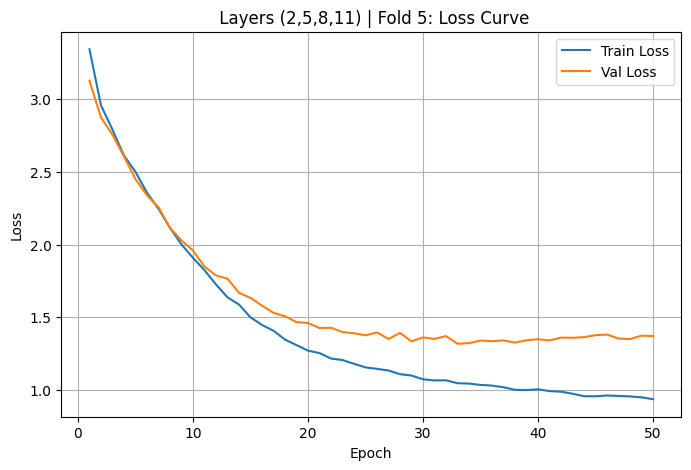

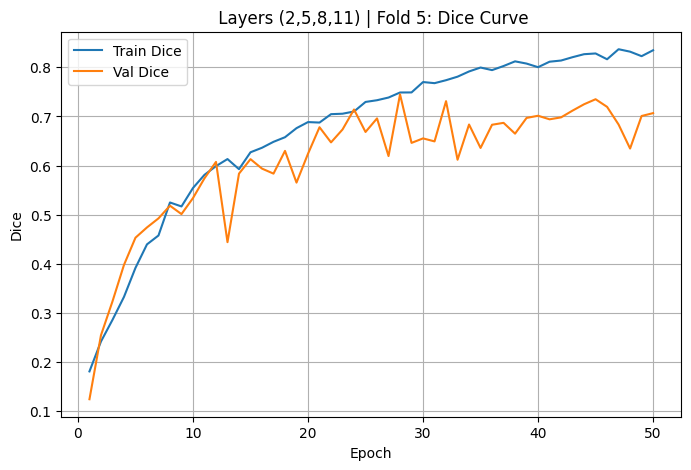

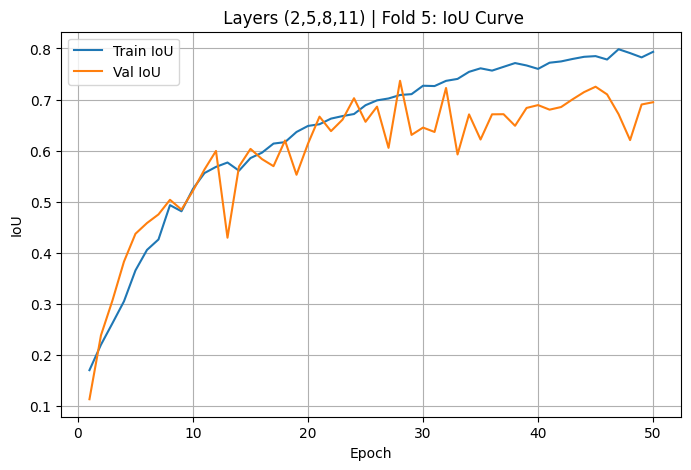

In [ ]:
import os
import json
import torch
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# Select run
# =========================

RUN_DIR = "/content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.0_seed42_kfold5_fold5"

HISTORY_PATH = os.path.join(RUN_DIR, "history.json")
SPLIT_PATH = os.path.join(RUN_DIR, "split_config.json")
CKPT_DIR = os.path.join(RUN_DIR, "ckpts")

# automatically pick best checkpoint
best_ckpts = sorted([
    f for f in os.listdir(CKPT_DIR)
    if f.startswith("best_") and f.endswith(".pth")
])

if len(best_ckpts) == 0:
    raise FileNotFoundError("No best checkpoint found.")

CKPT_PATH = os.path.join(CKPT_DIR, best_ckpts[-1])

print("Run dir:", RUN_DIR)
print("Checkpoint:", CKPT_PATH)
print("History:", HISTORY_PATH)
print("Split:", SPLIT_PATH)

# =========================
# Load history
# =========================

with open(HISTORY_PATH, "r") as f:
    history = json.load(f)

print("Available keys:", list(history.keys()))
print("Epochs logged:", len(history["epoch"]))

plt.figure(figsize=(8, 5))
plt.plot(history["epoch"], history["train_loss"], label="Train Loss")
plt.plot(history["epoch"], history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(" Layers (2,5,8,11) | Fold 5: Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["epoch"], history["train_dice"], label="Train Dice")
plt.plot(history["epoch"], history["val_dice"], label="Val Dice")
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.title(" Layers (2,5,8,11) | Fold 5: Dice Curve")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["epoch"], history["train_iou"], label="Train IoU")
plt.plot(history["epoch"], history["val_iou"], label="Val IoU")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.title(" Layers (2,5,8,11) | Fold 5: IoU Curve")
plt.legend()
plt.grid(True)
plt.show()

Run dir: /content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.0_seed42_kfold5_fold4
Checkpoint: /content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.0_seed42_kfold5_fold4/ckpts/best_ep035_dice0.7034_iou0.6965.pth
History: /content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.0_seed42_kfold5_fold4/history.json
Split: /content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.0_seed42_kfold5_fold4/split_config.json
Available keys: ['epoch', 'train_loss', 'train_dice', 'train_iou', 'val_loss', 'val_dice', 'val_iou']
Epochs logged: 50


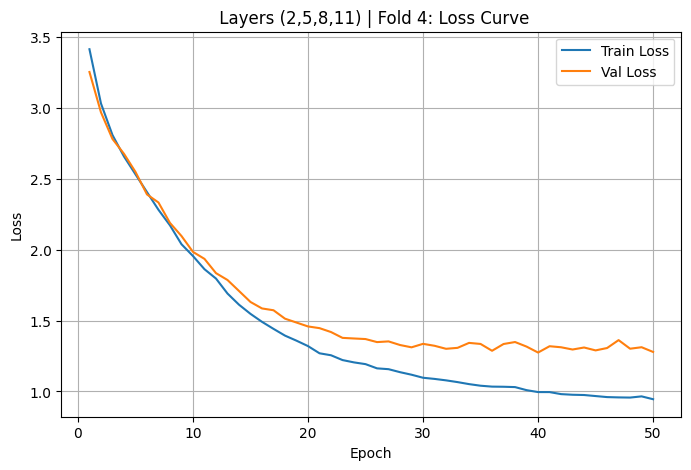

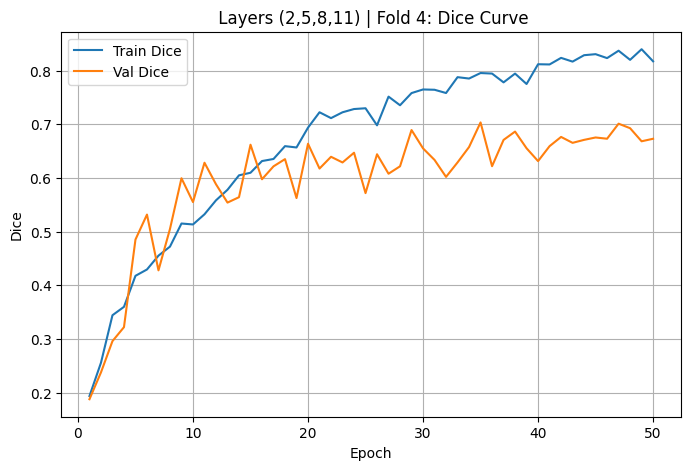

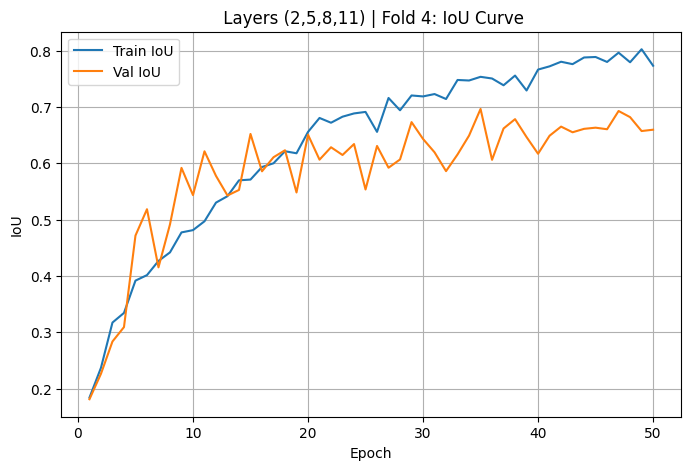

In [ ]:
import os
import json
import torch
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# Select run
# =========================

RUN_DIR = "/content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.0_seed42_kfold5_fold4"

HISTORY_PATH = os.path.join(RUN_DIR, "history.json")
SPLIT_PATH = os.path.join(RUN_DIR, "split_config.json")
CKPT_DIR = os.path.join(RUN_DIR, "ckpts")

# automatically pick best checkpoint
best_ckpts = sorted([
    f for f in os.listdir(CKPT_DIR)
    if f.startswith("best_") and f.endswith(".pth")
])

if len(best_ckpts) == 0:
    raise FileNotFoundError("No best checkpoint found.")

CKPT_PATH = os.path.join(CKPT_DIR, best_ckpts[-1])

print("Run dir:", RUN_DIR)
print("Checkpoint:", CKPT_PATH)
print("History:", HISTORY_PATH)
print("Split:", SPLIT_PATH)

# =========================
# Load history
# =========================

with open(HISTORY_PATH, "r") as f:
    history = json.load(f)

print("Available keys:", list(history.keys()))
print("Epochs logged:", len(history["epoch"]))

plt.figure(figsize=(8, 5))
plt.plot(history["epoch"], history["train_loss"], label="Train Loss")
plt.plot(history["epoch"], history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(" Layers (2,5,8,11) | Fold 4: Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["epoch"], history["train_dice"], label="Train Dice")
plt.plot(history["epoch"], history["val_dice"], label="Val Dice")
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.title(" Layers (2,5,8,11) | Fold 4: Dice Curve")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["epoch"], history["train_iou"], label="Train IoU")
plt.plot(history["epoch"], history["val_iou"], label="Val IoU")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.title(" Layers (2,5,8,11) | Fold 4: IoU Curve")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# !pip install pingouin -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from sklearn.metrics import cohen_kappa_score
import pingouin as pg

ALL_REGION_IDS = list(range(1, 11))


def safe_div(a, b):
    return a / b if b != 0 else np.nan


def fmt_metric(x):
    if pd.isna(x):
        return "-"
    return f"{x:.2f}"


def compute_kappa_safe(y_true, y_pred):
    y_true = list(y_true)
    y_pred = list(y_pred)

    if len(y_true) == 0:
        return np.nan

    if len(set(y_true)) == 1 and len(set(y_pred)) == 1:
        return 1.0 if y_true == y_pred else 0.0

    try:
        return cohen_kappa_score(y_true, y_pred)
    except Exception:
        return np.nan


def compute_icc_from_case_summary(case_summary_df):
    """
    Compute ICC between predicted and ground-truth ASPECTS scores
    using case-level summary dataframe.
    """
    if len(case_summary_df) == 0:
        return None

    df = pd.DataFrame({
        "targets": range(len(case_summary_df)),
        "predicted": case_summary_df["pred_case_aspects"].values,
        "ground_truth": case_summary_df["gt_case_aspects"].values,
    })

    df_long = df.melt(
        id_vars="targets",
        value_vars=["predicted", "ground_truth"],
        var_name="raters",
        value_name="value"
    )

    icc = pg.intraclass_corr(
        data=df_long,
        targets="targets",
        raters="raters",
        ratings="value"
    )

    return icc


def case_presence_metrics(gt_case_labels, pred_case_labels, all_region_ids=ALL_REGION_IDS):
    gt_set = set(gt_case_labels)
    pred_set = set(pred_case_labels)

    rows = []

    for region_id in all_region_ids:
        gt_pos = int(region_id in gt_set)
        pred_pos = int(region_id in pred_set)

        TP = int(gt_pos == 1 and pred_pos == 1)
        TN = int(gt_pos == 0 and pred_pos == 0)
        FP = int(gt_pos == 0 and pred_pos == 1)
        FN = int(gt_pos == 1 and pred_pos == 0)

        sensitivity = safe_div(TP, TP + FN)
        specificity = safe_div(TN, TN + FP)
        accuracy = safe_div(TP + TN, TP + TN + FP + FN)
        precision = safe_div(TP, TP + FP)
        f1 = safe_div(2 * TP, 2 * TP + FP + FN)
        dice = f1

        rows.append({
            "Region": REGION_NAME.get(region_id, str(region_id)),
            "GT": gt_pos,
            "Pred": pred_pos,
            "Sensitivity": sensitivity,
            "Specificity": specificity,
            "Accuracy": accuracy,
            "Precision": precision,
            "F1 Score": f1,
            "Dice": dice,
        })

    return pd.DataFrame(rows)


def pixelwise_metrics_per_region(pred_mask, gt_mask, num_classes=11, eps=1e-6):
    rows = []
    pred_mask = pred_mask.cpu()
    gt_mask = gt_mask.cpu()

    for c in range(1, num_classes):
        pred_c = (pred_mask == c).float()
        gt_c = (gt_mask == c).float()

        inter = (pred_c * gt_c).sum().item()
        pred_sum = pred_c.sum().item()
        gt_sum = gt_c.sum().item()

        denom_dice = pred_sum + gt_sum
        denom_iou = pred_sum + gt_sum - inter

        dice = np.nan if denom_dice == 0 else (2 * inter + eps) / (denom_dice + eps)
        iou = np.nan if denom_iou == 0 else (inter + eps) / (denom_iou + eps)

        rows.append({
            "Region": REGION_NAME.get(c, str(c)),
            "GT Pixels": int(gt_sum),
            "Pred Pixels": int(pred_sum),
            "Pixel Dice": dice,
            "Pixel IoU": iou,
        })

    return pd.DataFrame(rows)


def kappa_summary_from_presence_df(presence_all_cases_df):
    if presence_all_cases_df.empty:
        return np.nan, pd.DataFrame()

    overall_kappa = compute_kappa_safe(
        presence_all_cases_df["GT"],
        presence_all_cases_df["Pred"]
    )

    rows = []

    for region, df_region in presence_all_cases_df.groupby("Region"):
        kappa = compute_kappa_safe(df_region["GT"], df_region["Pred"])
        rows.append({
            "Region": region,
            "Cohen's Kappa": kappa
        })

    return overall_kappa, pd.DataFrame(rows)


def overall_summary_from_all_cases(case_summary_df, presence_all_cases_df, pixel_all_cases_df, split_name="val"):
    print("\n" + "=" * 120)
    print(f"OVERALL SUMMARY ACROSS ALL CASES ({split_name.upper()})")
    print("=" * 120)

    if len(case_summary_df) > 0:
        print("\nCASE-LEVEL ASPECTS SUMMARY")
        print(f"Number of cases        : {len(case_summary_df)}")
        print(f"Mean Absolute Error    : {case_summary_df['absolute_error'].mean():.4f}")
        print(f"Exact Match Accuracy   : {case_summary_df['exact_match'].mean():.4f}")

        print("\nAbsolute error distribution:")
        print(case_summary_df["absolute_error"].value_counts().sort_index())

        print("\nINTRACLASS CORRELATION COEFFICIENT (ICC)")
        icc_table = compute_icc_from_case_summary(case_summary_df)
        display(icc_table)

        icc2 = icc_table[icc_table["Type"] == "ICC2"]
        if len(icc2) > 0:
            print(f"\nSelected ICC(2,1): {icc2['ICC'].values[0]:.4f}")
            print(f"95% CI          : {icc2['CI95%'].values[0]}")

    if len(presence_all_cases_df) > 0:
        presence_cols = ["Sensitivity", "Specificity", "Accuracy", "Precision", "F1 Score", "Dice"]

        print("\nOVERALL MEAN CASE-PRESENCE METRICS")
        print(presence_all_cases_df[presence_cols].mean(numeric_only=True))

        print("\nPER-REGION CASE-PRESENCE METRICS")
        display(
            presence_all_cases_df.groupby("Region")[presence_cols]
            .mean(numeric_only=True)
            .reset_index()
        )

        overall_kappa, per_region_kappa_df = kappa_summary_from_presence_df(presence_all_cases_df)
        print(f"\nOverall Cohen's Kappa for region involvement: {overall_kappa:.4f}")

        print("\nPER-REGION COHEN'S KAPPA")
        display(per_region_kappa_df)

    if len(pixel_all_cases_df) > 0:
        pixel_cols = ["Pixel Dice", "Pixel IoU"]

        print("\nOVERALL MEAN PIXEL-WISE METRICS")
        print(pixel_all_cases_df[pixel_cols].mean(numeric_only=True))

        print("\nPER-REGION MEAN PIXEL-WISE METRICS")
        display(
            pixel_all_cases_df.groupby("Region")[pixel_cols]
            .mean(numeric_only=True)
            .reset_index()
        )

In [ ]:
def show_case_with_aspects_alias(dataset, model, case_id, case_to_alias):
    case_map = build_case_index_map(dataset)

    if case_id not in case_map:
        print(f"Case {case_id} not found.")
        return None

    entries = case_map[case_id]
    bg_entry, sg_entry, middle_entries = classify_bg_sg(entries)

    all_gt_labels = set()
    all_pred_labels = set()

    case_alias = case_to_alias.get(case_id, case_id)

    print("=" * 110)
    print(f"CASE ALIAS: {case_alias}")
    print(f"Original Case ID: {case_id}")
    print(f"Total slices found: {len(entries)}")

    if bg_entry is not None:
        print(f"BG candidate slice: {dataset[bg_entry[1]][2]['id']} (z={bg_entry[0]})")

    if sg_entry is not None:
        print(f"SG candidate slice: {dataset[sg_entry[1]][2]['id']} (z={sg_entry[0]})")

    if middle_entries:
        print("Additional slice(s):", [dataset[idx][2]["id"] for _, idx in middle_entries])

    per_slice_pixel_tables = []

    # -------- Slice-wise visuals --------
    for z, idx in entries:
        image, gt_mask, meta = dataset[idx]
        pred_mask, _ = predict_sample(model, image)

        gt_labels = labels_from_mask(gt_mask)
        pred_labels = labels_from_mask(pred_mask)

        all_gt_labels.update(gt_labels)
        all_pred_labels.update(pred_labels)

        gt_aspects = aspects_from_labels(gt_labels)
        pred_aspects = aspects_from_labels(pred_labels)

        pixel_df = pixelwise_metrics_per_region(pred_mask, gt_mask, num_classes=11)
        pixel_df["slice_id"] = meta["id"]
        pixel_df["z"] = z
        per_slice_pixel_tables.append(pixel_df)

        print("-" * 110)
        print(f"Slice ID      : {meta['id']} | z={z}")
        print(f"GT labels     : {[REGION_NAME.get(x, x) for x in gt_labels]}")
        print(f"Pred labels   : {[REGION_NAME.get(x, x) for x in pred_labels]}")
        print(f"GT ASPECTS    : {gt_aspects}")
        print(f"Pred ASPECTS  : {pred_aspects}")

        pixel_display = pixel_df.copy()
        pixel_display["Pixel Dice"] = pixel_display["Pixel Dice"].apply(fmt_metric)
        pixel_display["Pixel IoU"] = pixel_display["Pixel IoU"].apply(fmt_metric)

        fig = plt.figure(figsize=(22, 8))
        gs = GridSpec(2, 5, height_ratios=[2.2, 1.2], figure=fig)

        ax0 = fig.add_subplot(gs[0, 0])
        ax1 = fig.add_subplot(gs[0, 1])
        ax2 = fig.add_subplot(gs[0, 2])
        ax3 = fig.add_subplot(gs[0, 3])
        ax4 = fig.add_subplot(gs[0, 4])

        ax0.imshow(image.permute(1, 2, 0).cpu())
        ax0.set_title("Image")

        ax1.imshow(mask_to_rgb(gt_mask))
        ax1.set_title("Ground Truth")

        ax2.imshow(mask_to_rgb(pred_mask))
        ax2.set_title("Prediction")

        ax3.imshow(overlay_mask_on_image(image, gt_mask))
        ax3.set_title("GT Overlay")

        ax4.imshow(overlay_mask_on_image(image, pred_mask))
        ax4.set_title("Pred Overlay")

        for ax in [ax0, ax1, ax2, ax3, ax4]:
            ax.axis("off")

        ax_tbl = fig.add_subplot(gs[1, :])
        ax_tbl.axis("off")

        table = ax_tbl.table(
            cellText=pixel_display[
                ["Region", "GT Pixels", "Pred Pixels", "Pixel Dice", "Pixel IoU"]
            ].values,
            colLabels=["Region", "GT Pixels", "Pred Pixels", "Pixel Dice", "Pixel IoU"],
            loc="center",
            cellLoc="center"
        )

        table.auto_set_font_size(False)
        table.set_fontsize(8.5)
        table.scale(1, 1.2)

        plt.suptitle(
            f"{case_alias} | Slice {meta['id']} | GT ASPECTS={gt_aspects} | Pred ASPECTS={pred_aspects}",
            fontsize=14
        )
        plt.tight_layout()
        plt.show()

    # -------- Case-level summary --------
    case_gt_labels = sorted(all_gt_labels)
    case_pred_labels = sorted(all_pred_labels)

    case_gt_aspects = aspects_from_labels(case_gt_labels)
    case_pred_aspects = aspects_from_labels(case_pred_labels)

    presence_df = case_presence_metrics(case_gt_labels, case_pred_labels)

    print("=" * 110)
    print("CASE-LEVEL SUMMARY")
    print(f"Case Alias         : {case_alias}")
    print(f"GT case labels     : {[REGION_NAME.get(x, x) for x in case_gt_labels]}")
    print(f"Pred case labels   : {[REGION_NAME.get(x, x) for x in case_pred_labels]}")
    print(f"GT CASE ASPECTS    : {case_gt_aspects}")
    print(f"PRED CASE ASPECTS  : {case_pred_aspects}")
    print("=" * 110)

    presence_display = presence_df.copy()

    for col in ["Sensitivity", "Specificity", "Accuracy", "Precision", "F1 Score", "Dice"]:
        presence_display[col] = presence_display[col].apply(fmt_metric)

    fig = plt.figure(figsize=(19, 6))
    gs = GridSpec(1, 2, width_ratios=[1.2, 4.0], figure=fig)

    ax_left = fig.add_subplot(gs[0, 0])
    ax_left.axis("off")

    summary_text = (
        f"Case Alias: {case_alias}\n"
        f"Original Case ID: {case_id}\n\n"
        f"GT Regions:\n"
        f"{', '.join([REGION_NAME.get(x, x) for x in case_gt_labels]) if case_gt_labels else 'None'}\n\n"
        f"Pred Regions:\n"
        f"{', '.join([REGION_NAME.get(x, x) for x in case_pred_labels]) if case_pred_labels else 'None'}\n\n"
        f"GT ASPECTS: {case_gt_aspects}\n"
        f"Pred ASPECTS: {case_pred_aspects}\n"
        f"Absolute Error: {abs(case_gt_aspects - case_pred_aspects)}"
    )

    ax_left.text(0.0, 1.0, summary_text, va="top", fontsize=11)

    ax_right = fig.add_subplot(gs[0, 1])
    ax_right.axis("off")

    table = ax_right.table(
        cellText=presence_display.values,
        colLabels=presence_display.columns,
        loc="center",
        cellLoc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(8.3)
    table.scale(1, 1.3)

    plt.suptitle(f"{case_alias} | Case-level Presence Metrics", fontsize=14)
    plt.tight_layout()
    plt.show()

    pixel_all_slices_df = pd.concat(per_slice_pixel_tables, ignore_index=True)

    return {
        "case_alias": case_alias,
        "original_case_id": case_id,
        "gt_case_labels": [REGION_NAME.get(x, x) for x in case_gt_labels],
        "pred_case_labels": [REGION_NAME.get(x, x) for x in case_pred_labels],
        "gt_case_aspects": case_gt_aspects,
        "pred_case_aspects": case_pred_aspects,
        "absolute_error": abs(case_gt_aspects - case_pred_aspects),
        "exact_match": int(case_gt_aspects == case_pred_aspects),
        "presence_df": presence_df,
        "pixel_all_slices_df": pixel_all_slices_df,
    }

In [ ]:
%cd /content/SegDINO

!python train_segdino_multilayer_sampler.py \
  --repo_dir "/content/dinov3" \
  --dino_ckpt "/content/web_pth/dinov3_vits16_pretrain_lvd1689m-08c60483.pth" \
  --dino_size s \
  --epochs 50 \
  --batch_size 4 \
  --input_h 256 \
  --input_w 256 \
  --num_classes 11 \
  --lr 1e-4 \
  --data_root "/content/drive/MyDrive/HibaAzeem/thesis_folder/__Aku_dataset_segdino_v2" \
  --layer_indices 2 5 8 11 \
  --dice_weight 0.5 \
  --use_lora \
  --use_tagl \
  --tagl_weight 0.05 \
  --tau 0.5 \
  --tagl_start_epoch 15 \
  --kfold \
  --num_folds 5 \
  --fold_idx {fold}

### 0.5 dice weight

In [ ]:
 import json
import numpy as np
from pathlib import Path

ROOT = Path("/content/SegDINO/runs")

target = "aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew0.5_seed42_kfold5"

dice_scores = []
iou_scores = []

for f in sorted(ROOT.glob(target + "_fold*/best_summary.json")):
    with open(f, "r") as fp:
        data = json.load(fp)

    dice_scores.append(data["best_val_dice"])
    iou_scores.append(data["best_val_iou"])

    print(f.parent.name)
    print("Dice:", data["best_val_dice"])
    print("IoU :", data["best_val_iou"])
    print("-" * 40)

print("=" * 60)
print(f"Dice = {np.mean(dice_scores):.4f} ± {np.std(dice_scores):.4f}")
print(f"IoU  = {np.mean(iou_scores):.4f} ± {np.std(iou_scores):.4f}")
print("=" * 60)

aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew0.5_seed42_kfold5_fold1
Dice: 0.7255591811104254
IoU : 0.7178610868074677
----------------------------------------
aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew0.5_seed42_kfold5_fold2
Dice: 0.7098634577378994
IoU : 0.7017668282113424
----------------------------------------
aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew0.5_seed42_kfold5_fold3
Dice: 0.7157209554785177
IoU : 0.7034272128029874
----------------------------------------
aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew0.5_seed42_kfold5_fold4
Dice: 0.7197615428026333
IoU : 0.7137662075286688
----------------------------------------
aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew0.5_seed42_kfold5_fold5
Dice: 0.7427942711446021
IoU : 0.7348437897033162
----------------------------------------
Dice = 0.7227 ± 0.0113
IoU  = 0.7143 ± 0.0119


#### GRaphs

Run dir: /content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew0.5_seed42_kfold5_fold1
Checkpoint: /content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew0.5_seed42_kfold5_fold1/ckpts/best_ep046_dice0.7256_iou0.7179.pth
History: /content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew0.5_seed42_kfold5_fold1/history.json
Split: /content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew0.5_seed42_kfold5_fold1/split_config.json
Available keys: ['epoch', 'train_loss', 'train_dice', 'train_iou', 'val_loss', 'val_dice', 'val_iou']
Epochs logged: 50


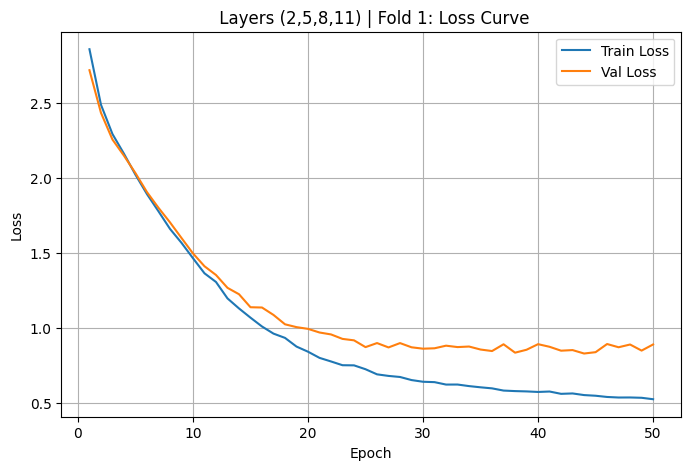

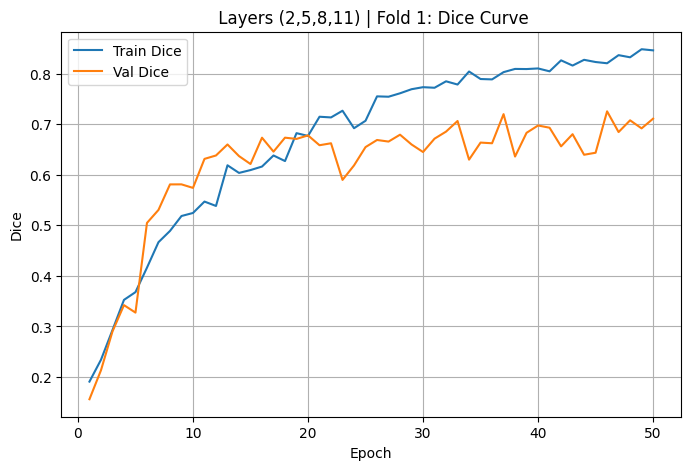

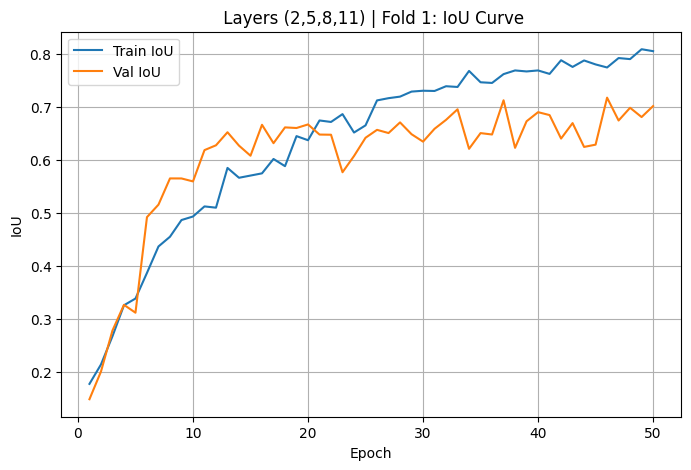

In [ ]:
import os
import json
import torch
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# Select run
# =========================

RUN_DIR = "/content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew0.5_seed42_kfold5_fold1"

HISTORY_PATH = os.path.join(RUN_DIR, "history.json")
SPLIT_PATH = os.path.join(RUN_DIR, "split_config.json")
CKPT_DIR = os.path.join(RUN_DIR, "ckpts")

# automatically pick best checkpoint
best_ckpts = sorted([
    f for f in os.listdir(CKPT_DIR)
    if f.startswith("best_") and f.endswith(".pth")
])

if len(best_ckpts) == 0:
    raise FileNotFoundError("No best checkpoint found.")

CKPT_PATH = os.path.join(CKPT_DIR, best_ckpts[-1])

print("Run dir:", RUN_DIR)
print("Checkpoint:", CKPT_PATH)
print("History:", HISTORY_PATH)
print("Split:", SPLIT_PATH)

# =========================
# Load history
# =========================

with open(HISTORY_PATH, "r") as f:
    history = json.load(f)

print("Available keys:", list(history.keys()))
print("Epochs logged:", len(history["epoch"]))

plt.figure(figsize=(8, 5))
plt.plot(history["epoch"], history["train_loss"], label="Train Loss")
plt.plot(history["epoch"], history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(" Layers (2,5,8,11) | Fold 1: Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["epoch"], history["train_dice"], label="Train Dice")
plt.plot(history["epoch"], history["val_dice"], label="Val Dice")
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.title(" Layers (2,5,8,11) | Fold 1: Dice Curve")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["epoch"], history["train_iou"], label="Train IoU")
plt.plot(history["epoch"], history["val_iou"], label="Val IoU")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.title(" Layers (2,5,8,11) | Fold 1: IoU Curve")
plt.legend()
plt.grid(True)
plt.show()

Run dir: /content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew0.5_seed42_kfold5_fold2
Checkpoint: /content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew0.5_seed42_kfold5_fold2/ckpts/best_ep031_dice0.7099_iou0.7018.pth
History: /content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew0.5_seed42_kfold5_fold2/history.json
Split: /content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew0.5_seed42_kfold5_fold2/split_config.json
Available keys: ['epoch', 'train_loss', 'train_dice', 'train_iou', 'val_loss', 'val_dice', 'val_iou']
Epochs logged: 50


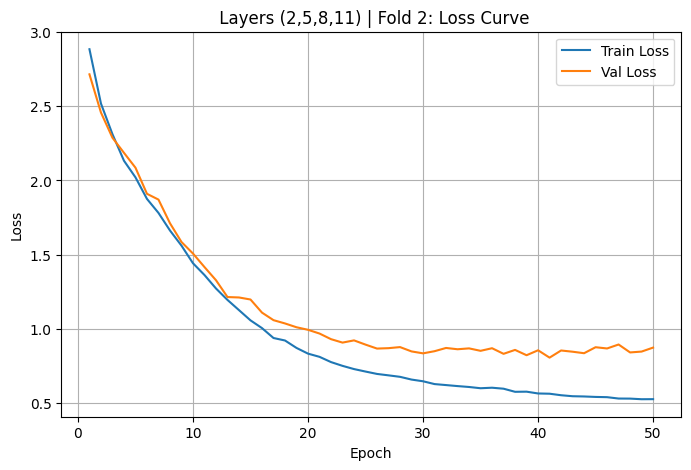

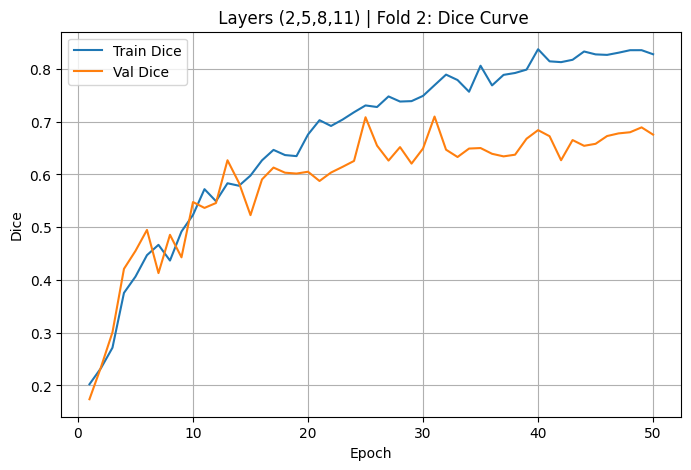

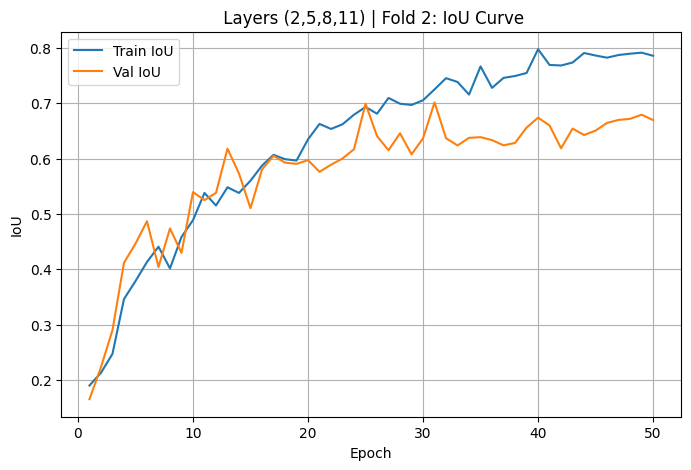

In [ ]:

# =========================
# Select run
# =========================

RUN_DIR = "/content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew0.5_seed42_kfold5_fold2"

HISTORY_PATH = os.path.join(RUN_DIR, "history.json")
SPLIT_PATH = os.path.join(RUN_DIR, "split_config.json")
CKPT_DIR = os.path.join(RUN_DIR, "ckpts")

# automatically pick best checkpoint
best_ckpts = sorted([
    f for f in os.listdir(CKPT_DIR)
    if f.startswith("best_") and f.endswith(".pth")
])

if len(best_ckpts) == 0:
    raise FileNotFoundError("No best checkpoint found.")

CKPT_PATH = os.path.join(CKPT_DIR, best_ckpts[-1])

print("Run dir:", RUN_DIR)
print("Checkpoint:", CKPT_PATH)
print("History:", HISTORY_PATH)
print("Split:", SPLIT_PATH)

# =========================
# Load history
# =========================

with open(HISTORY_PATH, "r") as f:
    history = json.load(f)

print("Available keys:", list(history.keys()))
print("Epochs logged:", len(history["epoch"]))

plt.figure(figsize=(8, 5))
plt.plot(history["epoch"], history["train_loss"], label="Train Loss")
plt.plot(history["epoch"], history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(" Layers (2,5,8,11) | Fold 2: Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["epoch"], history["train_dice"], label="Train Dice")
plt.plot(history["epoch"], history["val_dice"], label="Val Dice")
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.title(" Layers (2,5,8,11) | Fold 2: Dice Curve")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["epoch"], history["train_iou"], label="Train IoU")
plt.plot(history["epoch"], history["val_iou"], label="Val IoU")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.title(" Layers (2,5,8,11) | Fold 2: IoU Curve")
plt.legend()
plt.grid(True)
plt.show()

Run dir: /content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew0.5_seed42_kfold5_fold3
Checkpoint: /content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew0.5_seed42_kfold5_fold3/ckpts/best_ep047_dice0.7157_iou0.7034.pth
History: /content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew0.5_seed42_kfold5_fold3/history.json
Split: /content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew0.5_seed42_kfold5_fold3/split_config.json
Available keys: ['epoch', 'train_loss', 'train_dice', 'train_iou', 'val_loss', 'val_dice', 'val_iou']
Epochs logged: 50


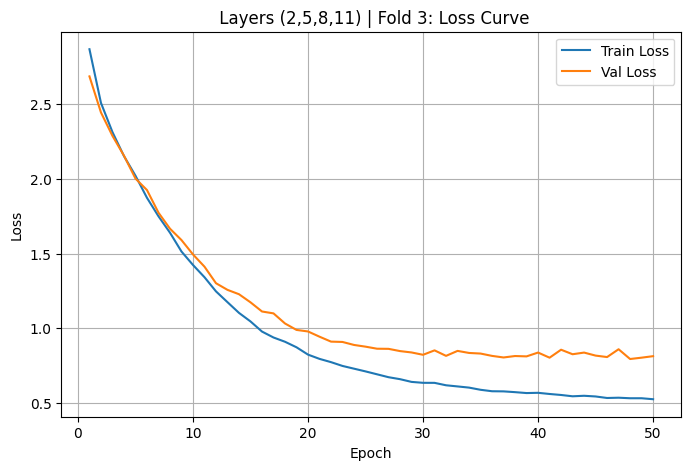

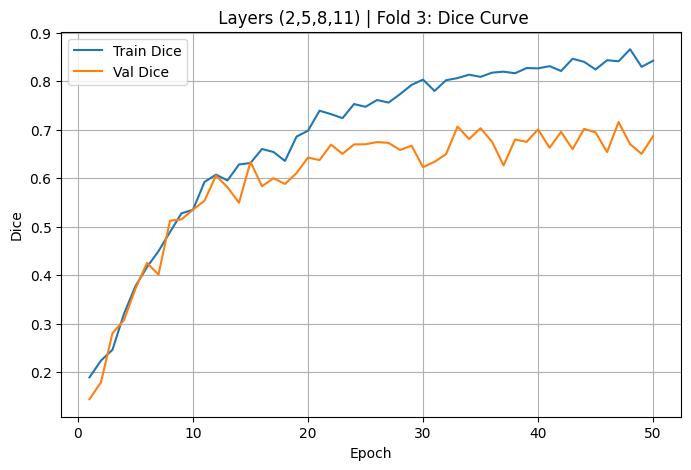

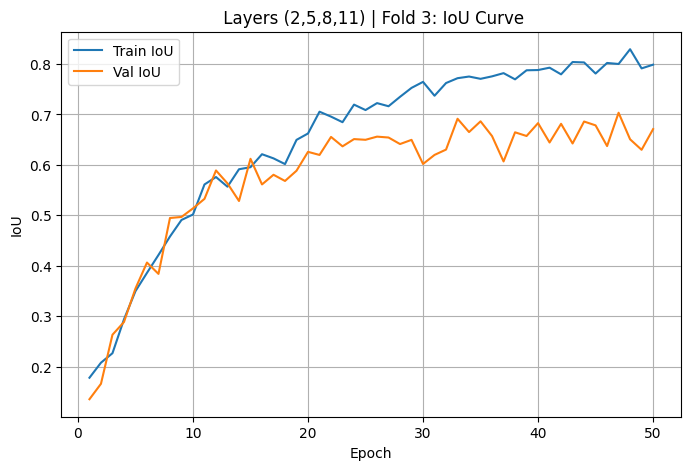

In [ ]:
import os
import json
import torch
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# Select run
# =========================

RUN_DIR = "/content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew0.5_seed42_kfold5_fold3"

HISTORY_PATH = os.path.join(RUN_DIR, "history.json")
SPLIT_PATH = os.path.join(RUN_DIR, "split_config.json")
CKPT_DIR = os.path.join(RUN_DIR, "ckpts")

# automatically pick best checkpoint
best_ckpts = sorted([
    f for f in os.listdir(CKPT_DIR)
    if f.startswith("best_") and f.endswith(".pth")
])

if len(best_ckpts) == 0:
    raise FileNotFoundError("No best checkpoint found.")

CKPT_PATH = os.path.join(CKPT_DIR, best_ckpts[-1])

print("Run dir:", RUN_DIR)
print("Checkpoint:", CKPT_PATH)
print("History:", HISTORY_PATH)
print("Split:", SPLIT_PATH)

# =========================
# Load history
# =========================

with open(HISTORY_PATH, "r") as f:
    history = json.load(f)

print("Available keys:", list(history.keys()))
print("Epochs logged:", len(history["epoch"]))

plt.figure(figsize=(8, 5))
plt.plot(history["epoch"], history["train_loss"], label="Train Loss")
plt.plot(history["epoch"], history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(" Layers (2,5,8,11) | Fold 3: Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["epoch"], history["train_dice"], label="Train Dice")
plt.plot(history["epoch"], history["val_dice"], label="Val Dice")
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.title(" Layers (2,5,8,11) | Fold 3: Dice Curve")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["epoch"], history["train_iou"], label="Train IoU")
plt.plot(history["epoch"], history["val_iou"], label="Val IoU")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.title(" Layers (2,5,8,11) | Fold 3: IoU Curve")
plt.legend()
plt.grid(True)
plt.show()

Run dir: /content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew0.5_seed42_kfold5_fold4
Checkpoint: /content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew0.5_seed42_kfold5_fold4/ckpts/best_ep047_dice0.7198_iou0.7138.pth
History: /content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew0.5_seed42_kfold5_fold4/history.json
Split: /content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew0.5_seed42_kfold5_fold4/split_config.json
Available keys: ['epoch', 'train_loss', 'train_dice', 'train_iou', 'val_loss', 'val_dice', 'val_iou']
Epochs logged: 50


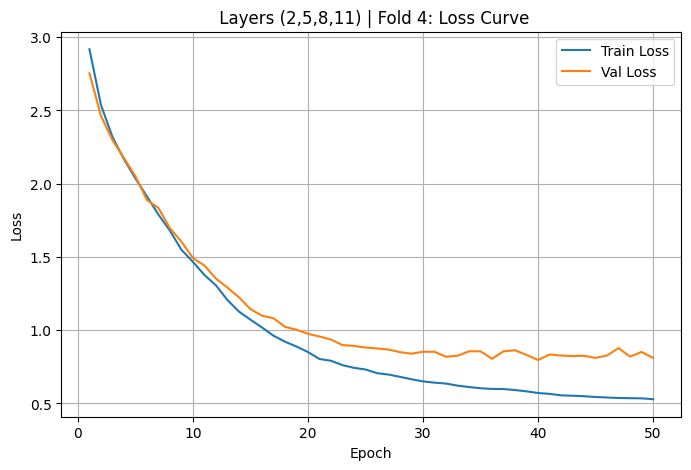

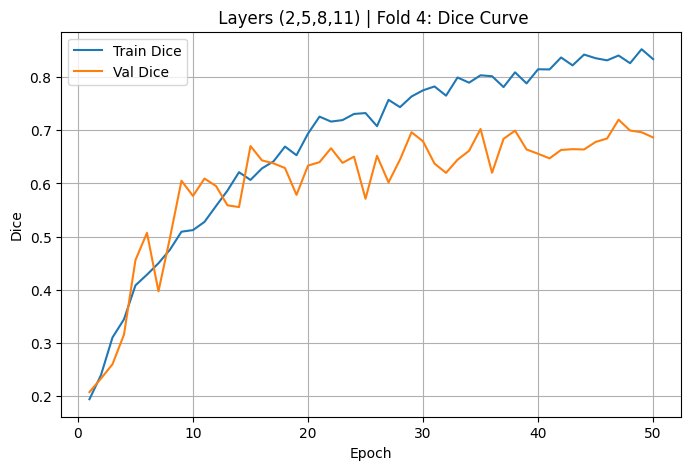

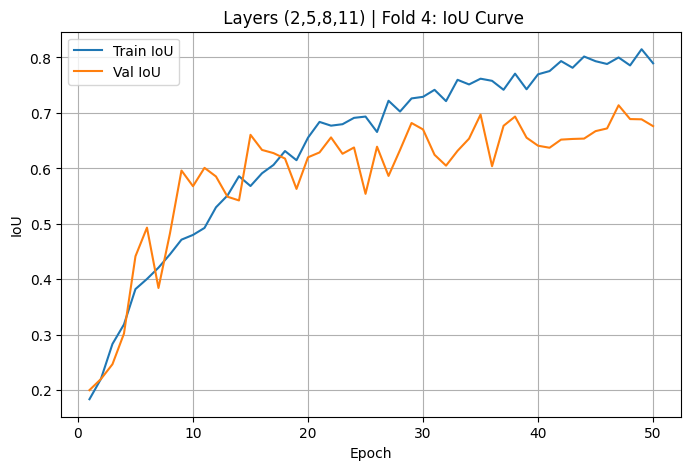

In [ ]:
import os
import json
import torch
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# Select run
# =========================

RUN_DIR = "/content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew0.5_seed42_kfold5_fold4"

HISTORY_PATH = os.path.join(RUN_DIR, "history.json")
SPLIT_PATH = os.path.join(RUN_DIR, "split_config.json")
CKPT_DIR = os.path.join(RUN_DIR, "ckpts")

# automatically pick best checkpoint
best_ckpts = sorted([
    f for f in os.listdir(CKPT_DIR)
    if f.startswith("best_") and f.endswith(".pth")
])

if len(best_ckpts) == 0:
    raise FileNotFoundError("No best checkpoint found.")

CKPT_PATH = os.path.join(CKPT_DIR, best_ckpts[-1])

print("Run dir:", RUN_DIR)
print("Checkpoint:", CKPT_PATH)
print("History:", HISTORY_PATH)
print("Split:", SPLIT_PATH)

# =========================
# Load history
# =========================

with open(HISTORY_PATH, "r") as f:
    history = json.load(f)

print("Available keys:", list(history.keys()))
print("Epochs logged:", len(history["epoch"]))

plt.figure(figsize=(8, 5))
plt.plot(history["epoch"], history["train_loss"], label="Train Loss")
plt.plot(history["epoch"], history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(" Layers (2,5,8,11) | Fold 4: Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["epoch"], history["train_dice"], label="Train Dice")
plt.plot(history["epoch"], history["val_dice"], label="Val Dice")
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.title(" Layers (2,5,8,11) | Fold 4: Dice Curve")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["epoch"], history["train_iou"], label="Train IoU")
plt.plot(history["epoch"], history["val_iou"], label="Val IoU")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.title(" Layers (2,5,8,11) | Fold 4: IoU Curve")
plt.legend()
plt.grid(True)
plt.show()

Run dir: /content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew0.5_seed42_kfold5_fold5
Checkpoint: /content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew0.5_seed42_kfold5_fold5/ckpts/best_ep028_dice0.7428_iou0.7348.pth
History: /content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew0.5_seed42_kfold5_fold5/history.json
Split: /content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew0.5_seed42_kfold5_fold5/split_config.json
Available keys: ['epoch', 'train_loss', 'train_dice', 'train_iou', 'val_loss', 'val_dice', 'val_iou']
Epochs logged: 50


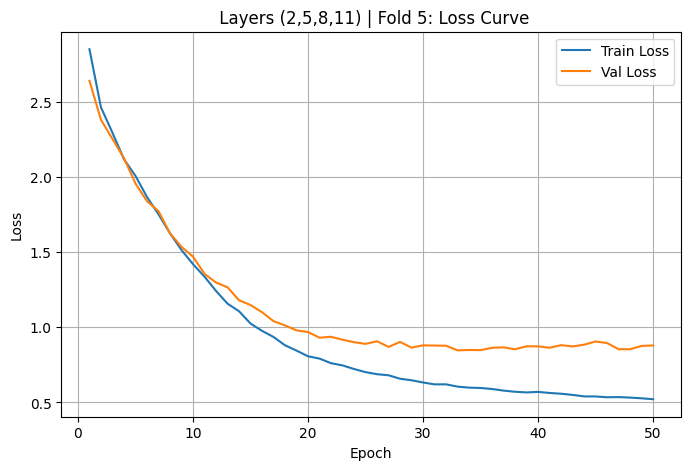

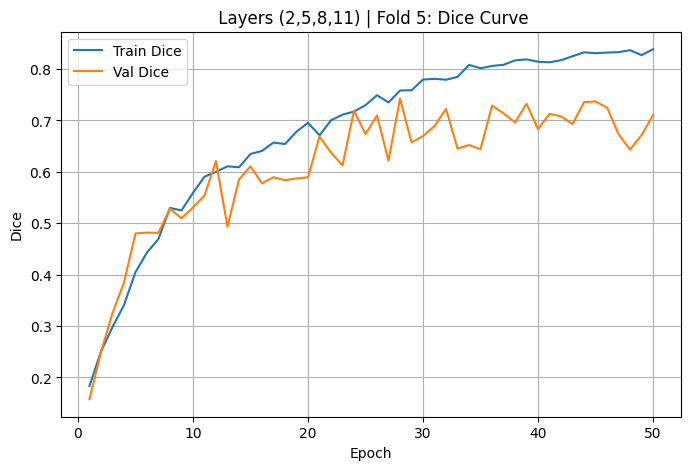

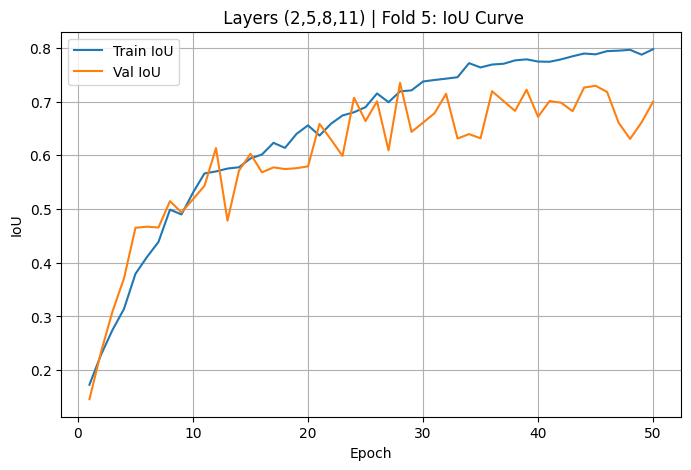

In [ ]:
import os
import json
import torch
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# Select run
# =========================

RUN_DIR = "/content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew0.5_seed42_kfold5_fold5"

HISTORY_PATH = os.path.join(RUN_DIR, "history.json")
SPLIT_PATH = os.path.join(RUN_DIR, "split_config.json")
CKPT_DIR = os.path.join(RUN_DIR, "ckpts")

# automatically pick best checkpoint
best_ckpts = sorted([
    f for f in os.listdir(CKPT_DIR)
    if f.startswith("best_") and f.endswith(".pth")
])

if len(best_ckpts) == 0:
    raise FileNotFoundError("No best checkpoint found.")

CKPT_PATH = os.path.join(CKPT_DIR, best_ckpts[-1])

print("Run dir:", RUN_DIR)
print("Checkpoint:", CKPT_PATH)
print("History:", HISTORY_PATH)
print("Split:", SPLIT_PATH)

# =========================
# Load history
# =========================

with open(HISTORY_PATH, "r") as f:
    history = json.load(f)

print("Available keys:", list(history.keys()))
print("Epochs logged:", len(history["epoch"]))

plt.figure(figsize=(8, 5))
plt.plot(history["epoch"], history["train_loss"], label="Train Loss")
plt.plot(history["epoch"], history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(" Layers (2,5,8,11) | Fold 5: Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["epoch"], history["train_dice"], label="Train Dice")
plt.plot(history["epoch"], history["val_dice"], label="Val Dice")
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.title(" Layers (2,5,8,11) | Fold 5: Dice Curve")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["epoch"], history["train_iou"], label="Train IoU")
plt.plot(history["epoch"], history["val_iou"], label="Val IoU")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.title(" Layers (2,5,8,11) | Fold 5: IoU Curve")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
%cd /content/SegDINO

!python train_segdino_multilayer_sampler.py \
  --repo_dir "/content/dinov3" \
  --dino_ckpt "/content/web_pth/dinov3_vits16_pretrain_lvd1689m-08c60483.pth" \
  --dino_size s \
  --epochs 50 \
  --batch_size 4 \
  --input_h 256 \
  --input_w 256 \
  --num_classes 11 \
  --lr 1e-4 \
  --data_root "/content/drive/MyDrive/HibaAzeem/thesis_folder/__Aku_dataset_segdino_v2" \
  --layer_indices 2 5 8 11 \
  --dice_weight 1.5 \
  --use_lora \
  --use_tagl \
  --tagl_weight 0.05 \
  --tau 0.5 \
  --tagl_start_epoch 15 \
  --kfold \
  --num_folds 5 \
  --fold_idx {fold}

### 1.5 dice weight

In [ ]:
 import json
import numpy as np
from pathlib import Path

ROOT = Path("/content/SegDINO/runs")

target = "aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.5_seed42_kfold5"

dice_scores = []
iou_scores = []

for f in sorted(ROOT.glob(target + "_fold*/best_summary.json")):
    with open(f, "r") as fp:
        data = json.load(fp)

    dice_scores.append(data["best_val_dice"])
    iou_scores.append(data["best_val_iou"])

    print(f.parent.name)
    print("Dice:", data["best_val_dice"])
    print("IoU :", data["best_val_iou"])
    print("-" * 40)

print("=" * 60)
print(f"Dice = {np.mean(dice_scores):.4f} ± {np.std(dice_scores):.4f}")
print(f"IoU  = {np.mean(iou_scores):.4f} ± {np.std(iou_scores):.4f}")
print("=" * 60)

aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.5_seed42_kfold5_fold1
Dice: 0.7277243360877037
IoU : 0.7211915911598639
----------------------------------------
aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.5_seed42_kfold5_fold2
Dice: 0.688814458323688
IoU : 0.6792616996823287
----------------------------------------
aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.5_seed42_kfold5_fold3
Dice: 0.6997863266028856
IoU : 0.6835647186166361
----------------------------------------
aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.5_seed42_kfold5_fold4
Dice: 0.7173574407433354
IoU : 0.7098180894241777
----------------------------------------
aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.5_seed42_kfold5_fold5
Dice: 0.7352576413088374
IoU : 0.7255957168009546
----------------------------------------
Dice = 0.7138 ± 0.0172
IoU  = 0.7039 ± 0.0191


#### Graphs

Run dir: /content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.5_seed42_kfold5_fold1
Checkpoint: /content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.5_seed42_kfold5_fold1/ckpts/best_ep046_dice0.7277_iou0.7212.pth
History: /content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.5_seed42_kfold5_fold1/history.json
Split: /content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.5_seed42_kfold5_fold1/split_config.json
Available keys: ['epoch', 'train_loss', 'train_dice', 'train_iou', 'val_loss', 'val_dice', 'val_iou']
Epochs logged: 50


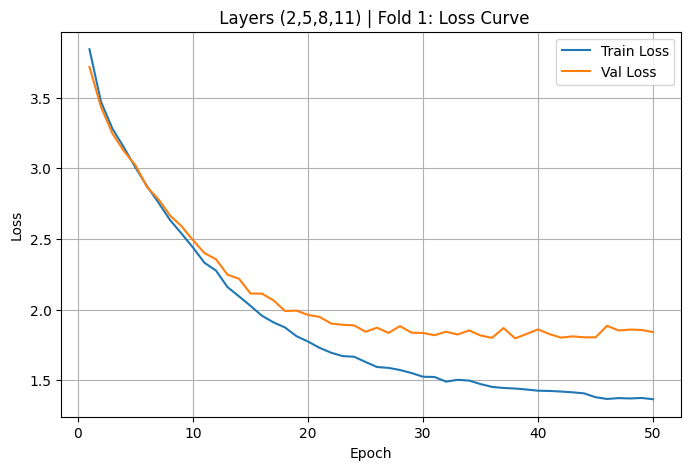

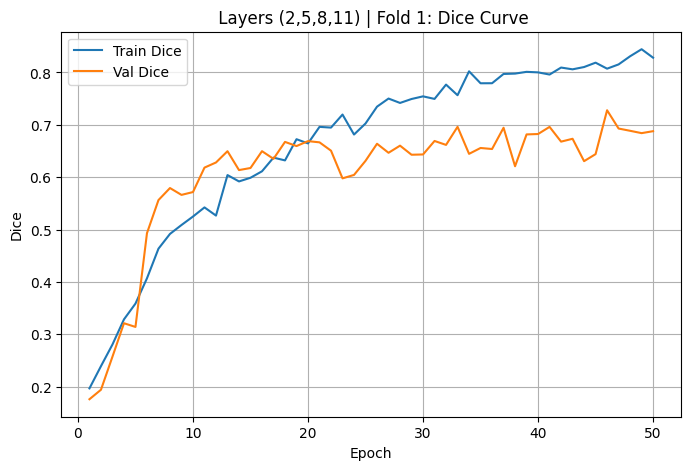

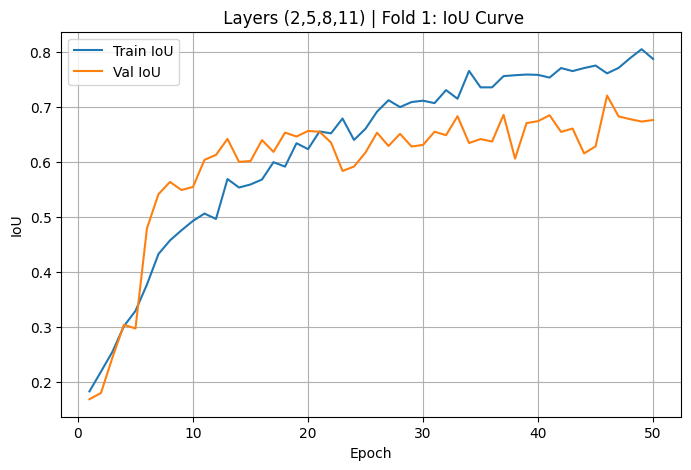

In [ ]:
import os
import json
import torch
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# Select run
# =========================

RUN_DIR = "/content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.5_seed42_kfold5_fold1"

HISTORY_PATH = os.path.join(RUN_DIR, "history.json")
SPLIT_PATH = os.path.join(RUN_DIR, "split_config.json")
CKPT_DIR = os.path.join(RUN_DIR, "ckpts")

# automatically pick best checkpoint
best_ckpts = sorted([
    f for f in os.listdir(CKPT_DIR)
    if f.startswith("best_") and f.endswith(".pth")
])

if len(best_ckpts) == 0:
    raise FileNotFoundError("No best checkpoint found.")

CKPT_PATH = os.path.join(CKPT_DIR, best_ckpts[-1])

print("Run dir:", RUN_DIR)
print("Checkpoint:", CKPT_PATH)
print("History:", HISTORY_PATH)
print("Split:", SPLIT_PATH)

# =========================
# Load history
# =========================

with open(HISTORY_PATH, "r") as f:
    history = json.load(f)

print("Available keys:", list(history.keys()))
print("Epochs logged:", len(history["epoch"]))

plt.figure(figsize=(8, 5))
plt.plot(history["epoch"], history["train_loss"], label="Train Loss")
plt.plot(history["epoch"], history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(" Layers (2,5,8,11) | Fold 1: Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["epoch"], history["train_dice"], label="Train Dice")
plt.plot(history["epoch"], history["val_dice"], label="Val Dice")
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.title(" Layers (2,5,8,11) | Fold 1: Dice Curve")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["epoch"], history["train_iou"], label="Train IoU")
plt.plot(history["epoch"], history["val_iou"], label="Val IoU")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.title(" Layers (2,5,8,11) | Fold 1: IoU Curve")
plt.legend()
plt.grid(True)
plt.show()

Run dir: /content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.5_seed42_kfold5_fold2
Checkpoint: /content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.5_seed42_kfold5_fold2/ckpts/best_ep040_dice0.6888_iou0.6793.pth
History: /content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.5_seed42_kfold5_fold2/history.json
Split: /content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.5_seed42_kfold5_fold2/split_config.json
Available keys: ['epoch', 'train_loss', 'train_dice', 'train_iou', 'val_loss', 'val_dice', 'val_iou']
Epochs logged: 50


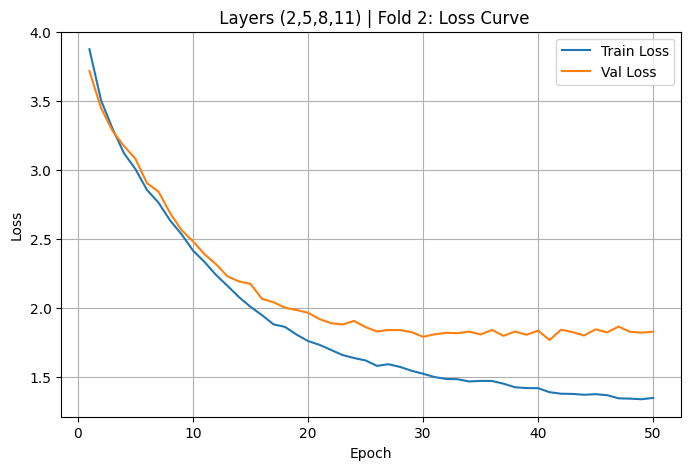

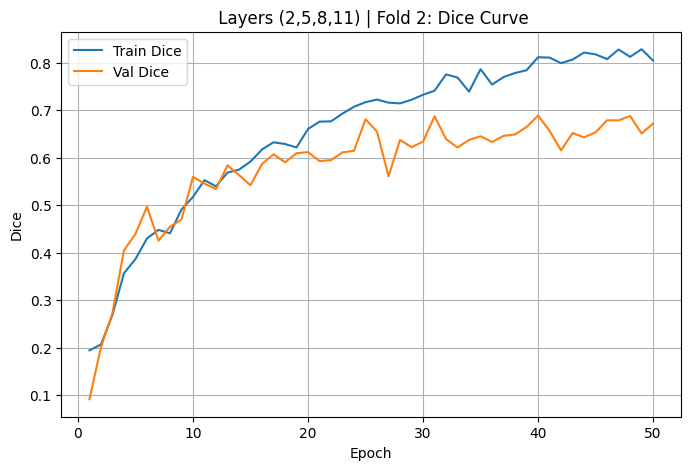

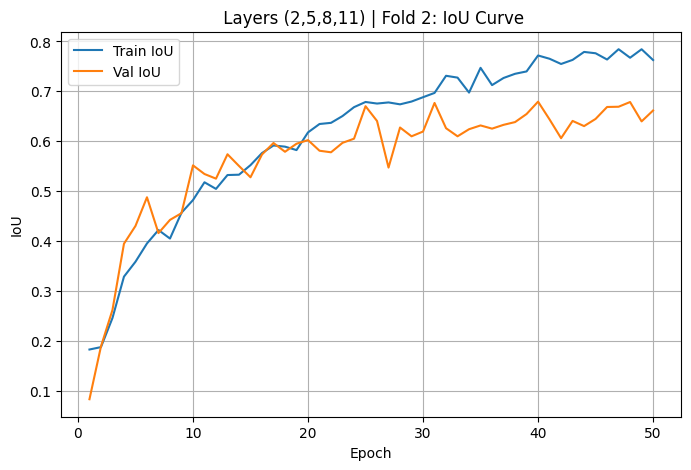

In [ ]:
import os
import json
import torch
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# Select run
# =========================

RUN_DIR = "/content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.5_seed42_kfold5_fold2"

HISTORY_PATH = os.path.join(RUN_DIR, "history.json")
SPLIT_PATH = os.path.join(RUN_DIR, "split_config.json")
CKPT_DIR = os.path.join(RUN_DIR, "ckpts")

# automatically pick best checkpoint
best_ckpts = sorted([
    f for f in os.listdir(CKPT_DIR)
    if f.startswith("best_") and f.endswith(".pth")
])

if len(best_ckpts) == 0:
    raise FileNotFoundError("No best checkpoint found.")

CKPT_PATH = os.path.join(CKPT_DIR, best_ckpts[-1])

print("Run dir:", RUN_DIR)
print("Checkpoint:", CKPT_PATH)
print("History:", HISTORY_PATH)
print("Split:", SPLIT_PATH)

# =========================
# Load history
# =========================

with open(HISTORY_PATH, "r") as f:
    history = json.load(f)

print("Available keys:", list(history.keys()))
print("Epochs logged:", len(history["epoch"]))

plt.figure(figsize=(8, 5))
plt.plot(history["epoch"], history["train_loss"], label="Train Loss")
plt.plot(history["epoch"], history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(" Layers (2,5,8,11) | Fold 2: Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["epoch"], history["train_dice"], label="Train Dice")
plt.plot(history["epoch"], history["val_dice"], label="Val Dice")
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.title(" Layers (2,5,8,11) | Fold 2: Dice Curve")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["epoch"], history["train_iou"], label="Train IoU")
plt.plot(history["epoch"], history["val_iou"], label="Val IoU")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.title(" Layers (2,5,8,11) | Fold 2: IoU Curve")
plt.legend()
plt.grid(True)
plt.show()

Run dir: /content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.5_seed42_kfold5_fold3
Checkpoint: /content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.5_seed42_kfold5_fold3/ckpts/best_ep033_dice0.6998_iou0.6836.pth
History: /content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.5_seed42_kfold5_fold3/history.json
Split: /content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.5_seed42_kfold5_fold3/split_config.json
Available keys: ['epoch', 'train_loss', 'train_dice', 'train_iou', 'val_loss', 'val_dice', 'val_iou']
Epochs logged: 50


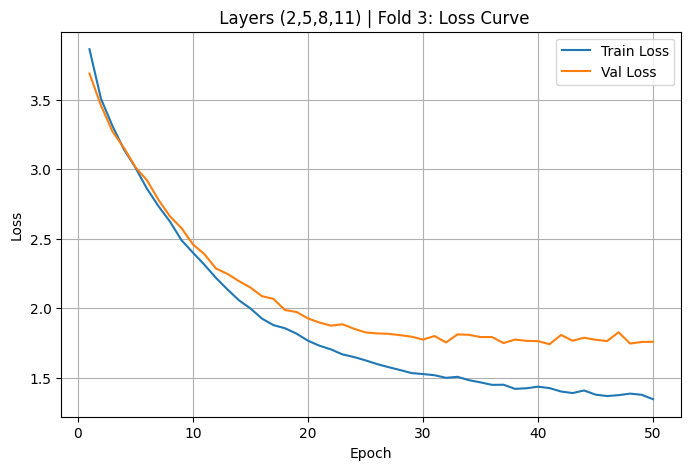

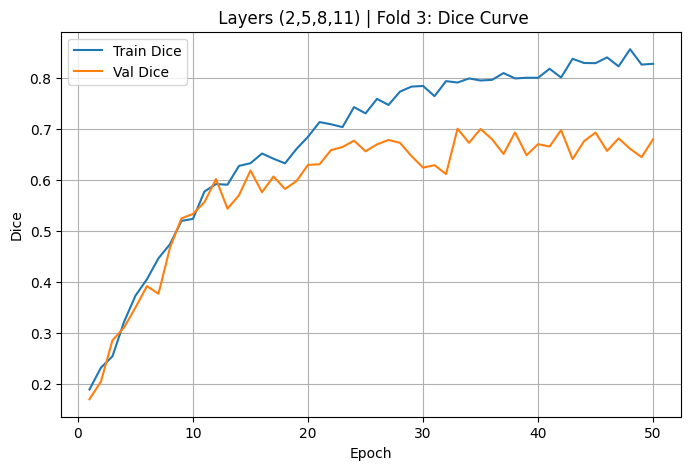

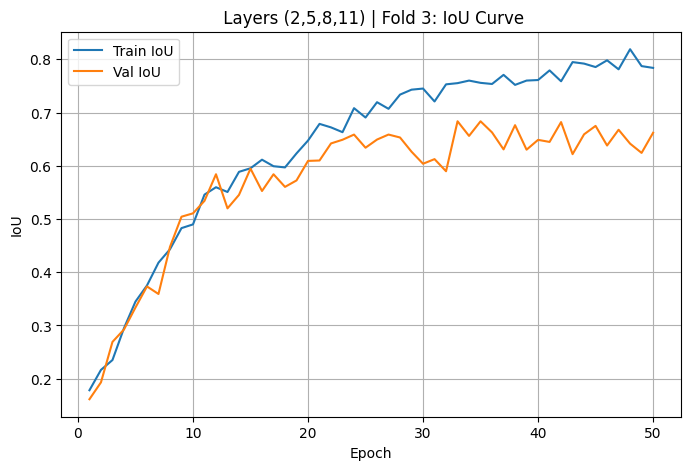

In [ ]:
import os
import json
import torch
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# Select run
# =========================

RUN_DIR = "/content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.5_seed42_kfold5_fold3"

HISTORY_PATH = os.path.join(RUN_DIR, "history.json")
SPLIT_PATH = os.path.join(RUN_DIR, "split_config.json")
CKPT_DIR = os.path.join(RUN_DIR, "ckpts")

# automatically pick best checkpoint
best_ckpts = sorted([
    f for f in os.listdir(CKPT_DIR)
    if f.startswith("best_") and f.endswith(".pth")
])

if len(best_ckpts) == 0:
    raise FileNotFoundError("No best checkpoint found.")

CKPT_PATH = os.path.join(CKPT_DIR, best_ckpts[-1])

print("Run dir:", RUN_DIR)
print("Checkpoint:", CKPT_PATH)
print("History:", HISTORY_PATH)
print("Split:", SPLIT_PATH)

# =========================
# Load history
# =========================

with open(HISTORY_PATH, "r") as f:
    history = json.load(f)

print("Available keys:", list(history.keys()))
print("Epochs logged:", len(history["epoch"]))

plt.figure(figsize=(8, 5))
plt.plot(history["epoch"], history["train_loss"], label="Train Loss")
plt.plot(history["epoch"], history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(" Layers (2,5,8,11) | Fold 3: Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["epoch"], history["train_dice"], label="Train Dice")
plt.plot(history["epoch"], history["val_dice"], label="Val Dice")
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.title(" Layers (2,5,8,11) | Fold 3: Dice Curve")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["epoch"], history["train_iou"], label="Train IoU")
plt.plot(history["epoch"], history["val_iou"], label="Val IoU")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.title(" Layers (2,5,8,11) | Fold 3: IoU Curve")
plt.legend()
plt.grid(True)
plt.show()

Run dir: /content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.5_seed42_kfold5_fold4
Checkpoint: /content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.5_seed42_kfold5_fold4/ckpts/best_ep047_dice0.7174_iou0.7098.pth
History: /content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.5_seed42_kfold5_fold4/history.json
Split: /content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.5_seed42_kfold5_fold4/split_config.json
Available keys: ['epoch', 'train_loss', 'train_dice', 'train_iou', 'val_loss', 'val_dice', 'val_iou']
Epochs logged: 50


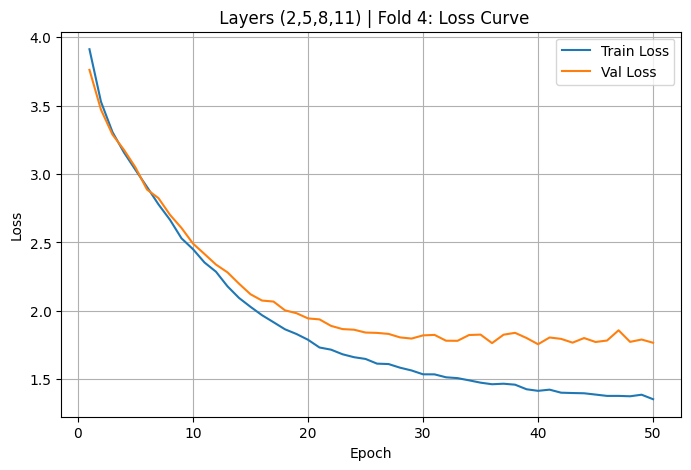

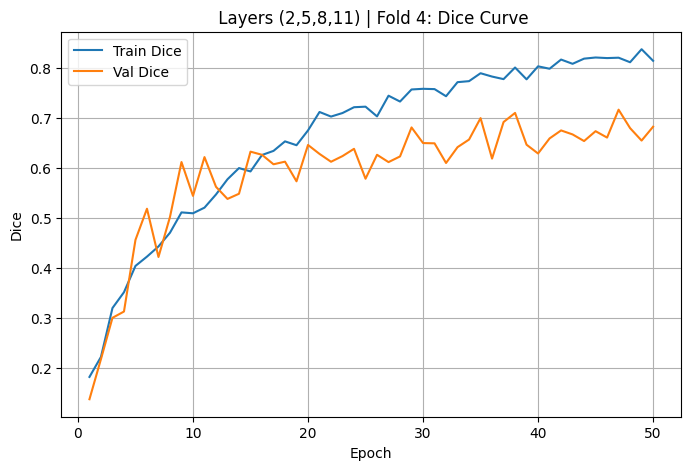

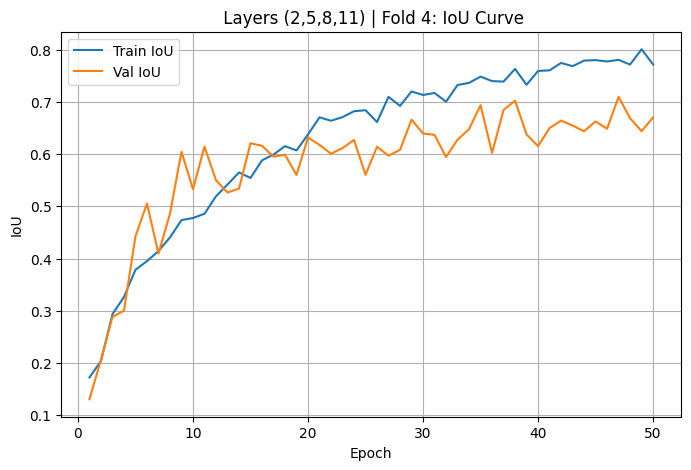

In [ ]:
import os
import json
import torch
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# Select run
# =========================

RUN_DIR = "/content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.5_seed42_kfold5_fold4"

HISTORY_PATH = os.path.join(RUN_DIR, "history.json")
SPLIT_PATH = os.path.join(RUN_DIR, "split_config.json")
CKPT_DIR = os.path.join(RUN_DIR, "ckpts")

# automatically pick best checkpoint
best_ckpts = sorted([
    f for f in os.listdir(CKPT_DIR)
    if f.startswith("best_") and f.endswith(".pth")
])

if len(best_ckpts) == 0:
    raise FileNotFoundError("No best checkpoint found.")

CKPT_PATH = os.path.join(CKPT_DIR, best_ckpts[-1])

print("Run dir:", RUN_DIR)
print("Checkpoint:", CKPT_PATH)
print("History:", HISTORY_PATH)
print("Split:", SPLIT_PATH)

# =========================
# Load history
# =========================

with open(HISTORY_PATH, "r") as f:
    history = json.load(f)

print("Available keys:", list(history.keys()))
print("Epochs logged:", len(history["epoch"]))

plt.figure(figsize=(8, 5))
plt.plot(history["epoch"], history["train_loss"], label="Train Loss")
plt.plot(history["epoch"], history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(" Layers (2,5,8,11) | Fold 4: Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["epoch"], history["train_dice"], label="Train Dice")
plt.plot(history["epoch"], history["val_dice"], label="Val Dice")
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.title(" Layers (2,5,8,11) | Fold 4: Dice Curve")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["epoch"], history["train_iou"], label="Train IoU")
plt.plot(history["epoch"], history["val_iou"], label="Val IoU")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.title(" Layers (2,5,8,11) | Fold 4: IoU Curve")
plt.legend()
plt.grid(True)
plt.show()

Run dir: /content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.5_seed42_kfold5_fold5
Checkpoint: /content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.5_seed42_kfold5_fold5/ckpts/best_ep045_dice0.7353_iou0.7256.pth
History: /content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.5_seed42_kfold5_fold5/history.json
Split: /content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.5_seed42_kfold5_fold5/split_config.json
Available keys: ['epoch', 'train_loss', 'train_dice', 'train_iou', 'val_loss', 'val_dice', 'val_iou']
Epochs logged: 50


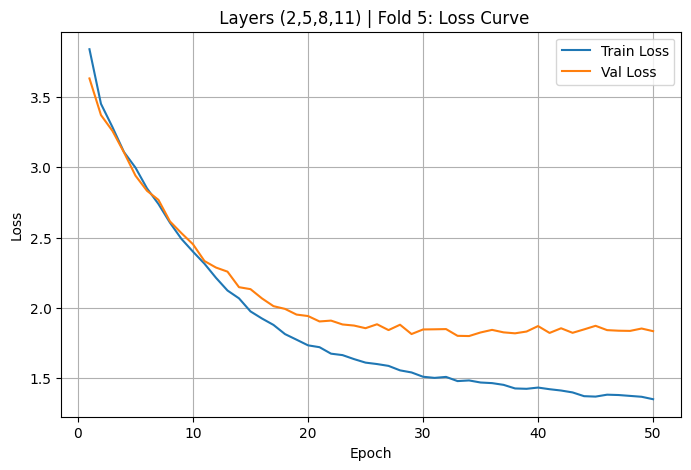

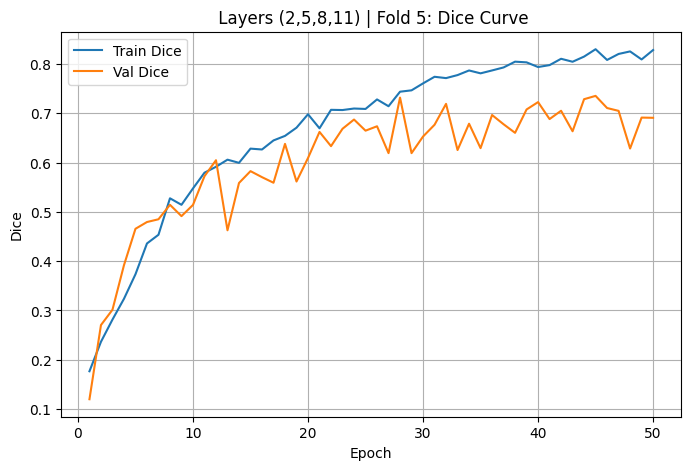

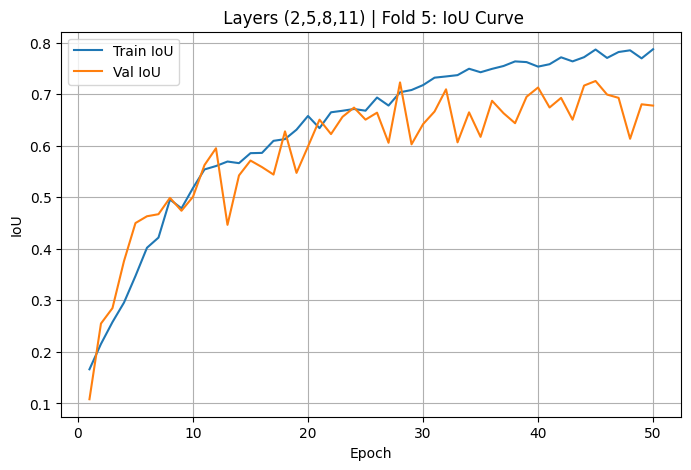

In [ ]:
import os
import json
import torch
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# Select run
# =========================

RUN_DIR = "/content/SegDINO/runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.5_seed42_kfold5_fold5"

HISTORY_PATH = os.path.join(RUN_DIR, "history.json")
SPLIT_PATH = os.path.join(RUN_DIR, "split_config.json")
CKPT_DIR = os.path.join(RUN_DIR, "ckpts")

# automatically pick best checkpoint
best_ckpts = sorted([
    f for f in os.listdir(CKPT_DIR)
    if f.startswith("best_") and f.endswith(".pth")
])

if len(best_ckpts) == 0:
    raise FileNotFoundError("No best checkpoint found.")

CKPT_PATH = os.path.join(CKPT_DIR, best_ckpts[-1])

print("Run dir:", RUN_DIR)
print("Checkpoint:", CKPT_PATH)
print("History:", HISTORY_PATH)
print("Split:", SPLIT_PATH)

# =========================
# Load history
# =========================

with open(HISTORY_PATH, "r") as f:
    history = json.load(f)

print("Available keys:", list(history.keys()))
print("Epochs logged:", len(history["epoch"]))

plt.figure(figsize=(8, 5))
plt.plot(history["epoch"], history["train_loss"], label="Train Loss")
plt.plot(history["epoch"], history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(" Layers (2,5,8,11) | Fold 5: Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["epoch"], history["train_dice"], label="Train Dice")
plt.plot(history["epoch"], history["val_dice"], label="Val Dice")
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.title(" Layers (2,5,8,11) | Fold 5: Dice Curve")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["epoch"], history["train_iou"], label="Train IoU")
plt.plot(history["epoch"], history["val_iou"], label="Val IoU")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.title(" Layers (2,5,8,11) | Fold 5: IoU Curve")
plt.legend()
plt.grid(True)
plt.show()

### 2.0 dice weight

In [ ]:
%cd /content/SegDINO

!python train_segdino_multilayer_sampler.py \
  --repo_dir "/content/dinov3" \
  --dino_ckpt "/content/web_pth/dinov3_vits16_pretrain_lvd1689m-08c60483.pth" \
  --dino_size s \
  --epochs 50 \
  --batch_size 4 \
  --input_h 256 \
  --input_w 256 \
  --num_classes 11 \
  --lr 1e-4 \
  --data_root "/content/drive/MyDrive/HibaAzeem/thesis_folder/__Aku_dataset_segdino_v2" \
  --layer_indices 2 5 8 11 \
  --dice_weight 2.0 \
  --use_lora \
  --use_tagl \
  --tagl_weight 0.05 \
  --tau 0.5 \
  --tagl_start_epoch 15 \
  --kfold \
  --num_folds 5 \
  --fold_idx {fold}

/content/SegDINO
Running fold 1/5
RUN CONFIG
Save root     : ./runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew2.0_seed42_kfold5_fold1
Seed          : 42
K-fold        : True
Num folds     : 5
Fold index    : 1
Layer indices : [2, 5, 8, 11]
Dice weight   : 2.0
Total cases : 130
Train cases : 104
Val cases   : 26
[AspectRegionDataset] Loaded 158 image-mask pairs | augment=True
[AspectRegionDataset] Loaded 44 image-mask pairs | augment=False
Class weights: [0.05       0.32673305 0.15877822 0.3557443  0.3186233  0.14312464
 0.27148187 6.619067   1.5593386  0.7138064  0.53267705]
Class presence over first 20 batches:
Class 1: 27
Class 2: 39
Class 3: 22
Class 4: 10
Class 5: 11
Class 6: 8
Class 7: 14
Class 8: 26
Class 9: 34
Class 10: 52

Epoch 1/50
[Train e1]: 100% 40/40 [00:02<00:00, 15.82it/s, ce=2.1275, dice=0.1589, dice_loss=0.9964, iou=0.1546, loss=4.1203]
[Train Epoch 1] loss=4.3334 dice=0.1827 iou=0.1692
[Eval]: 100% 44/44 [00:01<00:00, 29.61it/s, ce=2.1649, dice=0.1000

### saving the runs

In [ ]:
!rsync -avh \
/content/SegDINO/runs/ \
/content/drive/MyDrive/HibaAzeem/thesis_folder/runs/

Streaming output truncated to the last 5000 lines.
aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.0_seed42_kfold5_fold4/val_vis/val_00033_img.png
aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.0_seed42_kfold5_fold4/val_vis/val_00033_pred.png
aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.0_seed42_kfold5_fold4/val_vis/val_00034_gt.png
aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.0_seed42_kfold5_fold4/val_vis/val_00034_img.png
aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.0_seed42_kfold5_fold4/val_vis/val_00034_pred.png
aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.0_seed42_kfold5_fold4/val_vis/val_00035_gt.png
aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.0_seed42_kfold5_fold4/val_vis/val_00035_img.png
aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.0_seed42_kfold5_fold4/val_vis/val_00035_pred.png
aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew1.0_seed42_kfold5_fold4/va

### 2.5 dice wight

In [ ]:
%cd /content/SegDINO

!python train_segdino_multilayer_sampler.py \
  --repo_dir "/content/dinov3" \
  --dino_ckpt "/content/web_pth/dinov3_vits16_pretrain_lvd1689m-08c60483.pth" \
  --dino_size s \
  --epochs 50 \
  --batch_size 4 \
  --input_h 256 \
  --input_w 256 \
  --num_classes 11 \
  --lr 1e-4 \
  --data_root "/content/drive/MyDrive/HibaAzeem/thesis_folder/__Aku_dataset_segdino_v2" \
  --layer_indices 2 5 8 11 \
  --dice_weight 2.5 \
  --use_lora \
  --use_tagl \
  --tagl_weight 0.05 \
  --tau 0.5 \
  --tagl_start_epoch 15 \
  --kfold \
  --num_folds 5 \
  --fold_idx {fold}

/content/SegDINO
Running fold 1/5
RUN CONFIG
Save root     : ./runs/aku_aspects_multilayer_sampler_s_256_layers_2_5_8_11_dicew2.5_seed42_kfold5_fold1
Seed          : 42
K-fold        : True
Num folds     : 5
Fold index    : 1
Layer indices : [2, 5, 8, 11]
Dice weight   : 2.5
Total cases : 130
Train cases : 104
Val cases   : 26
[AspectRegionDataset] Loaded 158 image-mask pairs | augment=True
[AspectRegionDataset] Loaded 44 image-mask pairs | augment=False
Traceback (most recent call last):
  File "/content/SegDINO/train_segdino_multilayer_sampler.py", line 965, in <module>
    main()
  File "/content/SegDINO/train_segdino_multilayer_sampler.py", line 809, in main
    class_weights = compute_class_weights(
                    ^^^^^^^^^^^^^^^^^^^^^^
  File "/content/SegDINO/train_segdino_multilayer_sampler.py", line 159, in compute_class_weights
    _, mask, _ = dataset[i]
                 ~~~~~~~^^^
  File "/content/SegDINO/dataset.py", line 138, in __getitem__
    mask = Image.open(mask